In [1]:
# Все необходимые библиотеки

import bisect
import joblib
import json
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
import scipy.stats as stats
import time
import warnings

from catboost import CatBoostClassifier
from collections import Counter
from collections import defaultdict
from datetime import datetime
from datetime import timedelta
from scipy.stats import chi2_contingency, pointbiserialr, f_oneway
from scipy.stats import spearmanr
from scipy.stats import pointbiserialr
from scipy.stats import spearmanr
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, recall_score, precision_score 
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from tqdm import tqdm
from xgboost import XGBClassifier

C:\Users\arnt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Загрузка данных

In [2]:
users = pd.read_csv('user_3.csv')
print(users.info())

<class 'pandas.DataFrame'>
RangeIndex: 8802 entries, 0 to 8801
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   location_id         8802 non-null   int64
 1   is_strict_location  8802 non-null   bool 
 2   id                  8802 non-null   str  
 3   has_mk              8802 non-null   bool 
dtypes: bool(2), int64(1), str(1)
memory usage: 154.9 KB
None


In [3]:
events = pd.read_csv('event.csv')
print(events.info())

<class 'pandas.DataFrame'>
RangeIndex: 840850 entries, 0 to 840849
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   id           840850 non-null  str  
 1   shift_id     840850 non-null  int64
 2   user_id      840850 non-null  str  
 3   interaction  840850 non-null  str  
 4   ts           840850 non-null  str  
dtypes: int64(1), str(4)
memory usage: 32.1 MB
None


In [4]:
shifts = pd.read_csv('shift_2.csv')
print(shifts.info())

<class 'pandas.DataFrame'>
RangeIndex: 65624 entries, 0 to 65623
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               65624 non-null  int64  
 1   start_at         65624 non-null  str    
 2   location_id      65624 non-null  int64  
 3   task_type        65624 non-null  str    
 4   employer_id      65624 non-null  str    
 5   workplace_id     65624 non-null  str    
 6   need_mk          65624 non-null  bool   
 7   id_differential  65624 non-null  bool   
 8   hours            65624 non-null  int64  
 9   reward           65624 non-null  float64
 10  capacity         65624 non-null  int64  
dtypes: bool(2), float64(1), int64(4), str(4)
memory usage: 4.6 MB
None


In [5]:
shifts.head()

,id,start_at,location_id,task_type,employer_id,workplace_id,need_mk,id_differential,hours,reward,capacity
0,57080,2026-01-01 07:00:00+00:00,234,Выкладка товара,02d2b372ccc7404c03bf705d67360723,67cffef2e08cf63c214fc0b9f6273cd5,True,False,12,2800.0,1
1,59080,2026-01-01 07:00:00+00:00,41,Уборка помещений,6cda58e6bf56ba0ddde0c84212300104,48c8cb23493ca2e467a207d840cdb59e,True,False,12,2500.0,5
2,32676,2026-01-01 07:00:00+00:00,234,Выкладка товара,02d2b372ccc7404c03bf705d67360723,6d8a2900d0cd692005b919959d9f3e2b,True,False,12,3700.0,1
3,37968,2026-01-01 08:00:00+00:00,166,Выкладка товара,fb3d1aaa7ddb54fd11604d5529a7774b,22e8cc4635d2e9ca20095842983559aa,True,False,15,5750.0,1
4,9587,2026-01-01 08:00:00+00:00,234,Выкладка товара,02d2b372ccc7404c03bf705d67360723,7e17fba7df94be7f98948340eee1935c,True,False,12,1300.0,1


Объединяем таблицы в единый датасет

In [6]:
merged = events.copy()

# Присоединяем данные пользователя
users_renamed = users.rename(columns={'id': 'user_id'})         # Переименовываем колонку id в users, чтобы избежать конфликта с events.id
merged = merged.merge(
    users_renamed,
    on='user_id',
    how='left'
)

# Присоединяем данные смены
shifts_renamed = shifts.rename(columns={'id': 'shift_id'})      # Переименовываем колонку id в shifts
merged = merged.merge(
    shifts_renamed,
    on='shift_id',
    how='left',
    suffixes=('', '_shift')                                     # у events уже есть shift_id, поэтому добавляем суффикс только к конфликтующим
)
merged = merged.rename(columns={'location_id': 'location_id_user'})
merged.head()

,id,shift_id,user_id,interaction,ts,location_id_user,is_strict_location,has_mk,start_at,location_id_shift,task_type,employer_id,workplace_id,need_mk,id_differential,hours,reward,capacity
0,3e0c68e79a79f3cfbb5dc33a94539538,64679,d0b587858e4eba68a2d5b71dd7cc91b3,VIEW,2026-02-23,234,False,True,2026-02-24 09:00:00+00:00,234,Сборка заказов,02d2b372ccc7404c03bf705d67360723,dbed640f571b1baf60443732053d29dc,True,False,12,1450.0,1
1,4219556E8C93233128D8218577DD9F06,64679,d0b587858e4eba68a2d5b71dd7cc91b3,APPLY,2026-02-23,234,False,True,2026-02-24 09:00:00+00:00,234,Сборка заказов,02d2b372ccc7404c03bf705d67360723,dbed640f571b1baf60443732053d29dc,True,False,12,1450.0,1
2,0BF1B8CD6627920077C54DEA87713AA5,64679,d0b587858e4eba68a2d5b71dd7cc91b3,FINISHED,2026-02-23,234,False,True,2026-02-24 09:00:00+00:00,234,Сборка заказов,02d2b372ccc7404c03bf705d67360723,dbed640f571b1baf60443732053d29dc,True,False,12,1450.0,1
3,65664e85b7d79b5f370ea5db40b40cef,65231,d0b587858e4eba68a2d5b71dd7cc91b3,VIEW,2026-02-24,234,False,True,2026-02-25 09:00:00+00:00,234,Сборка заказов,02d2b372ccc7404c03bf705d67360723,dbed640f571b1baf60443732053d29dc,True,False,12,4600.0,1
4,959BFA3BE2079E32FD063B60F7251419,65231,d0b587858e4eba68a2d5b71dd7cc91b3,APPLY,2026-02-24,234,False,True,2026-02-25 09:00:00+00:00,234,Сборка заказов,02d2b372ccc7404c03bf705d67360723,dbed640f571b1baf60443732053d29dc,True,False,12,4600.0,1


In [7]:
merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 840850 entries, 0 to 840849
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  840850 non-null  str    
 1   shift_id            840850 non-null  int64  
 2   user_id             840850 non-null  str    
 3   interaction         840850 non-null  str    
 4   ts                  840850 non-null  str    
 5   location_id_user    840850 non-null  int64  
 6   is_strict_location  840850 non-null  bool   
 7   has_mk              840850 non-null  bool   
 8   start_at            840850 non-null  str    
 9   location_id_shift   840850 non-null  int64  
 10  task_type           840850 non-null  str    
 11  employer_id         840850 non-null  str    
 12  workplace_id        840850 non-null  str    
 13  need_mk             840850 non-null  bool   
 14  id_differential     840850 non-null  bool   
 15  hours               840850 non-null  int64  


In [8]:
# Конвертируем ts и start_at
merged['ts'] = pd.to_datetime(merged['ts'])
merged['start_at'] = pd.to_datetime(merged['start_at'])

# Убедимся, что время обнулено
print(f"Уникальные времена в ts: {merged['ts'].dt.time.unique()}")
# Должно быть: [00:00:00]

# Проверяем диапазоны
print(f"Минимальная дата события: {merged['ts'].min()}")
print(f"Максимальная дата события: {merged['ts'].max()}")
print(f"Минимальная дата смены: {merged['start_at'].min()}")
print(f"Максимальная дата смены: {merged['start_at'].max()}")


Уникальные времена в ts: [datetime.time(0, 0)]
Минимальная дата события: 2026-01-01 00:00:00
Максимальная дата события: 2026-03-22 00:00:00
Минимальная дата смены: 2026-01-01 07:00:00+00:00
Максимальная дата смены: 2026-03-22 23:00:00+00:00


Посмотрим, есть ли повторяющиеся пары (user_id, shift_id)

In [9]:
# Проверяем количество уникальных пар
unique_pairs = merged.groupby(['user_id', 'shift_id']).size().reset_index(name='count')
print(f"Всего записей в merged: {len(merged)}")
print(f"Уникальных пар (user_id, shift_id): {len(unique_pairs)}")

# Смотрим распределение количества записей на пару
print(f"\nСтатистика по количеству записей на пару:")
print(unique_pairs['count'].describe())

# Сколько пар имеют более одной записи?
duplicated_pairs = unique_pairs[unique_pairs['count'] > 1]
print(f"\nПар с несколькими записями: {len(duplicated_pairs)}")
print(f"Доля от всех пар: {len(duplicated_pairs) / len(unique_pairs) * 100:.2f}%")

Всего записей в merged: 840850
Уникальных пар (user_id, shift_id): 767065

Статистика по количеству записей на пару:
count    767065.000000
mean          1.096191
std           0.427923
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           3.000000
Name: count, dtype: float64

Пар с несколькими записями: 36897
Доля от всех пар: 4.81%


In [10]:
# Посмотрим на структуру дублирующихся пар
duplicated_examples = merged[merged.groupby(['user_id', 'shift_id'])['user_id'].transform('size') > 1]

print("Примеры дублирующихся пар (первые 10):")
print(duplicated_examples[['user_id', 'shift_id', 'interaction', 'ts']].head(10))

# Какие последовательности событий встречаются чаще всего
# Для каждой пары собираем последовательность interaction в порядке ts
sequences = []
for (user, shift), group in duplicated_examples.groupby(['user_id', 'shift_id']):
    # Сортируем по времени
    seq = tuple(group.sort_values('ts')['interaction'].values)
    sequences.append(seq)

# Топ-5 последовательностей
sequence_counts = Counter(sequences)
print("\nТоп-5 последовательностей событий в дублирующихся парах:")
for seq, count in sequence_counts.most_common(5):
    print(f"    {seq}: {count} раз")

Примеры дублирующихся пар (первые 10):
                             user_id  shift_id interaction         ts
0   d0b587858e4eba68a2d5b71dd7cc91b3     64679        VIEW 2026-02-23
1   d0b587858e4eba68a2d5b71dd7cc91b3     64679       APPLY 2026-02-23
2   d0b587858e4eba68a2d5b71dd7cc91b3     64679    FINISHED 2026-02-23
3   d0b587858e4eba68a2d5b71dd7cc91b3     65231        VIEW 2026-02-24
4   d0b587858e4eba68a2d5b71dd7cc91b3     65231       APPLY 2026-02-24
5   d0b587858e4eba68a2d5b71dd7cc91b3     65231    FINISHED 2026-02-24
6   d0b587858e4eba68a2d5b71dd7cc91b3     67373        VIEW 2026-02-26
7   d0b587858e4eba68a2d5b71dd7cc91b3     67373       APPLY 2026-02-26
8   d0b587858e4eba68a2d5b71dd7cc91b3     67373    FINISHED 2026-02-26
10  d0b587858e4eba68a2d5b71dd7cc91b3     69052        VIEW 2026-02-27

Топ-5 последовательностей событий в дублирующихся парах:
    ('VIEW', 'APPLY', 'FINISHED'): 15728 раз
    ('VIEW', 'APPLY', 'USER_CANCEL'): 11503 раз
    ('VIEW', 'APPLY', 'SYSTEM_CANCEL'): 

дублирующиеся пары - это просто разные события

In [11]:
# Проверяем FINISHED без APPLY
finished_without_apply = merged[(merged['interaction'] == 'FINISHED') & (~merged.duplicated(subset=['user_id', 'shift_id', 'interaction'], keep=False))]

# Лучше проверить через группировку
pairs_with_finished = merged[merged['interaction'] == 'FINISHED'][['user_id', 'shift_id']].drop_duplicates()
pairs_with_apply = merged[merged['interaction'] == 'APPLY'][['user_id', 'shift_id']].drop_duplicates()

# Находим FINISHED без APPLY
finished_no_apply = pairs_with_finished.merge(
    pairs_with_apply,
    on=['user_id', 'shift_id'],
    how='left',
    indicator=True
)
finished_no_apply = finished_no_apply[finished_no_apply['_merge'] == 'left_only']

print(f"Пар с FINISHED: {len(pairs_with_finished)}")
print(f"Пар с APPLY: {len(pairs_with_apply)}")
print(f"Пар с FINISHED но без APPLY: {len(finished_no_apply)}")

Пар с FINISHED: 15910
Пар с APPLY: 36897
Пар с FINISHED но без APPLY: 0


Посмотрим, есть ли кейсы, когда пользовател отменил свое участие в смене, после этого был apply

In [12]:
# Получаем все пары, где есть и USER_CANCEL и APPLY
pairs_with_both = merged[merged['interaction'].isin(['USER_CANCEL', 'APPLY'])].groupby(['user_id', 'shift_id']).filter(lambda x: len(x['interaction'].unique()) == 2)

# Проверяем дневные последовательности
cancel_apply_pairs = []

for (user, shift), group in pairs_with_both.groupby(['user_id', 'shift_id']):
    cancel_dates = group[group['interaction'] == 'USER_CANCEL']['ts'].values
    apply_dates = group[group['interaction'] == 'APPLY']['ts'].values

    for cancel_date in cancel_dates:
        for apply_date in apply_dates:
            if apply_date > cancel_date:
                days_diff = (apply_date - cancel_date) / np.timedelta64(1, 'D')     # Перевод в количество дней
                cancel_apply_pairs.append({
                    'user_id': user,
                    'shift_id': shift,
                    'cancel_date': cancel_date,
                    'apply_date': apply_date,
                    'days_after': int(days_diff)
                })

df_cancel_then_apply = pd.DataFrame(cancel_apply_pairs)

print(f"Пар с APPLY после USER_CANCEL (в разные дни): {len(df_cancel_then_apply)}")

if len(df_cancel_then_apply) > 0:
    print(f"\nПримеры:")
    print(df_cancel_then_apply.head(10))

    print(f"\nРаспределение дней между CANCEL и APPLY:")
    print(df_cancel_then_apply['days_after'].value_counts().sort_index())
else:
    print("Нет пар с APPLY после USER_CANCEL в разные дни")

Пар с APPLY после USER_CANCEL (в разные дни): 7

Примеры:
                            user_id  shift_id cancel_date apply_date  \
0  1187e53e77be87f644e8cea78023543f     46711  2026-01-18 2026-01-20   
1  1d8c0d319450a4547a15a67aba23af7b    103350  2026-02-23 2026-02-24   
2  343713b8d35190a3823602ed0811ae53     97592  2026-02-17 2026-02-18   
3  351afd17ba379b3802bf3739477c481a     15876  2026-01-02 2026-01-03   
4  6a6338f6c67737024623bf4f4443984c      2205  2026-01-31 2026-02-12   
5  b9c9641a918b77f13161027300e6da2b     85273  2026-02-24 2026-02-25   
6  c7d4a1baaa416fee577ffd82dae49cb0     71727  2026-03-12 2026-03-13   

   days_after  
0           2  
1           1  
2           1  
3           1  
4          12  
5           1  
6           1  

Распределение дней между CANCEL и APPLY:
days_after
1     5
2     1
12    1
Name: count, dtype: int64


APPLY после USER_CANCEL в разные дни: ТОЛЬКО 7 случаев (из 630,100 пар!)
Это 0.001% от всех пар
Можно считать статистической аномалией, оставляем как есть. не должно повлиять на результат

Посмотрим однодневные пары по порядку следования в df

In [13]:
# список кортежей (user_id, shift_id)
same_day_pairs = []                                                                     

for (user, shift), group in pairs_with_both.groupby(['user_id', 'shift_id']):
    cancel_dates = set(group[group['interaction'] == 'USER_CANCEL']['ts'].values)
    apply_dates = set(group[group['interaction'] == 'APPLY']['ts'].values)

    # Если есть пересечение дат (хотя бы один день, когда были оба события)
    if cancel_dates & apply_dates:
        same_day_pairs.append((user, shift))

print(f"Найдено пар (с APPLY и USER_CANCEL): {len(same_day_pairs)}")

# Для обратной совместимости создаем список shift_id (уникальные смены)
same_day_shifts = list(set([shift for (user, shift) in same_day_pairs]))

# Используем уже готовый same_day_shifts из предыдущего анализа
# У нас уже есть список смен с однодневными событиями
print(f"Всего однодневных смен: {len(same_day_shifts)}")

# Анализируем порядок, используя готовые данные
cancel_then_apply_count = 0
apply_then_cancel_count = 0
cancel_then_apply_with_finished = 0
cancel_then_apply_without_finished = 0

# Проходим только по однодневным сменам
for shift_id in same_day_shifts:
    # Получаем все события для этой смены (без группировки по пользователям)
    group = merged[merged['shift_id'] == shift_id].sort_index()

    # Анализ в разрезе пользователей
    for user_id in group['user_id'].unique():
        user_group = group[group['user_id'] == user_id]
        interactions = user_group['interaction'].tolist()

        if 'APPLY' in interactions and 'USER_CANCEL' in interactions:
            # Определяем последнее событие
            last_apply = max([i for i, e in enumerate(interactions) if e == 'APPLY'])
            last_cancel = max([i for i, e in enumerate(interactions) if e == 'USER_CANCEL'])
            has_finished = 'FINISHED' in interactions

            if last_apply > last_cancel:
                cancel_then_apply_count += 1
                if has_finished:
                    cancel_then_apply_with_finished += 1
                else:
                    cancel_then_apply_without_finished += 1
            else:
                apply_then_cancel_count += 1

print(f"\nРезультаты 'быстрого' анализа:")
print(f"    CANCEL_then_APPLY (всего): {cancel_then_apply_count}")
print(f"        из них с FINISHED: {cancel_then_apply_with_finished}")
print(f"        из них без FINISHED: {cancel_then_apply_without_finished}")
print(f"    APPLY_then_CANCEL: {apply_then_cancel_count}")



Найдено пар (с APPLY и USER_CANCEL): 6554
Всего однодневных смен: 5868

Результаты 'быстрого' анализа:
    CANCEL_then_APPLY (всего): 1
        из них с FINISHED: 0
        из них без FINISHED: 1
    APPLY_then_CANCEL: 7560


### Создание целевой переменной

Так, как описано в требованиях: target = 1, если у пары User+shift было событие "Apply" или "Finished", и не было отмен.
Смены с System_cancel удаляем (они не будут участвовать в оценке результатов)

In [14]:
# Группируем по (user_id, shift_id) и агрегируем
target_agg = merged.groupby(['user_id', 'shift_id']).agg(
    has_apply=('interaction', lambda x: ('APPLY' in x.values)),
    has_finished=('interaction', lambda x: ('FINISHED' in x.values)),
    has_cancel=('interaction', lambda x: ('USER_CANCEL' in x.values)),
    has_system_cancel=('interaction', lambda x: ('SYSTEM_CANCEL' in x.values))
).reset_index()

print(f"Агрегировано: {len(target_agg):,} пар")

# Применяем логику target
def set_target(row):
    if row['has_system_cancel']:
        return None                                             # исключаем
    if row['has_cancel']:
        return 0                                                # если есть USER_CANCEL
    if row['has_apply'] or row['has_finished']:
        return 1                                                # если есть APPLY или FINISHED
    return 0                                                    # остальные

target_agg['target'] = target_agg.apply(set_target, axis=1)

# Удаляем None (смены с SYSTEM_CANCEL)
target_correct = target_agg.dropna(subset=['target']).copy()    # .copy() для явного создания копии
target_correct['target'] = target_correct['target'].astype(int)

print(f"\nРезультаты:")
print(f"    Всего пар: {len(target_correct):,}")
print(f"    target=1: {target_correct['target'].sum():,} ({target_correct['target'].mean():.4%})")
print(f"    target=0: {len(target_correct) - target_correct['target'].sum():,}")

Агрегировано: 767,065 пар

Результаты:
    Всего пар: 757,976
    target=1: 15,919 (2.1002%)
    target=0: 742,057


Проверим корректность таргета

In [15]:
# 1. Пары с USER_CANCEL (отмена пользователем)
pairs_user_cancel = merged[merged['interaction'] == 'USER_CANCEL'][['user_id', 'shift_id']].drop_duplicates()
print(f"\nПары с USER_CANCEL: {len(pairs_user_cancel):,}")

# 2. Пары с SYSTEM_CANCEL (отмена системой)
pairs_system_cancel = merged[merged['interaction'] == 'SYSTEM_CANCEL'][['user_id', 'shift_id']].drop_duplicates()
print(f"Пары с SYSTEM_CANCEL: {len(pairs_system_cancel):,}")

# 3. Объединенные пары (хотя бы одна отмена)
all_cancel_pairs = pd.concat([pairs_user_cancel, pairs_system_cancel]).drop_duplicates()
print(f"Пары с любой отменой (USER или SYSTEM): {len(all_cancel_pairs):,}")

# 4. Пары, где есть и USER, и SYSTEM (пересечение)
both_cancel = pairs_user_cancel.merge(pairs_system_cancel, on=['user_id', 'shift_id'], how='inner')
print(f"Пары с обеими отменами: {len(both_cancel):,}")


# Проверка на пересечение с целевой переменной

# Получаем target=1 пары
target_true = target_correct[target_correct['target'] == 1][['user_id', 'shift_id']]

# Проверяем, есть ли среди target=1 пары с отменами
target_with_user_cancel = target_true.merge(pairs_user_cancel, on=['user_id', 'shift_id'], how='inner')
target_with_system_cancel = target_true.merge(pairs_system_cancel, on=['user_id', 'shift_id'], how='inner')
target_with_any_cancel = target_true.merge(all_cancel_pairs, on=['user_id', 'shift_id'], how='inner')

print(f"target=1, но есть USER_CANCEL: {len(target_with_user_cancel):,} (должно быть 0)")
print(f"target=1, но есть SYSTEM_CANCEL: {len(target_with_system_cancel):,} (должно быть 0)")
print(f"target=1, но есть любая отмена: {len(target_with_any_cancel):,} (должно быть 0)")


# Статистика по сменам (уникальные shift_id)

print("\nСтатистика по уникальным именам:")

shifts_with_user_cancel = merged[merged['interaction'] == 'USER_CANCEL']['shift_id'].nunique()
shifts_with_system_cancel = merged[merged['interaction'] == 'SYSTEM_CANCEL']['shift_id'].nunique()
shifts_with_any_cancel = len(set(merged[merged['interaction'] == 'USER_CANCEL']['shift_id'].unique()) | set(merged[merged['interaction'] == 'SYSTEM_CANCEL']['shift_id'].unique()))

print(f"\nСмены с USER_CANCEL (хотя бы у одного пользователя): {shifts_with_user_cancel:,}")
print(f"Смены с SYSTEM_CANCEL: {shifts_with_system_cancel:,}")
print(f"Смены с любой отменой: {shifts_with_any_cancel:,}")


# Проверка логики целевой переменной

print("\nПроверка логики целевой переменной:")

# Создаем временный датафрейм для проверки
check_df = merged.groupby(['user_id', 'shift_id']).agg(
    has_apply=('interaction', lambda x: ('APPLY' in x.values)),
    has_finished=('interaction', lambda x: ('FINISHED' in x.values)),
    has_user_cancel=('interaction', lambda x: ('USER_CANCEL' in x.values)),
    has_system_cancel=('interaction', lambda x: ('SYSTEM_CANCEL' in x.values))
).reset_index()

# Сколько пар с APPLY и USER_CANCEL одновременно:
apply_and_user_cancel = check_df[(check_df['has_apply'] == True) & (check_df['has_user_cancel'] == True)]
print(f"\nПары с APPLY и USER_CANCEL: {len(apply_and_user_cancel):,}")

# Сколько пар с APPLY, но без USER_CANCEL и без FINISHED:
apply_only_no_finished = check_df[((check_df['has_apply'] == True) | (check_df['has_finished'] == True)) 
                                  & (check_df['has_user_cancel'] == False)
                                  & (check_df['has_system_cancel'] == False)]
print(f"Пары с APPLY, но без USER_CANCEL : {len(apply_only_no_finished):,}")


Пары с USER_CANCEL: 11,889
Пары с SYSTEM_CANCEL: 9,089
Пары с любой отменой (USER или SYSTEM): 20,978
Пары с обеими отменами: 0
target=1, но есть USER_CANCEL: 0 (должно быть 0)
target=1, но есть SYSTEM_CANCEL: 0 (должно быть 0)
target=1, но есть любая отмена: 0 (должно быть 0)

Статистика по уникальным именам:

Смены с USER_CANCEL (хотя бы у одного пользователя): 9,866
Смены с SYSTEM_CANCEL: 8,242
Смены с любой отменой: 16,097

Проверка логики целевой переменной:

Пары с APPLY и USER_CANCEL: 11,889
Пары с APPLY, но без USER_CANCEL : 15,919


In [16]:
# Проверим на конкретном примере

# Смена 49938 (APPLY + USER_CANCEL от одного пользователя)
test1 = target_correct[target_correct['shift_id'] == 49938]
if len(test1) > 0:
    print(f"\nСмена 49938:")
    print(test1[['user_id', 'shift_id', 'has_apply', 'has_finished', 'has_cancel', 'target']].to_string())
    print(f"    target = {test1['target'].iloc[0]} (должен быть 0)")

# Смена 64679 - проверяем конкретного пользователя с FINISHED
correct_user = 'd0b587858e4eba68a2d5b71dd7cc91b3'
test2 = target_correct[(target_correct['shift_id'] == 64679) & (target_correct['user_id'] == correct_user)]
if len(test2) > 0:
    print(f"\nСмена 64679, пользователь с FINISHED:")
    print(test2[['user_id', 'shift_id', 'has_apply', 'has_finished', 'has_cancel', 'target']].to_string())
    print(f"    target = {test2['target'].iloc[0]} (должен быть 1)")
else:
    print(f"\nСмена 64679, пользователь {correct_user[:30]}... не найден в target_correct")

# Проверяем пользователя с SYSTEM_CANCEL (должен быть исключен)
system_user = '7cdf53fb7eec3353e93cbf41a2f0e3c6'
test3 = target_correct[(target_correct['shift_id'] == 64679) & (target_correct['user_id'] == system_user)]
print(f"\nПользователь с SYSTEM_CANCEL: присутствует в target? {len(test3) > 0} (должен быть исключен)")


Смена 49938:
                                 user_id  shift_id  has_apply  has_finished  has_cancel  target
624425  d0b587858e4eba68a2d5b71dd7cc91b3     49938       True         False        True       0
    target = 0 (должен быть 0)

Смена 64679, пользователь с FINISHED:
                                 user_id  shift_id  has_apply  has_finished  has_cancel  target
624431  d0b587858e4eba68a2d5b71dd7cc91b3     64679       True          True       False       1
    target = 1 (должен быть 1)

Пользователь с SYSTEM_CANCEL: присутствует в target? False (должен быть исключен)


In [17]:

print("\nФинальная проверка корректности:")

# 1. Проверяем, что нет пар с USER_CANCEL и target=1
invalid_cancel = target_correct[target_correct['has_cancel'] & (target_correct['target'] == 1)]
print(f"\nПары с USER_CANCEL и target=1: {len(invalid_cancel)} (должно быть 0)")

# 2. Проверяем, что все пары с FINISHED и без CANCEL имеют target=1
finished_no_cancel = target_correct[target_correct['has_finished'] & ~target_correct['has_cancel']]
print(f"Пары с FINISHED без CANCEL: {len(finished_no_cancel)}")
print(f"    Из них target=1: {finished_no_cancel['target'].sum()}")
print(f"    Из них target=0: {len(finished_no_cancel) - finished_no_cancel['target'].sum()} (должно быть 0)")

# 3. Проверяем, что все пары с APPLY без CANCEL и FINISHED имеют target=1
apply_no_cancel_no_finished = target_correct[target_correct['has_apply'] & ~target_correct['has_cancel'] & ~target_correct['has_finished']]
print(f"\nПары с APPLY без CANCEL и без FINISHED: {len(apply_no_cancel_no_finished)}")
print(f"    Из них target=1: {apply_no_cancel_no_finished['target'].sum()}")
print(f"    Из них target=0: {len(apply_no_cancel_no_finished) - apply_no_cancel_no_finished['target'].sum()} (должно быть 0)")

# Сохраняем финальный target
target_correct[['user_id', 'shift_id', 'target']].to_csv('target_final.csv', index=False)

# Добавляем target к merged
merged_with_target = merged.merge(
    target_correct[['user_id', 'shift_id', 'target']],
    on=['user_id', 'shift_id'],
    how='left'
)
print(f"Таблица merged_with_target: {len(merged_with_target):,} записей")


Финальная проверка корректности:

Пары с USER_CANCEL и target=1: 0 (должно быть 0)
Пары с FINISHED без CANCEL: 15910
    Из них target=1: 15910
    Из них target=0: 0 (должно быть 0)

Пары с APPLY без CANCEL и без FINISHED: 9
    Из них target=1: 9
    Из них target=0: 0 (должно быть 0)
Таблица merged_with_target: 840,850 записей


## Формирование признаков

#### Справочник признаков для модели предсказания выхода на смену

##### Общая информация:
- **Целевая переменная:** `target` (1 - пользователь записался на смену, 0 - не записался)
- **Момент предсказания:** за 2 дня до начала смены (`start_at - 2 дня`)
- **Окно для исторических признаков:** `[T-30, T-2]` (28 дней)

---

##### ГРУППА 1: Базовые признаки смены

| Признак | Тип | Описание | Способ расчета |
|---------|-----|----------|----------------|
| `hours` | numeric | Длительность смены в часах | Из данных смены |
| `reward` | numeric | Оплата за смену | Из данных смены |
| `reward_per_hour` | numeric | Почасовая оплата | `reward / hours` |
| `capacity` | numeric | Количество человек на смену | Из данных смены |
| `need_mk` | binary | Требуется ли медкнижка | Из данных смены |
| `is_long_shift` | binary | Длинная смена | `1` если `hours > 8`, иначе `0` |
| `is_short_shift` | binary | Короткая смена | `1` если `hours < 4`, иначе `0` |

---

##### ГРУППА 2: Временные признаки смены

| Признак | Тип | Описание | Способ расчета |
|---------|-----|----------|----------------|
| `shift_day_of_week` | categorical | День недели | `0` (пн) - `6` (вс) из `start_at` |
| `shift_hour` | categorical | Час начала смены | `0-23` из `start_at` |
| `shift_time_of_day` | categorical | Время суток | `morning` (6-11), `day` (12-17), `evening` (18-23), `night` (0-5) |
| `is_weekday` | binary | Будний день | `1` если пн-пт и не праздник, иначе `0` |

---

##### ГРУППА 3: Оконные признаки (контекст рынка)

| Признак | Тип | Описание | Способ расчета |
|---------|-----|----------|----------------|
| `median_pay_window` | numeric | Медианная оплата в окне | Скользящая медиана `reward_per_hour` за `[T-30, T-2]` |
| `is_high_paid_window` | binary | Высокая оплата относительно рынка | `1` если `reward_per_hour > median_pay_window`, иначе `0` |

---

##### ГРУППА 4: Взаимодействие пользователя со сменой

| Признак | Тип | Описание | Способ расчета |
|---------|-----|----------|----------------|
| `mk_match` | binary | Совпадение медкнижки | `1` если `has_mk == need_mk`, иначе `0` |
| `mk_match_2` | categorical | Состояние медкнижки (3 состояния) | `0` - книжка нужна, но нет; `1` - книжка нужна и есть; `2` - книжка не нужна |
| `location_match` | binary | Совпадение локации | `1` если `location_id_user == location_id_shift`, иначе `0` |
| `task_category` | categorical | Категория задания | Маппинг `task_type` в 9 категорий |

---

##### ГРУППА 5: Исторические признаки пользователя (окно `[T-30, T-2]`)

| Признак | Тип | Описание | Способ расчета |
|---------|-----|----------|----------------|
| `user_total_views` | numeric | Количество просмотренных смен | Число уникальных `shift_id` с `interaction='VIEW'` |
| `user_total_successful_actions` | numeric | Количество успешных записей | Число уникальных `shift_id` с `is_successful=1` |
| `user_success_rate` | numeric | Доля успешных записей | `user_total_successful_actions / user_total_views` (0 если нет просмотров) |
| `user_active_days` | numeric | Количество активных дней | Число уникальных дней с любыми событиями |
| `user_unique_employers` | numeric | Уникальные работодатели | `-1` если нет успешных действий, иначе число уникальных `employer_id` |
| `user_unique_task_types` | numeric | Уникальные типы заданий | `-1` если нет успешных действий, иначе число уникальных `task_type` |
| `user_location_experience` | numeric | Опыт в данной локации | `-1` если нет успешных действий, иначе число успешных записей в той же локации |
| `user_high_paid_ratio` | numeric | Доля высокооплачиваемых смен | `-1` если нет успешных действий, иначе доля смен с `reward_per_hour > median_pay_global` |
| `user_long_shift_ratio` | numeric | Доля длинных смен | `-1` если нет успешных действий, иначе доля смен с `hours > 8` |
| `user_short_shift_ratio` | numeric | Доля коротких смен | `-1` если нет успешных действий, иначе доля смен с `hours < 4` |
| `user_avg_reward_per_hour` | numeric | Средняя почасовая оплата | `-1` если нет успешных действий, иначе среднее `reward_per_hour` |

---

##### ГРУППА 6: Скользящие окна успешных действий

| Признак | Тип | Описание | Способ расчета |
|---------|-----|----------|----------------|
| `user_successful_actions_last_7d` | numeric | Успешных действий за 7 дней | Число успешных записей в `[T-7, T-2]` |
| `user_successful_actions_last_14d` | numeric | Успешных действий за 14 дней | Число успешных записей в `[T-14, T-2]` |

---

##### ГРУППА 7: Опыт по типу задач и работодателю

| Признак | Тип | Описание | Способ расчета |
|---------|-----|----------|----------------|
| `user_task_type_experience` | binary | Опыт с данным типом задачи | `1` если пользователь успешно работал с этим `task_type`, иначе `0` |
| `user_employer_experience` | binary | Опыт работы с данным работодателем | `1` если у пользователя был успешный выход у этого работодателя в окне `[T-30, T-2]`, иначе `0` |

---

##### ГРУППА 8: Признаки заказчика (накопленные за всю историю)

| Признак | Тип | Описание | Способ расчета |
|---------|-----|----------|----------------|
| `employer_avg_reward` | numeric | Средняя оплата смен | Среднее арифметическое `reward` по всем сменам |
| `employer_popularity` | numeric | Популярность среди пользователей | Число уникальных `user_id`, работавших у заказчика |
| `employer_reliability` | numeric | Надёжность заказчика | `1 - (system_cancels / total_shifts)` |

---

##### ГРУППА 9: Популярность смены

| Признак | Тип | Описание | Способ расчета |
|---------|-----|----------|----------------|
| `shift_total_views` | numeric | Всего просмотров смены | Число `VIEW` до момента предсказания |
| `free_spots_at_prediction` | numeric | Свободных мест на момент предсказания | `capacity - applies_before_prediction` (минимум 0) |
| `is_full_at_prediction` | binary | Смена заполнена | `1` если `free_spots_at_prediction == 0`, иначе `0` |

---

##### ГРУППА 10: Взаимодействие со сменой

| Признак | Тип | Описание | Способ расчета |
|---------|-----|----------|----------------|
| `view_count_for_shift` | numeric | Сколько раз пользователь просматривал эту смену | Число `VIEW` от этого пользователя на эту смену |
| `has_apply_before` | binary | Записывался ли ранее на эту смену | `1` если был `APPLY` от этого пользователя |

---

##### ГРУППА 11: Предпочтения пользователя

| Признак | Тип | Описание | Способ расчета |
|---------|-----|----------|----------------|
| `user_weekend_ratio` | numeric | Доля успехов в выходные | `-1` если нет успешных действий, иначе доля успехов в выходные |
| `user_day_ratio` | numeric | Доля успехов днём | `-1` если нет успешных действий, иначе доля успехов в `day` |
| `user_evening_ratio` | numeric | Доля успехов вечером | `-1` если нет успешных действий, иначе доля успехов в `evening` |
| `user_night_ratio` | numeric | Доля успехов ночью | `-1` если нет успешных действий, иначе доля успехов в `night` |

---

##### ГРУППА 12: Совпадение предпочтений

| Признак | Тип | Описание | Способ расчета |
|---------|-----|----------|----------------|
| `matches_high_paid` | binary | Совпадение по высокой оплате | `1` если смена высокооплачиваемая и `user_high_paid_ratio > 0.5`, `-1` если нет истории |
| `matches_long_shift` | binary | Совпадение по длинным сменам | `1` если смена длинная и `user_long_shift_ratio > 0.5` |
| `matches_short_shift` | binary | Совпадение по коротким сменам | `1` если смена короткая и `user_short_shift_ratio > 0.5` |
| `matches_time_of_day` | binary | Совпадение по времени суток | `1` если время смены совпадает с предпочтительным временем пользователя (на основе `day`/`evening`/`night`) |
| `matches_location` | binary | Совпадение по локации | `1` если у пользователя есть успешные записи в этой локации |

---

##### ГРУППА 13: Занятость в день смены

| Признак | Тип | Описание | Способ расчета |
|---------|-----|----------|----------------|
| `user_shifts_on_same_day` | numeric | Количество смен в тот же день | `-1` если уже записан на эту смену, иначе число других смен пользователя в этот день |

---

##### ГРУППА 14: Признаки взаимодействия

| Признак | Тип | Описание | Способ расчета |
|---------|-----|----------|----------------|
| `is_full_and_has_apply` | binary | Смена заполнена и пользователь записан | `1` если `is_full_at_prediction == 1` и `has_apply_before == 1` |

---

##### Сводная информация

| Группа | Признаки | Типы признаков |
|--------|----------|----------------|
| 1 | 7 | Базовые характеристики смены |
| 2 | 4 | Временные характеристики |
| 3 | 2 | Оконные статистики (рыночный контекст) |
| 4 | 4 | Взаимодействие пользователь-смена |
| 5 | 11 | История пользователя |
| 6 | 2 | Скользящие окна успехов |
| 7 | 2 | Опыт по задачам и работодателю |
| 8 | 3 | Характеристики заказчика |
| 9 | 3 | Популярность смены |
| 10 | 2 | Взаимодействие со сменой |
| 11 | 4 | Предпочтения пользователя |
| 12 | 5 | Совпадение предпочтений |
| 13 | 1 | Занятость в день смены |
| 14 | 1 | Комбинированные признаки |
| **Итого** | **51** | |

---

##### Важные замечания

1. **Заглушка `-1`** используется для признаков, когда нет данных для расчёта (нет истории, нет успешных действий)
2. **Момент предсказания** - за 2 дня до начала смены (`start_at - 2 дня`)
3. **Все исторические признаки** используют только события с `ts < start_at - 2 дня`
4. **Окно для исторических признаков** - `[T-30, T-2]` (28 дней), кроме специально оговоренных случаев

### Посмотрим на типы задач (task_type) и время между просмотром и сменой

In [18]:
print(merged['task_type'].value_counts())

task_type
Выкладка товара                     332745
Помощь в торговом зале               84170
Помощь в прикассовой зоне            61946
Обслуживание покупателей             58032
Погрузка и разгрузка товара          56131
Мойка посуды и инвентаря             55434
Доставка заказов на авто             51020
Сборка заказов                       34612
Приготовление пищи                   25212
Уборка помещений                     21700
Доставка заказов на велосипеде       13878
Фасовка готовой продукции            10278
Помощь на кухне                       9328
Упаковка товаров                      7898
Выдача заказов                        5211
Сопровождение товара и разгрузка      3218
Подсобные работы                      2244
Сбор и расстановка тележек            2052
Выдача заказов (Wildberries)          1761
Доставка заказов пешком               1361
Уборка на улице                        615
Контроль порядка в торговом зале       459
Обслуживание посетителей кафе          410
И

Задач достаточно много, есть редкие (менее 1% от общего объема задач). Создадим сгруппированный признак по смыслу задачи.
Предлагаем обучить алгоритм на 2 вариациях данного признака - детальном и сгруппированном. Посмотреть, какой вариант покажут лучшее качество модели.

In [19]:

print("\nАнализ времени между VIEW и START_AT")

# Берем только события VIEW
view_events = merged[merged['interaction'] == 'VIEW'].copy()

# Конвертируем даты в datetime с единым подходом
# Убираем часовой пояс для start_at
view_events['start_at'] = pd.to_datetime(view_events['start_at']).dt.tz_localize(None)
view_events['ts'] = pd.to_datetime(view_events['ts'])

# Вычисляем разницу в днях
view_events['days_between'] = (view_events['start_at'] - view_events['ts']).dt.days

# Фильтруем корректные значения (неотрицательные)
view_events_valid = view_events[view_events['days_between'] >= 0]

print(f"\nВсего VIEW событий: {len(view_events):,}")
print(f"Из них с корректной датой (VIEW до смены): {len(view_events_valid):,}")

# Базовая статистика
print(f"Среднее: {view_events_valid['days_between'].mean():.2f} дней")
print(f"Медиана: {view_events_valid['days_between'].median():.2f} дней")
print(f"Мода: {view_events_valid['days_between'].mode().iloc[0] if len(view_events_valid['days_between'].mode()) > 0 else 'N/A'} дней")
print(f"Стандартное отклонение: {view_events_valid['days_between'].std():.2f}")
print(f"Минимум: {view_events_valid['days_between'].min()} дней")
print(f"Максимум: {view_events_valid['days_between'].max()} дней")

# Квантили
print("\nКвантили:\n")

for p in [25, 50, 75, 90, 95, 99]:
    quantile_val = view_events_valid['days_between'].quantile(p/100)
    print(f"{p}%: {quantile_val:.2f} дней")


Анализ времени между VIEW и START_AT

Всего VIEW событий: 767,065
Из них с корректной датой (VIEW до смены): 767,065
Среднее: 4.41 дней
Медиана: 2.00 дней
Мода: 1 дней
Стандартное отклонение: 4.86
Минимум: 0 дней
Максимум: 39 дней

Квантили:

25%: 1.00 дней
50%: 2.00 дней
75%: 6.00 дней
90%: 11.00 дней
95%: 15.00 дней
99%: 22.00 дней



Гистограмма распределения дней между VIEW и START_AT


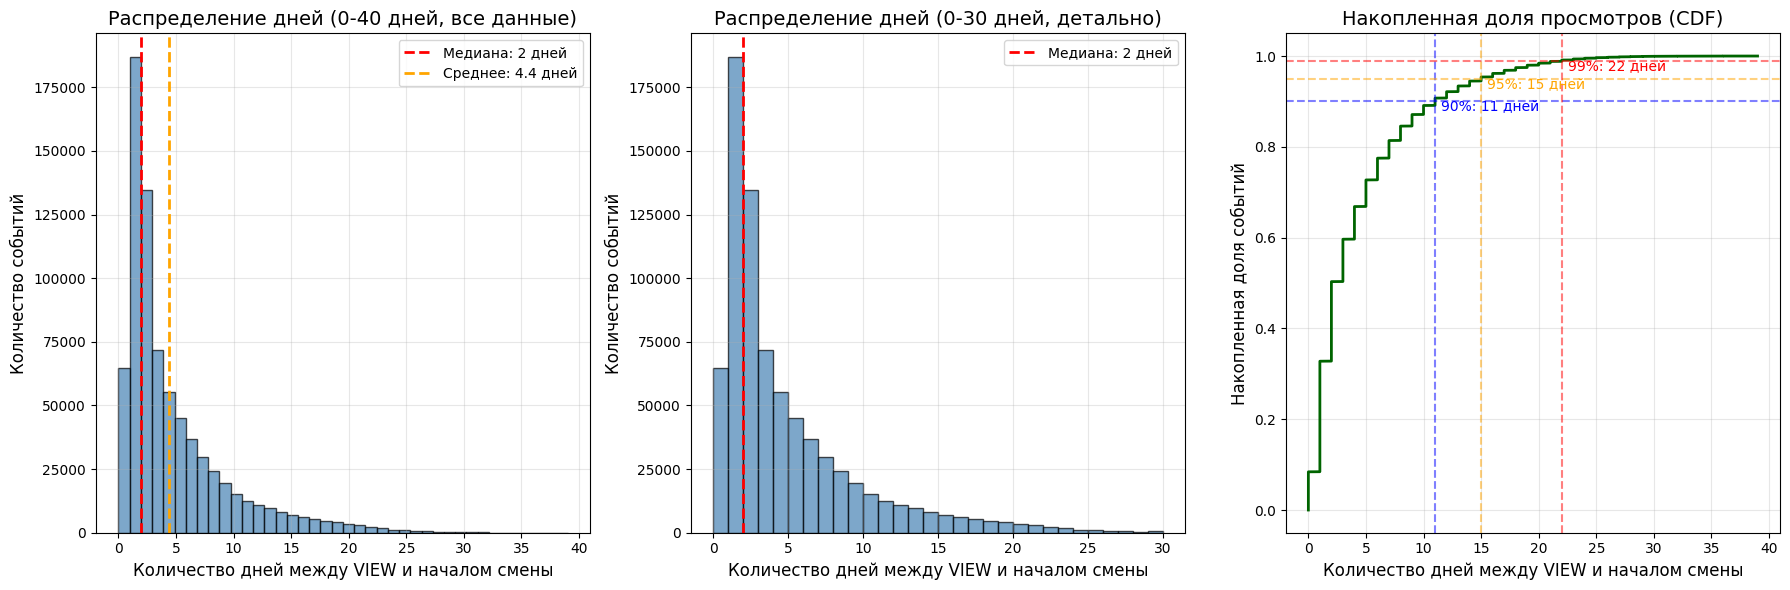

In [20]:
print("\nГистограмма распределения дней между VIEW и START_AT")

# Берем данные из предыдущего анализа
view_events = merged[merged['interaction'] == 'VIEW'].copy()
view_events['start_at'] = pd.to_datetime(view_events['start_at']).dt.tz_localize(None)
view_events['ts'] = pd.to_datetime(view_events['ts'])
view_events['days_between'] = (view_events['start_at'] - view_events['ts']).dt.days
view_events_valid = view_events[view_events['days_between'] >= 0]

# Будет фигура с тремя подграфиками
fig = plt.figure(figsize=(18, 6))

# График 1: Гистограмма для всех данных (0-40 дней)
ax1 = plt.subplot(1, 3, 1)
ax1.hist(view_events_valid['days_between'], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel('Количество дней между VIEW и началом смены', fontsize=12)
ax1.set_ylabel('Количество событий', fontsize=12)
ax1.set_title('Распределение дней (0-40 дней, все данные)', fontsize=14)
ax1.axvline(view_events_valid['days_between'].median(), color='red', linestyle='--', linewidth=2, label=f'Медиана: {view_events_valid["days_between"].median():.0f} дней')
ax1.axvline(view_events_valid['days_between'].mean(), color='orange', linestyle='--', linewidth=2, label=f'Среднее: {view_events_valid["days_between"].mean():.1f} дней')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Гистограмма для первых 30 дней (детально)
ax2 = plt.subplot(1, 3, 2)
view_30 = view_events_valid[view_events_valid['days_between'] <= 30]
ax2.hist(view_30['days_between'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax2.set_xlabel('Количество дней между VIEW и началом смены', fontsize=12)
ax2.set_ylabel('Количество событий', fontsize=12)
ax2.set_title('Распределение дней (0-30 дней, детально)', fontsize=14)
ax2.axvline(view_events_valid['days_between'].median(), color='red', linestyle='--', linewidth=2, label=f'Медиана: {view_events_valid["days_between"].median():.0f} дней')
ax2.legend()
ax2.grid(True, alpha=0.3)

# График 3: Накопленная доля (CDF)
ax3 = plt.subplot(1, 3, 3)
sorted_days = np.sort(view_events_valid['days_between'])
cdf = np.arange(1, len(sorted_days) + 1) / len(sorted_days)
ax3.plot(sorted_days, cdf, linewidth=2, color='darkgreen')
ax3.set_xlabel('Количество дней между VIEW и началом смены', fontsize=12)
ax3.set_ylabel('Накопленная доля событий', fontsize=12)
ax3.set_title('Накопленная доля просмотров (CDF)', fontsize=14)
ax3.grid(True, alpha=0.3)

# Добавляем линии для 90%, 95%, 99%
for p, color, label in zip([0.9, 0.95, 0.99], ['blue', 'orange', 'red'], ['90%', '95%', '99%']):
    days_at_p = sorted_days[int(p * len(sorted_days))]
    ax3.axhline(y=p, color=color, linestyle='--', alpha=0.5)
    ax3.axvline(x=days_at_p, color=color, linestyle='--', alpha=0.5)
    ax3.text(days_at_p + 0.5, p - 0.02, f'{label}: {days_at_p} дней', fontsize=10, color=color)

plt.tight_layout()
plt.show()

Предлагаем делать прогноз за 2 дня до старта смены (медиана кол-ва дней между просмотрами и стартом смены). Так из экстренного режима поиска исполнителей можно перейти в режим оптимизированного поиска заранее, до смены.

Посмотрим на медиану кол-ва дней между просмотрами и стартом смены в разрезе типов задач


Анализ долгосрочных просмотров по типам задач:

Колонки: ['id', 'shift_id', 'user_id', 'interaction', 'ts', 'location_id_user', 'is_strict_location', 'has_mk', 'start_at', 'location_id_shift', 'task_type', 'employer_id', 'workplace_id', 'need_mk', 'id_differential', 'hours', 'reward', 'capacity', 'days_between']
Есть task_type: True


ТОП-10 типов задач с наибольшей долей долгосрочных просмотров (>=15 дней):


Сопровождение товара и разгрузка:
    Всего просмотров: 2,816
    Долгосрочных (>=15 дней): 751 (26.67%)
    Среднее дней: 9.2
    Медиана дней: 7

Выдача заказов (OZON):
    Всего просмотров: 139
    Долгосрочных (>=15 дней): 21 (15.11%)
    Среднее дней: 4.6
    Медиана дней: 2

Помощь в прикассовой зоне:
    Всего просмотров: 59,497
    Долгосрочных (>=15 дней): 8,697 (14.62%)
    Среднее дней: 7.0
    Медиана дней: 5

Выдача заказов:
    Всего просмотров: 4,501
    Долгосрочных (>=15 дней): 500 (11.11%)
    Среднее дней: 5.3
    Медиана дней: 2

Погрузка и разгрузка товара:


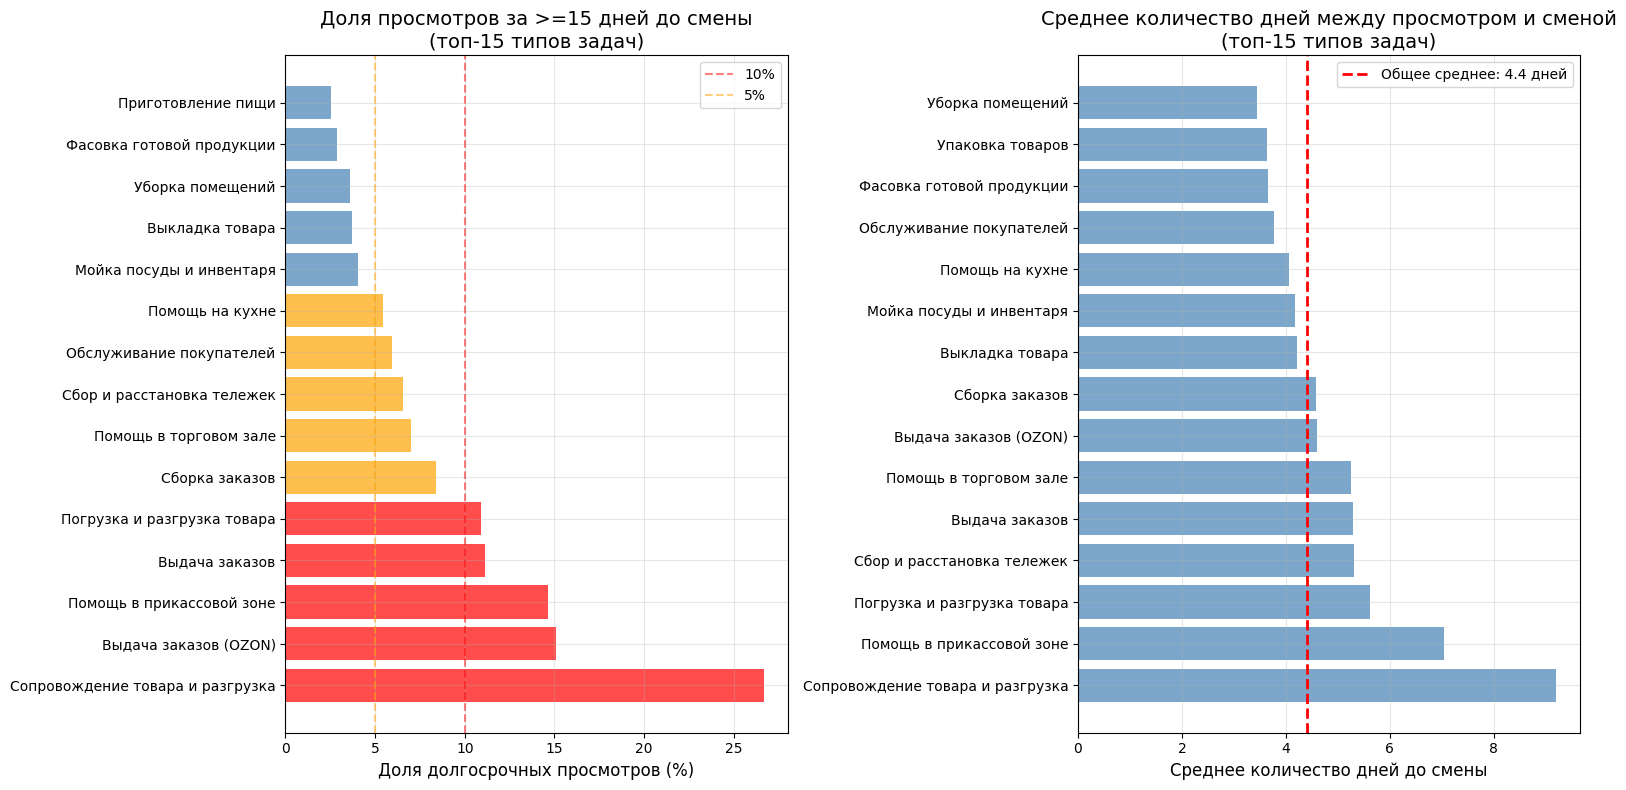

In [21]:

print("\nАнализ долгосрочных просмотров по типам задач:\n")

# Определяем долгосрочные просмотры (95+ перцентиль)
LONG_TERM_DAYS = 15  # просмотры за 15+ дней до смены

# Берем события VIEW и объединяем с shifts для получения task_type
view_events = merged[merged['interaction'] == 'VIEW'].copy()
view_events['start_at'] = pd.to_datetime(view_events['start_at']).dt.tz_localize(None)
view_events['ts'] = pd.to_datetime(view_events['ts'])
view_events['days_between'] = (view_events['start_at'] - view_events['ts']).dt.days
view_events_valid = view_events[view_events['days_between'] >= 0]

# Проверяем, есть ли колонка task_type
if 'task_type' not in view_events_valid.columns:
    # Добавляем информацию о типе задачи из таблицы shifts
    shifts_info = shifts[['id', 'task_type']].copy()
    view_events_valid = view_events_valid.merge(
        shifts_info,
        left_on='shift_id',
        right_on='id',
        how='left'
    )
    print(f"Добавлена информация о task_type")

# Проверяем, что task_type есть
print(f"Колонки: {view_events_valid.columns.tolist()}")
print(f"Есть task_type: {'task_type' in view_events_valid.columns}")

# Категоризируем просмотры
view_events_valid['view_type'] = view_events_valid['days_between'].apply(
    lambda x: 'long_term' if x >= LONG_TERM_DAYS else 'short_term'
)

# Статистика по типам задач
task_stats = view_events_valid.groupby('task_type').agg(
    total_views=('interaction', 'count'),
    long_term_views=('view_type', lambda x: (x == 'long_term').sum()),
    short_term_views=('view_type', lambda x: (x == 'short_term').sum()),
    avg_days=('days_between', 'mean'),
    median_days=('days_between', 'median')
).reset_index()


# Добавляем процент долгосрочных просмотров
task_stats['long_term_pct'] = task_stats['long_term_views'] / task_stats['total_views'] * 100

# Сортируем по проценту долгосрочных просмотров
task_stats_sorted = task_stats.sort_values('long_term_pct', ascending=False)

print(f"\n\nТОП-10 типов задач с наибольшей долей долгосрочных просмотров (>={LONG_TERM_DAYS} дней):\n")

for _, row in task_stats_sorted.head(10).iterrows():
    print(f"\n{row['task_type']}:")
    print(f"    Всего просмотров: {row['total_views']:,}")
    print(f"    Долгосрочных (>={LONG_TERM_DAYS} дней): {row['long_term_views']:,} ({row['long_term_pct']:.2f}%)")
    print(f"    Среднее дней: {row['avg_days']:.1f}")
    print(f"    Медиана дней: {row['median_days']:.0f}")


# Типы задач с наименьшей долей долгосрочных просмотров
print("\n\nТОП-10 типов задач с наименьшей долей долгосрочных просмотров:\n")

for _, row in task_stats_sorted.tail(10).iterrows():
    print(f"\n{row['task_type']}:")
    print(f"    Всего просмотров: {row['total_views']:,}")
    print(f"    Долгосрочных (>={LONG_TERM_DAYS} дней): {row['long_term_views']:,} ({row['long_term_pct']:.2f}%)")
    print(f"    Среднее дней: {row['avg_days']:.1f}")
    print(f"    Медиана дней: {row['median_days']:.0f}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# График 1: Доля долгосрочных просмотров по типам задач (топ-15)
ax1 = axes[0]
top_tasks = task_stats_sorted.head(15)
colors = ['red' if x > 10 else 'orange' if x > 5 else 'steelblue' for x in top_tasks['long_term_pct']]
ax1.barh(range(len(top_tasks)), top_tasks['long_term_pct'], color=colors, alpha=0.7)
ax1.set_yticks(range(len(top_tasks)))
ax1.set_yticklabels(top_tasks['task_type'], fontsize=10)
ax1.set_xlabel('Доля долгосрочных просмотров (%)', fontsize=12)
ax1.set_title(f'Доля просмотров за >={LONG_TERM_DAYS} дней до смены\n(топ-15 типов задач)', fontsize=14)
ax1.axvline(x=10, color='red', linestyle='--', alpha=0.5, label='10%')
ax1.axvline(x=5, color='orange', linestyle='--', alpha=0.5, label='5%')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Среднее количество дней до смены по типам задач
ax2 = axes[1]
avg_days_sorted = task_stats.sort_values('avg_days', ascending=False).head(15)
ax2.barh(range(len(avg_days_sorted)), avg_days_sorted['avg_days'], color='steelblue', alpha=0.7)
ax2.set_yticks(range(len(avg_days_sorted)))
ax2.set_yticklabels(avg_days_sorted['task_type'], fontsize=10)
ax2.set_xlabel('Среднее количество дней до смены', fontsize=12)
ax2.set_title('Среднее количество дней между просмотром и сменой\n(топ-15 типов задач)', fontsize=14)
ax2.axvline(x=view_events_valid['days_between'].mean(), color='red', linestyle='--', linewidth=2, label=f'Общее среднее: {view_events_valid["days_between"].mean():.1f} дней')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Видим, что разные типы задач имеют разные значения медианы и среднего значения кол-ва дней между просмотрами и стартом смены.

Для учебной задачи в рамках хакатона  будем делать прогноз за 2 дня до смены (медиана). Но как потенциал для развития модели в рабочем процессе предлагам время показа смены пользователю (насколько заранее до смены) также адаптировать под тип задачи на основании статистического анализа

In [22]:
print("\nШаг 1: базовые, временные и оконные признаки смены:")

# 1. Подготовка данных

print("\n1. Подготовка данных\n")

# Параметры окна
WINDOW_END_OFFSET = 2
WINDOW_START_OFFSET = 28 + WINDOW_END_OFFSET  # = 30 дней

# Приводим даты к единому формату
merged['ts'] = pd.to_datetime(merged['ts']).dt.tz_localize(None)
merged['start_at'] = pd.to_datetime(merged['start_at']).dt.tz_localize(None)
merged['shift_id'] = merged['shift_id'].astype('int64')

# Подготовка shifts
shifts_clean = shifts.copy()
shifts_clean['id'] = shifts_clean['id'].astype('int64')
shifts_clean['start_at'] = pd.to_datetime(shifts_clean['start_at']).dt.tz_localize(None)
shifts_clean['reward_per_hour'] = shifts_clean['reward'] / shifts_clean['hours']

# Создаем features_df с парами (user, shift)
features_df = target_correct[['user_id', 'shift_id', 'target']].copy()
features_df['shift_id'] = features_df['shift_id'].astype('int64')

# Добавляем информацию о смене (включая reward_per_hour)
shift_cols = ['id', 'start_at', 'location_id', 'task_type', 'employer_id', 'workplace_id', 'need_mk', 'id_differential', 'hours', 'reward', 'capacity', 'reward_per_hour']
features_df = features_df.merge(shifts_clean[shift_cols], left_on='shift_id', right_on='id', how='left')
features_df['start_at'] = pd.to_datetime(features_df['start_at'])

# Добавляем информацию о пользователе
users_clean = users.rename(columns={'id': 'user_id', 'location_id': 'location_id_user'})
features_df = features_df.merge(users_clean[['user_id', 'location_id_user', 'is_strict_location', 'has_mk']], on='user_id', how='left')
features_df = features_df.rename(columns={'location_id': 'location_id_shift'})

print(f"Всего пар (user, shift): {len(features_df):,}")

# Фильтруем train (февраль) и test (март)
train_df = features_df[(features_df['start_at'] >= '2026-02-01') & (features_df['start_at'] <= '2026-02-28')].copy()
test_df = features_df[(features_df['start_at'] >= '2026-03-01') & (features_df['start_at'] <= '2026-03-22')].copy()

print(f"Train: {len(train_df):,} пар, Test: {len(test_df):,} пар")


# 2. Функция добавления оконных статистик (память эффективная)

print("\n2. Добавление оконных статистик\n")

# Векторизованное добавление оконных статистик (без кросс-джойна)
# Использует группировку по датам и скользящее окно
def add_window_features_vectorized(df, shifts_history, window_start_offset, window_end_offset):
        
    df = df.copy()

    # Агрегируем смены по дням (медианная оплата за день)
    daily_median = shifts_history.groupby(shifts_history['start_at'].dt.normalize())['reward_per_hour'].median().reset_index()
    daily_median.columns = ['date', 'daily_median_pay']
    daily_median = daily_median.sort_values('date')

    # Создаем полный календарь дат от минимальной до максимальной
    date_range = pd.date_range(
        start=daily_median['date'].min() - timedelta(days=window_start_offset),
        end=daily_median['date'].max(),
        freq='D'
    )

    # Заполняем пропуски (дни без смен) - используем последнее известное значение
    daily_median_full = daily_median.set_index('date').reindex(date_range, method='ffill').reset_index()
    daily_median_full.columns = ['date', 'daily_median_pay']

    # Рассчитываем скользящую медиану за окно [T-30, T-2]
    daily_median_full['rolling_median'] = daily_median_full['daily_median_pay'].rolling(
        window=window_start_offset - window_end_offset,  # 28 дней
        min_periods=1
    ).median()

    # Сдвигаем на window_end_offset (чтобы не использовать T и T-1)
    daily_median_full['median_pay_window'] = daily_median_full['rolling_median'].shift(window_end_offset)

    # Добавляем дату смены (нормализованную) для джойна
    df['shift_date'] = df['start_at'].dt.normalize()

    # Мерджим с рассчитанной медианой
    df = df.merge(daily_median_full[['date', 'median_pay_window']], left_on='shift_date', right_on='date', how='left')

    # Значение по умолчанию, для дат без данных (самые ранние) используем общую медиану
    global_median = shifts_history['reward_per_hour'].median()
    df['median_pay_window'] = df['median_pay_window'].fillna(global_median)

    # Создаем признак на основе окна
    df['is_high_paid_window'] = (df['reward_per_hour'] > df['median_pay_window']).astype(int)

    # Удаляем вспомогательные колонки
    df = df.drop(columns=['shift_date'])

    return df

# Добавляем оконные признаки для train
print("Добавление оконных признаков для train...")
train_df = add_window_features_vectorized(train_df, shifts_clean, WINDOW_START_OFFSET, WINDOW_END_OFFSET)

# Добавляем оконные признаки для test
print("Добавление оконных признаков для test...")
test_df = add_window_features_vectorized(test_df, shifts_clean, WINDOW_START_OFFSET, WINDOW_END_OFFSET)

print("Оконные признаки добавлены (векторизовано, без кросс-джойна):")
print("     - median_pay_window (числовой) - медианная оплата в окне [T-30, T-2]")
print("     - is_high_paid_window (бинарный) - выше ли оплата медианы окна")


# 3. Базовые признаки смены

print("\n3. Базовые признаки смены\n")

def add_basic_features(df):
    
    df = df.copy()

    # is_long_shift - длинная смена (>8 часов)
    df['is_long_shift'] = (df['hours'] > 8).astype(int)

    # is_short_shift - короткая смена (<4 часов)
    df['is_short_shift'] = (df['hours'] < 4).astype(int)

    # mk_match - совпадение медкнижки
    df['mk_match'] = (df['has_mk'] == df['need_mk']).astype(int)

    # Новый признак: 3 состояния для медкнижки
    # 0 - книжка нужна, но у пользователя её нет
    # 1 - книжка нужна, и она есть у пользователя
    # 2 - книжка не нужна
    df['mk_match_2'] = np.where(
        df['need_mk'] == 1,                 # если книжка нужна
        np.where(df['has_mk'] == 1, 1, 0),  # то 1 если есть, 0 если нет
        2                                   # если книжка не нужна
    ).astype(int)

    # location_match - совпадение локации
    df['location_match'] = (df['location_id_user'] == df['location_id_shift']).astype(int)

    return df

train_df = add_basic_features(train_df)
test_df = add_basic_features(test_df)

print("Добавлены базовые признаки:")
print("     - is_long_shift (бинарный)")
print("     - is_short_shift (бинарный)")
print("     - mk_match (бинарный)")
print("     - location_match (бинарный)")


# 4. Временные признаки смены (Группа 2)

print("\n4. Временные признаки смены\n")

# Праздничные дни
holidays = pd.to_datetime(['2026-01-01', '2026-01-02', '2026-01-03', '2026-01-04', '2026-01-05',
                           '2026-01-06', '2026-01-07', '2026-01-08', '2026-01-09', '2026-01-10',
                           '2026-01-11', '2026-02-23', '2026-03-09', '2026-05-01', '2026-05-11'])

# Векторизованная проверка буднего дня
def is_weekday_vectorized(date_series):    
    is_weekend = date_series.dt.dayofweek >= 5
    is_holiday = date_series.isin(holidays)
    return (~is_weekend & ~is_holiday).astype(int)

#Векторизованное определение времени суток
def get_time_of_day_vectorized(hour_series):
    conditions = [
        (hour_series >= 6) & (hour_series < 12),
        (hour_series >= 12) & (hour_series < 18),
        (hour_series >= 18) & (hour_series < 24),
        (hour_series < 6) | (hour_series >= 24)
    ]
    choices = ['morning', 'day', 'evening', 'night']
    return np.select(conditions, choices, default='night')

# Векторизованное добавление временных признаков
def add_temporal_features_vectorized(df):
    
    df = df.copy()

    # shift_day_of_week - день недели (0=пн...6=вс)
    df['shift_day_of_week'] = df['start_at'].dt.dayofweek

    # shift_hour - час начала (0-23)
    df['shift_hour'] = df['start_at'].dt.hour

    # shift_time_of_day - время суток (векторизовано)
    df['shift_time_of_day'] = get_time_of_day_vectorized(df['shift_hour'])

    # is_weekday - будний день (векторизовано)
    df['shift_date'] = df['start_at'].dt.normalize()
    df['is_weekday'] = is_weekday_vectorized(df['shift_date'])

    # Удаляем вспомогательную колонку
    df = df.drop(columns=['shift_date'])

    return df

train_df = add_temporal_features_vectorized(train_df)
test_df = add_temporal_features_vectorized(test_df)

print("Добавлены временные признаки (векторизовано):")
print("     - shift_day_of_week (категориальный: 0-6)")
print("     - shift_hour (категориальный: 0-23)")
print("     - shift_time_of_day (категориальный: morning/day/evening/night)")
print("     - is_weekday (бинарный)")


# 5. Прверка результатов

print("\n\nПрверка результатов:")

print(f"\nTrain размер: {train_df.shape}")
print(f"Test размер: {test_df.shape}")

print("\nTrain примеры признаков (с оконными статистиками):")
print(train_df[['shift_id', 'start_at', 'reward_per_hour', 'median_pay_window', 'is_high_paid_window', 'is_long_shift', 'is_short_shift', 
                'mk_match', 'location_match', 'shift_day_of_week', 'shift_hour', 'shift_time_of_day', 'is_weekday']].head(10))

print("\nРаспределение is_weekday в Train:")
print(train_df['is_weekday'].value_counts())


Шаг 1: базовые, временные и оконные признаки смены:

1. Подготовка данных

Всего пар (user, shift): 757,976
Train: 225,971 пар, Test: 221,116 пар

2. Добавление оконных статистик

Добавление оконных признаков для train...
Добавление оконных признаков для test...
Оконные признаки добавлены (векторизовано, без кросс-джойна):
     - median_pay_window (числовой) - медианная оплата в окне [T-30, T-2]
     - is_high_paid_window (бинарный) - выше ли оплата медианы окна

3. Базовые признаки смены

Добавлены базовые признаки:
     - is_long_shift (бинарный)
     - is_short_shift (бинарный)
     - mk_match (бинарный)
     - location_match (бинарный)

4. Временные признаки смены

Добавлены временные признаки (векторизовано):
     - shift_day_of_week (категориальный: 0-6)
     - shift_hour (категориальный: 0-23)
     - shift_time_of_day (категориальный: morning/day/evening/night)
     - is_weekday (бинарный)


Прверка результатов:

Train размер: (225971, 30)
Test размер: (221116, 30)

Train приме

In [23]:
# Расчет группы 3 и 4

start = time.time()                 

print("Группа 3: Тип задачи\n")  

# словарь для мэппинга типов задач
task_category_mapping = {
    'Выкладка товара': 'store_warehouse', 'Сборка заказов': 'store_warehouse', 'Упаковка товаров': 'store_warehouse', 'Фасовка готовой продукции': 'store_warehouse',
    'Инвентаризация склада': 'store_warehouse', 'Помощь в торговом зале': 'customer_service', 'Обслуживание покупателей': 'customer_service',
    'Помощь в прикассовой зоне': 'customer_service', 'Выдача заказов': 'customer_service', 'Выдача заказов (Wildberries)': 'customer_service', 
    'Выдача заказов (OZON)': 'customer_service', 'Контроль порядка в торговом зале': 'customer_service', 'Обслуживание посетителей кафе': 'customer_service',
    'Обслуживание в гардеробе': 'customer_service', 'Приготовление пищи': 'food_kitchen', 'Помощь на кухне': 'food_kitchen', 'Мойка посуды и инвентаря': 'food_kitchen', 
    'Выпечка хлеба': 'food_kitchen', 'Уборка помещений': 'cleaning', 'Уборка на улице': 'cleaning', 'Погрузка и разгрузка товара': 'loading', 
    'Сопровождение товара и разгрузка': 'loading', 'Подсобные работы': 'loading', 'Сбор и расстановка тележек': 'loading', 'Доставка заказов на авто': 'delivery_car', 
    'Доставка заказов на велосипеде': 'delivery_bike', 'Доставка заказов пешком': 'delivery_walk', 'Сборка букетов': 'other', 'Помощь в парке развлечений': 'other'
}  

for df in [train_df, test_df]:                                                              # применяем к train и test
    df['task_category'] = df['task_type'].map(task_category_mapping)                        # добавляем категорию задачи
    
print('     Добавлен признак task_category')


print("\nГруппа 4: Исторические признаки\n")  

WINDOW_END_OFFSET = 2                                                                       # конец окна за 2 дня до смены
WINDOW_START_OFFSET = 28 + WINDOW_END_OFFSET                                                # начало окна за 30 дней до смены

df_all = merged[['shift_id', 'user_id', 'interaction', 'ts', 'start_at', 'location_id_shift']].copy()  # берем нужные колонки истории
df_all['ts'] = pd.to_datetime(df_all['ts']).dt.tz_localize(None)                            # приводим время события
df_all['start_at'] = pd.to_datetime(df_all['start_at']).dt.tz_localize(None)                # приводим старт смены

shifts_clean = shifts.copy()  
shifts_clean['id'] = shifts_clean['id'].astype('int64')                                     # приводим id к int
shifts_clean['start_at'] = pd.to_datetime(shifts_clean['start_at']).dt.tz_localize(None)    # приводим дату старта
shifts_clean['reward_per_hour'] = shifts_clean['reward'] / shifts_clean['hours']            # считаем оплату в час
median_pay_global = shifts_clean['reward_per_hour'].median()                                # глобальная медиана оплаты

shifts_info = shifts_clean[['id', 'employer_id', 'location_id', 'hours', 'reward', 'reward_per_hour', 'task_type']].copy()          # берем нужные поля смен
shifts_info = shifts_info.rename(columns={'id': 'shift_id', 'location_id': 'shift_location_id', 'task_type': 'shift_task_type'})    # переименовываем поля

df_all = df_all.merge(shifts_info, on='shift_id', how='left')                               # добавляем информацию о смене
df_all = df_all.merge(
    users[['id', 'location_id']].rename(columns={'id': 'user_id', 'location_id': 'location_id_user'}),
    on='user_id',
    how='left'
)                                                                                           # добавляем локацию пользователя

df_all['task_category'] = df_all['shift_task_type'].map(task_category_mapping)              # добавляем категорию задачи

pairs_with_cancel = df_all[df_all['interaction'].isin(['USER_CANCEL', 'SYSTEM_CANCEL'])][['user_id', 'shift_id']].drop_duplicates()  # пары с отменами
pairs_with_cancel['has_cancel'] = 1                                                         # флаг отмены
df_all = df_all.merge(pairs_with_cancel, on=['user_id', 'shift_id'], how='left')            # добавляем флаг отмены
df_all['has_cancel'] = df_all['has_cancel'].fillna(0)                                       # заполняем отсутствие отмены нулем
df_all['is_successful'] = ((df_all['interaction'] == 'APPLY') & (df_all['has_cancel'] == 0)).astype(int)  # успешный apply без отмены
df_all = df_all.drop(columns=['has_cancel'])                                                # это был временный столбец

# оставляем только нужные колонки для merge
df_all_for_hist = df_all[['user_id', 'shift_id', 'interaction', 'ts', 'is_successful', 'employer_id', 'shift_task_type', 'shift_location_id', 'reward_per_hour', 'hours']].copy()  

df_all_for_hist = df_all_for_hist.rename(columns={'shift_id': 'hist_shift_id'})             # переименовываем исторический shift_id

# print(f"df_all создан: {df_all.shape}")  
print(f"Успешных действий: {df_all['is_successful'].sum():,}")                              # количество успехов

# функция расчета признаков для одного батча
def add_historical_features_fast(df, df_all_for_hist, dataset_name=""):  
    df = df.copy()  
    df['_row_id'] = np.arange(len(df))                                                      # сохраняем порядок строк внутри батча
    df['win_start'] = df['start_at'] - timedelta(days=WINDOW_START_OFFSET)                  # начало окна
    df['win_end'] = df['start_at'] - timedelta(days=WINDOW_END_OFFSET)                      # конец окна

    pairs = df[['_row_id', 'user_id', 'shift_id', 'win_start', 'win_end', 'location_id_shift']].copy()  # строки батча

    hist = pairs.merge(df_all_for_hist, on='user_id', how='left')                           # история пользователя
    hist = hist[(hist['ts'] >= hist['win_start']) & (hist['ts'] < hist['win_end'])]         # оставляем события в окне

    result = df[['_row_id']].copy()                                                         # для результата

    if len(hist) > 0:                                                                       # если есть история в окне
        hist['event_date'] = hist['ts'].dt.date                                             # дата события для подсчета активных дней

        active_stats = hist.groupby('_row_id').agg(user_active_days=('event_date', 'nunique')).reset_index()  # активные дни по всем событиям
        view_stats = hist[hist['interaction'] == 'VIEW'].groupby('_row_id').agg(user_total_views=('hist_shift_id', 'nunique')).reset_index()  # уникальные просмотренные смены
        succ_hist = hist[hist['is_successful'] == 1].drop_duplicates(['_row_id', 'hist_shift_id']).copy()  # уникальные успешные смены

        succ_stats = succ_hist.groupby('_row_id').agg(
            user_total_successful_actions=('hist_shift_id', 'nunique'),
            user_unique_employers=('employer_id', 'nunique'),
            user_unique_task_types=('shift_task_type', 'nunique'),
            user_avg_reward_per_hour=('reward_per_hour', 'mean')
        ).reset_index()                                                                     # агрегаторы успешной истории

        if len(succ_hist) > 0:                                                              # если есть успешные действия
            succ_hist['loc_match'] = (succ_hist['shift_location_id'] == succ_hist['location_id_shift']).astype(int)  # совпадение локации
            succ_hist['high_paid'] = (succ_hist['reward_per_hour'] > median_pay_global).astype(int)  # выше медианной оплаты
            succ_hist['long_shift'] = (succ_hist['hours'] > 8).astype(int)                  # длинная смена
            succ_hist['short_shift'] = (succ_hist['hours'] < 4).astype(int)                 # короткая смена

            ratio_stats = succ_hist.groupby('_row_id').agg(
                user_location_experience=('loc_match', 'sum'),
                user_high_paid_ratio=('high_paid', 'mean'),
                user_long_shift_ratio=('long_shift', 'mean'),
                user_short_shift_ratio=('short_shift', 'mean')
            ).reset_index()                                                                 # доли и опыт по успешным сменам
        else:
            ratio_stats = pd.DataFrame(columns=[
                '_row_id', 'user_location_experience', 'user_high_paid_ratio',
                'user_long_shift_ratio', 'user_short_shift_ratio'
            ])                                                                              # тут пустая таблица долей

        result = result.merge(active_stats, on='_row_id', how='left')                       # добавляем активные дни
        result = result.merge(view_stats, on='_row_id', how='left')                         # добавляем просмотры
        result = result.merge(succ_stats, on='_row_id', how='left')                         # добавляем успешные агрегаты
        result = result.merge(ratio_stats, on='_row_id', how='left')                        # добавляем доли
        
    else:
        result['user_active_days'] = np.nan                                                 # нет истории
        result['user_total_views'] = np.nan                                                 # нет просмотров
        result['user_total_successful_actions'] = np.nan                                    # нет успешных действий

    result['user_total_views'] = result['user_total_views'].fillna(0).astype(int)           # нет просмотров -> 0
    result['user_total_successful_actions'] = result['user_total_successful_actions'].fillna(0).astype(int)  # нет успехов -> 0
    result['user_active_days'] = result['user_active_days'].fillna(0).astype(int)           # нет активных дней -> 0

    has_history = result['user_active_days'] > 0                                            # была ли история в окне
    
    # нет истории -> -1, история без просмотров -> 0
    result['user_success_rate'] = np.where(has_history, np.where(result['user_total_views'] > 0, 
                                                                 result['user_total_successful_actions'] / result['user_total_views'], 0), -1)  

    success_hist_ftrs = ['user_unique_employers', 'user_unique_task_types', 'user_location_experience', 'user_high_paid_ratio', 
                         'user_long_shift_ratio', 'user_short_shift_ratio', 'user_avg_reward_per_hour'] # признаки успешной истории
    for col in success_hist_ftrs:  
        if col not in result.columns:                                                        
            result[col] = -1                                                                # если колонка не создалась, то ставим -1
        else:
            result[col] = result[col].fillna(-1)                                            # нет успешной истории, ставим -1

    result = result.drop(columns=['_row_id'])                                               # убираем технический id из результата
    df = df.drop(columns=['win_start', 'win_end'])                                          # убираем временные окна из батча
    df = pd.concat([df.reset_index(drop=True), result.reset_index(drop=True)], axis=1)      # добавляем признаки
    df = df.drop(columns=['_row_id'])                                                       # убираем технический id

    return df                                                                               # тут будет обработанный батч

# функция обработки батчей
def add_historical_features_batched(df, df_all_for_hist, dataset_name="", batch_size=5000): 
    
    parts = []                                                                              # тут буду обработанные батчи

    # цикл по батчам
    for start_idx in tqdm(range(0, len(df), batch_size), desc=f"{dataset_name} batches"):  
        end_idx = start_idx + batch_size                                                    # конец батча
        batch = df.iloc[start_idx:end_idx].copy()                                           # берем батч

        batch = add_historical_features_fast(batch, df_all_for_hist, dataset_name=f"{dataset_name} batch {start_idx // batch_size + 1}")  # считаем признаки батча

        parts.append(batch)  

    result = pd.concat(parts, axis=0, ignore_index=True)                                    # объединяем батчи
    # print(f"{dataset_name}: добавлены исторические признаки {result.shape}")  
    return result                                                                           # тут будет полный датасет


print("\nРасчет исторических признаков батчами...")  
cols_before = set(train_df.columns)

train_df = add_historical_features_batched(train_df, df_all_for_hist, "train", batch_size=5000)  # считаем train батчами
test_df = add_historical_features_batched(test_df, df_all_for_hist, "test", batch_size=5000) # считаем test батчами

cols_after = set(train_df.columns)                                               
n_added = len(cols_after - cols_before) 
new_cols = cols_after - cols_before                                         

print(f"\nДобавлены {n_added} исторических признаков: ")
for col in sorted(new_cols):                                                                # сортирую для читаемости
    print(f"  - {col}")
    
print(f"\nВремя выполнения: {time.time() - start:.2f} сек")  

Группа 3: Тип задачи

     Добавлен признак task_category

Группа 4: Исторические признаки

Успешных действий: 15,919

Расчет исторических признаков батчами...


test batches: 100%|██████████| 45/45 [00:44<00:00,  1.00it/s]


Добавлены 11 исторических признаков: 
  - user_active_days
  - user_avg_reward_per_hour
  - user_high_paid_ratio
  - user_location_experience
  - user_long_shift_ratio
  - user_short_shift_ratio
  - user_success_rate
  - user_total_successful_actions
  - user_total_views
  - user_unique_employers
  - user_unique_task_types

Время выполнения: 93.52 сек


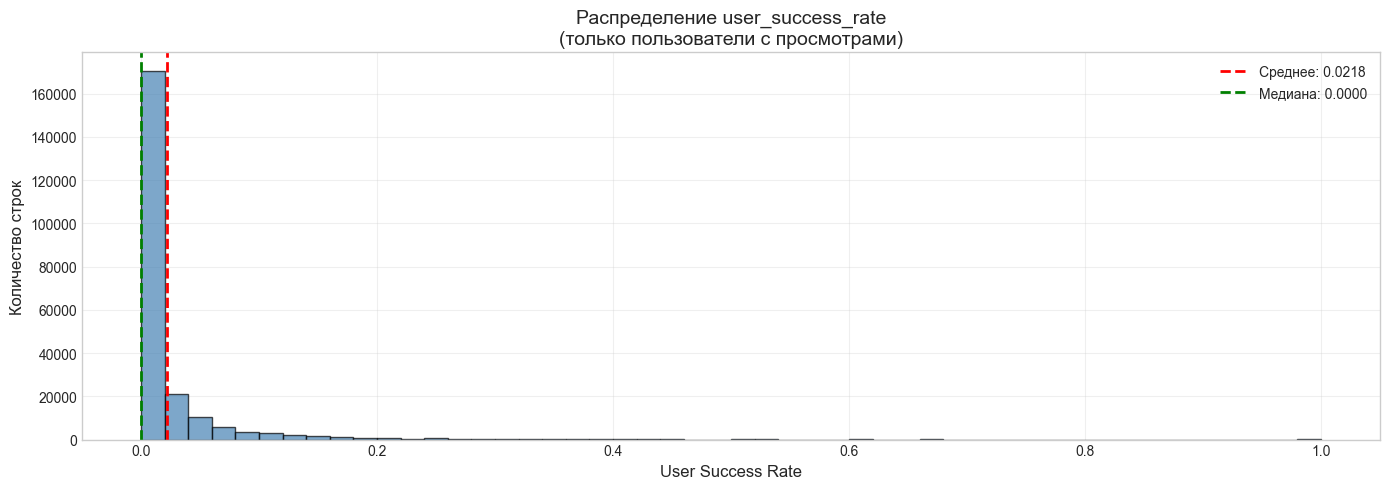


Статистика распределения USER_SUCCESS_RATE


Всего строк с просмотрами: 223,542
Среднее: 0.021791
Медиана: 0.000000
Стандартное отклонение: 0.061525
Минимум: 0.000000
Максимум: 1.000000

Квантили:
   25.0%: 0.000000
   50.0%: 0.000000
   75.0%: 0.018116
   90.0%: 0.058394
   95.0%: 0.105263
   99.0%: 0.285714

Распределение по диапазонам:
  0           : 150,462 (67.31%) █████████████████████████████████
  0-0.01      : 47,356 (21.18%) ██████████
  0.01-0.05   : 14,055 ( 6.29%) ███
  0.05-0.1    :  7,905 ( 3.54%) █
  0.1-0.2     :  1,789 ( 0.80%) 
  0.2-0.3     :    912 ( 0.41%) 
  0.3-0.4     :    490 ( 0.22%) 
  0.4-0.5     :    159 ( 0.07%) 
  0.5-0.6     :    119 ( 0.05%) 
  0.6-0.7     :     94 ( 0.04%) 
  0.7-0.8     :     20 ( 0.01%) 
  0.8-0.9     :    181 ( 0.08%) 
  0.9-1.0     :      0 ( 0.00%) 


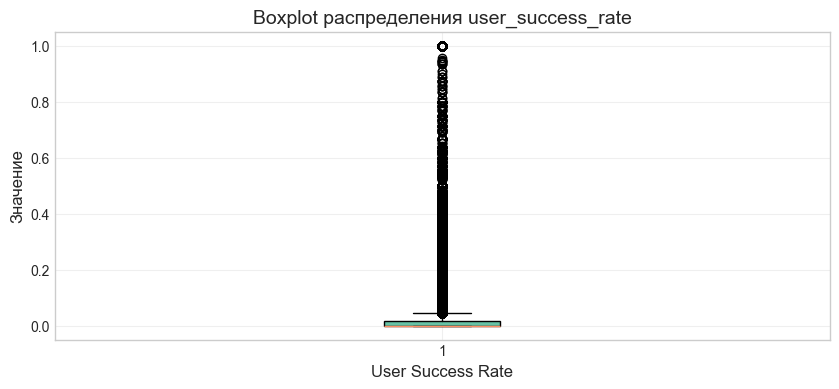

In [24]:
# Посмотрим на успешные действия пользователей

# Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Создаем фигуру с одним графиком (не массивом)
fig, ax = plt.subplots(1, 1, figsize=(14, 5))

# Берем только пользователей с просмотрами
success_rates = train_df[train_df['user_total_views'] > 0]['user_success_rate']

ax.hist(success_rates, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('User Success Rate', fontsize=12)
ax.set_ylabel('Количество строк', fontsize=12)
ax.set_title('Распределение user_success_rate\n(только пользователи с просмотрами)', fontsize=14)
ax.axvline(success_rates.mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {success_rates.mean():.4f}')
ax.axvline(success_rates.median(), color='green', linestyle='--', linewidth=2, label=f'Медиана: {success_rates.median():.4f}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Дополнительная статистика
print("\nСтатистика распределения USER_SUCCESS_RATE\n")

print(f"\nВсего строк с просмотрами: {len(success_rates):,}")
print(f"Среднее: {success_rates.mean():.6f}")
print(f"Медиана: {success_rates.median():.6f}")
print(f"Стандартное отклонение: {success_rates.std():.6f}")
print(f"Минимум: {success_rates.min():.6f}")
print(f"Максимум: {success_rates.max():.6f}")

print(f"\nКвантили:")
for q in [0.25, 0.5, 0.75, 0.9, 0.95, 0.99]:
    print(f"  {q*100:5.1f}%: {success_rates.quantile(q):.6f}")


# Распределение по диапазонам

print(f"\nРаспределение по диапазонам:")
# Количество границ = количество меток + 1
bins = [0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.01]
# Добавили 1.01, чтобы включить значения = 1.0

labels = ['0', '0-0.01', '0.01-0.05', '0.05-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5', '0.5-0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']

# Используем pd.cut с правильным количеством границ
train_df['rate_bin'] = pd.cut(train_df['user_success_rate'], bins=bins, labels=labels, include_lowest=True)
bin_counts = train_df[train_df['user_total_views'] > 0]['rate_bin'].value_counts().sort_index()

for label in labels:
    count = bin_counts.get(label, 0)
    pct = count / len(success_rates) * 100
    bar = '█' * int(pct / 2)
    print(f"  {label:12}: {count:6,} ({pct:5.2f}%) {bar}")

# График
plt.figure(figsize=(10, 4))
plt.boxplot(success_rates, vert=True, patch_artist=True)
plt.xlabel('User Success Rate', fontsize=12)
plt.ylabel('Значение', fontsize=12)
plt.title('Boxplot распределения user_success_rate', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
# Признаки 5-14 групп

start = time.time()

warnings.filterwarnings('ignore')

# Сбор словарей (общий проход)
print("Сбор словарей...")

shift_start_map = dict(zip(shifts_clean['id'], shifts_clean['start_at']))

# Словари для всех групп
success_by_user = defaultdict(list)                                                                              # группа 5
successful_raw = defaultdict(set)                                                                                # группа 6
successful_cat = defaultdict(set)                                                                                # группа 6
user_employers_successful = defaultdict(set)                                                                     # группа 6
employer_data = defaultdict(lambda: {'shifts': set(), 'rewards': [], 'users': set(), 'system_cancels': set()})   # группа 7
shift_applies_views = defaultdict(lambda: [0, 0])                                                                # группа 8
applies_dict = defaultdict(list)                                                                                 # группа 8
user_shift_data = defaultdict(lambda: [0, 0])                                                                    # группа 9
user_day_shifts = defaultdict(list)                                                                              # группа 13
user_successful = defaultdict(list)                                                                              # группа 10

holidays_set = set(holidays.normalize())                                                                         # holidays задано в ячейках выше

for row in tqdm(df_all.itertuples(index=False), total=len(df_all), desc="Единый проход"):
    
    shift_id = row.shift_id                                                                                      # id смены
    shift_start = shift_start_map.get(shift_id)                                                                  # получаем старт смены

    if shift_start is None:                                                                                      # если смена отсутствует
        continue                                                                                                 # пропускаем строку

    pred_moment = shift_start - timedelta(days=2)                                                                # момент предсказания

    ts = row.ts
    user_id = row.user_id
    interaction = row.interaction
    emp_id = row.employer_id

    # Группа 8: статистика смены (все события до предсказания)
    if ts < pred_moment:
        if interaction == 'APPLY':
            shift_applies_views[shift_id][0] += 1
            applies_dict[shift_id].append(ts)
        elif interaction == 'VIEW':
            shift_applies_views[shift_id][1] += 1

        # Группа 7: статистика работодателя
        employer_data[emp_id]['shifts'].add(shift_id)
        employer_data[emp_id]['users'].add(user_id)
        if pd.notna(row.reward):
            employer_data[emp_id]['rewards'].append(row.reward)
        if interaction == 'SYSTEM_CANCEL':
            employer_data[emp_id]['system_cancels'].add(shift_id)

        # Группа 9: взаимодействие пользователя со сменой
        key = (user_id, shift_id)
        if interaction == 'VIEW':
            user_shift_data[key][0] += 1

    # Группы 5, 6, 10, 13 - только успешные действия 
    if getattr(row, 'is_successful', 0) == 1 and ts < pred_moment:
        # Группа 5 - скользящие окна
        success_by_user[user_id].append(ts)

        # Группа 6 - опыт по типу задач
        successful_raw[user_id].add(row.shift_task_type)
        successful_cat[user_id].add(row.task_category)
        user_employers_successful[user_id].add(emp_id)

        # Группа 9 - взаимодействие (успешный apply)
        user_shift_data[(user_id, shift_id)][1] = 1

        # Группа 10 - предпочтения пользователя
        shift_start = row.start_at
        hour = shift_start.hour
        is_wd = 0 if shift_start.normalize() in holidays_set or shift_start.dayofweek >= 5 else 1
        tod = ('morning' if 6 <= hour < 12 else
               'day' if 12 <= hour < 18 else
               'evening' if 18 <= hour < 24 else 'night')
        user_successful[user_id].append({'is_weekday': is_wd, 'time_of_day': tod})

        # Группа 13 - занятость в день смены
        key_day = (user_id, shift_start.date())
        start_hour = shift_start.hour
        end_hour = start_hour + row.hours
        user_day_shifts[key_day].append((start_hour, end_hour, shift_id))

# Сортируем списки дат
for uid in success_by_user:
    success_by_user[uid] = sorted(success_by_user[uid])
for sid in applies_dict:
    applies_dict[sid] = sorted(applies_dict[sid])

print(f"Единый проход завершён за {time.time() - start:.2f} сек")

# Предрасчеты
employer_stats_map = {}                                                                         # статистики работодателей
for emp_id, data in employer_data.items():                                                      # проходим по каждому работодателю
    total_shifts = len(data.get('shifts', set()))                                               # считаем число смен
    rewards = data.get('rewards', [])                                                           # берем список оплат
    avg_reward = np.mean(rewards) if rewards else 0                                             # средняя оплата
    popularity = len(data.get('users', set()))                                                  # число уникальных пользователей
    sys_cancels = len(data.get('system_cancels', set()))                                        # число системных отмен
    reliability = max(0, min(1, 1 - (sys_cancels / total_shifts))) if total_shifts > 0 else 1   # надежность работодателя
    employer_stats_map[emp_id] = (avg_reward, popularity, reliability)                          # сохраняем результат

user_prefs_map = {}                                                                             # предпочтения пользователей
for user_id, data in user_successful.items():                                                   # проходим по пользователям
    total = len(data)                                                                           # число успешных действий
    weekend_cnt = sum(1 for d in data if d['is_weekday'] == 0)                                  # число выходных
    day_cnt = sum(1 for d in data if d['time_of_day'] == 'day')                                 # число дневных смен
    evening_cnt = sum(1 for d in data if d['time_of_day'] == 'evening')                         # число вечерних смен
    night_cnt = sum(1 for d in data if d['time_of_day'] == 'night')                             # число ночных смен
    user_prefs_map[user_id] = (weekend_cnt / total, day_cnt / total, evening_cnt / total, night_cnt / total)  # сохраняем доли


# Группа 5: Скользящие окна (векторизованно через бинарный поиск в отсортированном списке)
print("\nГруппа 5: Скользящие окна")

def count_success_batch(ts_lists, win_starts, win_ends):
    results = []
    for ts_list, w_start, w_end in zip(ts_lists, win_starts, win_ends):
        if not ts_list:
            results.append(0)
        else:
            left = bisect.bisect_left(ts_list, np.datetime64(w_start))                          # индекс первой даты >= start
            right = bisect.bisect_left(ts_list, np.datetime64(w_end))                           # индекс первой даты >= end
            results.append(right - left)                                                        # количество дат в диапазоне
    return results

for df_name, df in [('train', train_df), ('test', test_df)]:
    for window_days in [7, 14]:
        win_start = df['start_at'] - timedelta(days=window_days)
        win_end = df['start_at'] - timedelta(days=WINDOW_END_OFFSET)
        ts_lists = [success_by_user.get(uid, []) for uid in df['user_id']]
        df[f'Успешные действия пользователя {window_days} дней'] = count_success_batch(ts_lists, win_start.values, win_end.values)

print("Добавлены 2 признака")


# Группа 6: опыт по типу задач 
print("\nГруппа 6: опыт по типу задач")

for df in [train_df, test_df]:
    df['user_task_type_experience'] = [1 if tt in successful_raw.get(uid, set()) else 0 for uid, tt in zip(df['user_id'], df['task_type'])]
    df['user_employer_experience'] = [1 if eid in user_employers_successful.get(uid, set()) else 0 for uid, eid in zip(df['user_id'], df['employer_id'])]

print("Добавлены 2 признака (user_task_type_experience, user_employer_experience)")


# Группа 7: признаки заказчика
print("\nГруппа 7: признаки заказчика")

for df in [train_df, test_df]:                                                                  # добавляем признаки работодателя
    stats = [employer_stats_map.get(eid, (0, 0, 1)) for eid in df['employer_id']]               # берем готовые значения
    df['employer_avg_reward'] = [s[0] for s in stats]                                           # средняя оплата работодателя
    df['employer_popularity'] = [s[1] for s in stats]                                           # популярность работодателя
    df['employer_reliability'] = [s[2] for s in stats]                                          # надежность работодателя

print("Добавлены 3 признака (employer_avg_reward, employer_popularity, employer_reliability)")


# Группа 8: попклярность смены
print("\nГруппа 8: популярность смены")

def count_applies_before_batch(shift_ids, pred_moments):
    results = []
    for sid, pm in zip(shift_ids, pred_moments):
        ts_list = applies_dict.get(sid, [])
        results.append(bisect.bisect_left(ts_list, np.datetime64(pm)) if ts_list else 0)
    return results

for df in [train_df, test_df]:
    df['shift_total_views'] = [shift_applies_views[sid][1] for sid in df['shift_id']]
    pred_moments = (df['start_at'] - timedelta(days=2)).values
    applies_before = count_applies_before_batch(df['shift_id'].values, pred_moments)
    df['free_spots_at_prediction'] = (df['capacity'] - np.array(applies_before)).clip(lower=0)
    df['is_full_at_prediction']    = (df['free_spots_at_prediction'] == 0).astype(int)

print("Добавлены 3 признака (shift_total_views, free_spots_at_prediction, is_full_at_prediction)")


# Группа 9: взаимодействие со сменой
print("\nГруппа 9: взаимодействие со сменой")

for df in [train_df, test_df]:
    keys = list(zip(df['user_id'].values, df['shift_id'].values))
    df['view_count_for_shift'] = [user_shift_data.get(k, [0, 0])[0] for k in keys]
    df['has_apply_before'] = [user_shift_data.get(k, [0, 0])[1] for k in keys]

print("Добавлены 2 признака (view_count_for_shift, has_apply_before)")


# Группа 10-11: предпочтения пользователя
print("\nГруппа 10-11: предпочтения пользователя")

for df in [train_df, test_df]:                                                      # добавляем предпочтения пользователей
    prefs = [user_prefs_map.get(uid, (-1, -1, -1, -1)) for uid in df['user_id']]    # берем готовые значения
    df['user_weekend_ratio'] = [p[0] for p in prefs]                                # доля выходных смен
    df['user_day_ratio'] = [p[1] for p in prefs]                                    # доля дневных смен
    df['user_evening_ratio'] = [p[2] for p in prefs]                                # доля вечерних смен
    df['user_night_ratio'] = [p[3] for p in prefs]                                  # доля ночных смен

print("Добавлены 4 признака")


# Группа 12: совпадение предпочтений
print("\nГруппа 12: совпадение предпочтений")

def get_match_vectorized(value, ratio, threshold=0.5):
    result = np.where(ratio == -1, -1, 0)
    result = np.where((value == 1) & (ratio > threshold), 1, result)
    return result

for df in [train_df, test_df]:
    df['matches_high_paid'] = get_match_vectorized(df['is_high_paid_window'].values, df['user_high_paid_ratio'].values)
    df['matches_long_shift'] = get_match_vectorized(df['is_long_shift'].values, df['user_long_shift_ratio'].values)
    df['matches_short_shift'] = get_match_vectorized(df['is_short_shift'].values, df['user_short_shift_ratio'].values)

    # matches_time_of_day векторизованно
    no_data = (df['user_day_ratio'] == -1) & (df['user_evening_ratio'] == -1) & (df['user_night_ratio'] == -1)
    ratios = df[['user_day_ratio', 'user_evening_ratio', 'user_night_ratio']].values
    times = np.array(['day', 'evening', 'night'])
    preferred = times[np.argmax(ratios, axis=1)]
    match = (df['shift_time_of_day'].values == preferred).astype(int)
    max_ratio = np.max(ratios, axis=1)
    df['matches_time_of_day'] = np.where(no_data | (max_ratio == 0), -1, match)

    df['matches_location'] = (df['user_location_experience'] > 0).astype(int)

print("Добавлены 5 признаков")


# Группа 13: занятость в день смены
print("\nГруппа 13: занятость в день смены")

def add_occupancy_fast(df):
    results = []
    for row in df[['user_id', 'shift_id', 'start_at', 'hours', 'has_apply_before']].itertuples(index=False):
        uid = row.user_id
        sid = row.shift_id
        date = row.start_at.date()
        sh = row.start_at.hour
        eh = sh + row.hours

        key = (uid, date)
        shifts = user_day_shifts.get(key, [])
        valid = [(s, e) for s, e, sid2 in shifts if sid2 != sid]        # исключаем саму смену

        if not valid:
            results.append(0)
            continue

        results.append(len(valid))

    arr = np.array(results)
    arr[df['has_apply_before'].values == 1] = -1                        # уже записан - заглушка -1
    df['user_shifts_on_same_day'] = arr
    return df

train_df = add_occupancy_fast(train_df)
test_df  = add_occupancy_fast(test_df)

print("Добавлен 1 признак (user_shifts_on_same_day)")


# Группа 14: признаки взаимодействия
print("\nГруппа 14: признаки взаимодействия")

for df in [train_df, test_df]:
    df['is_full_and_has_apply'] = ((df['is_full_at_prediction'] == 1) & (df['has_apply_before'] == 1)).astype(int)

print("Добавлен 1 признак (is_full_and_has_apply)")


# Очистка и сохранение
print("\nОчистка и сохранение")

tech_cols = ['id', 'shift_date', 'workplace_id', 'id_differential', 'rate_bin']
for df in [train_df, test_df]:
    for col in tech_cols:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

train_df.to_csv('train_features_final.csv', index=False)
test_df.to_csv('test_features_final.csv', index=False)

print(f"Сохранено: train_features_final.csv {train_df.shape}")
print(f"Сохранено: test_features_final.csv  {test_df.shape}")
print(f"Всего признаков в train: {len(train_df.columns) - 3}")
print(f"Время выполнения: {time.time() - start:.2f} сек")

Сбор словарей...


Единый проход: 100%|██████████| 840850/840850 [00:10<00:00, 78263.50it/s]


Единый проход завершён за 10.85 сек

Группа 5: Скользящие окна
Добавлены 2 признака

Группа 6: опыт по типу задач
Добавлены 2 признака (user_task_type_experience, user_employer_experience)

Группа 7: признаки заказчика
Добавлены 3 признака (employer_avg_reward, employer_popularity, employer_reliability)

Группа 8: популярность смены
Добавлены 3 признака (shift_total_views, free_spots_at_prediction, is_full_at_prediction)

Группа 9: взаимодействие со сменой
Добавлены 2 признака (view_count_for_shift, has_apply_before)

Группа 10-11: предпочтения пользователя
Добавлены 4 признака

Группа 12: совпадение предпочтений
Добавлены 5 признаков

Группа 13: занятость в день смены
Добавлен 1 признак (user_shifts_on_same_day)

Группа 14: признаки взаимодействия
Добавлен 1 признак (is_full_and_has_apply)

Очистка и сохранение
Сохранено: train_features_final.csv (225971, 62)
Сохранено: test_features_final.csv  (221116, 62)
Всего признаков в train: 59
Время выполнения: 28.95 сек


### Анализ признаков

#### Посмотрим на дисбаланс в распределении признаков

In [26]:
print("Поиск признаков с доминирующим значением (>99%)")

# Загружаем данные
train_df = pd.read_csv('train_features_final.csv')
train_df['start_at'] = pd.to_datetime(train_df['start_at'])

# Исключаем идентификаторы и целевые колонки
exclude_cols = ['user_id', 'shift_id', 'target', 'start_at', 'location_id_shift', 'task_type', 'employer_id', 'location_id_user', 'system_cancel_shifts']

# Все остальные колонки
all_feature_cols = [col for col in train_df.columns if col not in exclude_cols]

print(f"Всего анализируемых признаков: {len(all_feature_cols)}")
print(f"Всего строк: {len(train_df):,}")


dominant_features = []

for col in all_feature_cols:
    # Получаем уникальные значения и их частоты
    value_counts = train_df[col].value_counts()
    total_count = len(train_df)

    # Проверяем для каждого значения
    for value, count in value_counts.items():
        percentage = count / total_count * 100
        if percentage > 99:                                                                                     # >99% значений одинаковые
            dominant_features.append({
                'Признак': col,
                'Тип': train_df[col].dtype,
                'Доминирующее значение': value,
                'Количество': count,
                'Процент': percentage,
                'Уникальных значений': len(value_counts),
                'Второе значение (если есть)': value_counts.index[1] if len(value_counts) > 1 else None,
                'Процент второго': value_counts.iloc[1] / total_count * 100 if len(value_counts) > 1 else None
            })
            break                                                                                               # берем только самое частое значение


if len(dominant_features) == 0:
    print("\nНе найдено признаков с доминирующим значением (>99%)")
else:
    print(f"\nНайдено признаков с доминирующим значением (>99%): {len(dominant_features)}\n")

    for feat in dominant_features:
        print(f"\n {feat['Признак']}")
        print(f"    Тип: {feat['Тип']}")
        print(f"    Доминирующее значение: {feat['Доминирующее значение']}")
        print(f"    Встречается: {feat['Количество']:,} раз ({feat['Процент']:.2f}%)")
        print(f"    Уникальных значений: {feat['Уникальных значений']}")
        if feat['Второе значение (если есть)'] is not None:
            print(f"    Второе значение: {feat['Второе значение (если есть)']} ({feat['Процент второго']:.2f}%)")


print("\nПризнаки с сильным дисбалансом (90-99%)\n")

imbalanced_features = []

for col in all_feature_cols:
    value_counts = train_df[col].value_counts()
    total_count = len(train_df)

    max_count = value_counts.iloc[0]
    max_pct = max_count / total_count * 100

    if 90 <= max_pct < 99:
        imbalanced_features.append({
            'Признак': col,
            'Доминирующее значение': value_counts.index[0],
            'Процент': max_pct,
            'Уникальных значений': len(value_counts)
        })

if len(imbalanced_features) > 0:
    print(f"\nНайдено признаков с дисбалансом (90-99%): {len(imbalanced_features)}")
    for feat in imbalanced_features[:20]:                                                                       # посмотрим первые 20
        print(f"    {feat['Признак']:40s} : {feat['Процент']:.2f}% -> {feat['Доминирующее значение']}")
else:
    print("\nНет признаков с дисбалансом в диапазоне 90-99%")

Поиск признаков с доминирующим значением (>99%)
Всего анализируемых признаков: 54
Всего строк: 225,971

Найдено признаков с доминирующим значением (>99%): 3


 is_short_shift
    Тип: int64
    Доминирующее значение: 0
    Встречается: 225,324 раз (99.71%)
    Уникальных значений: 2
    Второе значение: 1 (0.29%)

 has_apply_before
    Тип: int64
    Доминирующее значение: 0
    Встречается: 223,913 раз (99.09%)
    Уникальных значений: 2
    Второе значение: 1 (0.91%)

 is_full_and_has_apply
    Тип: int64
    Доминирующее значение: 0
    Встречается: 224,254 раз (99.24%)
    Уникальных значений: 2
    Второе значение: 1 (0.76%)

Признаки с сильным дисбалансом (90-99%)


Найдено признаков с дисбалансом (90-99%): 3
    has_mk                                   : 92.05% -> True
    Успешные действия пользователя 7 дней    : 90.56% -> 0
    user_shifts_on_same_day                  : 97.56% -> 0


## Выводы по анализу дисбаланса признаков

---

### 1. Общая статистика

| Показатель | Значение |
|------------|----------|
| Признаков с доминирующим значением (>99%) | 3 |
| Признаков с сильным дисбалансом (90-99%) | 3 |

---

### 2. Признаки с доминирующим значением (>99%)

| Признак | Доминирующее значение | Доля | Второе значение | Доля второго |
|---------|----------------------|------|-----------------|--------------|
| `is_short_shift` | 0 | 99.71% | 1 | 0.29% |
| `has_apply_before` | 0 | 99.09% | 1 | 0.91% |
| `is_full_and_has_apply` | 0 | 99.24% | 1 | 0.76% |

#### Рекомендации:

| Признак | Рекомендация | Обоснование |
|---------|--------------|-------------|
| `is_short_shift` | **Удалить** | Только 0.29% смен являются короткими. Признак не даст обобщающей способности и может привести к переобучению |
| `has_apply_before` | **Оставить с осторожностью** | Высокая предсказательная сила (corr=0.64), но есть частичный target-leakage|
| `is_full_and_has_apply` |  **Оставить с осторожностью** | Производный от `has_apply_before` и `is_full_at_prediction`, аналогичные риски |

---

### 3. Признаки с сильным дисбалансом (90-99%)

| Признак | Доминирующее значение | Доля | Комментарий |
|---------|----------------------|------|-------------|
| `has_mk` | True | 92.05% | У большинства пользователей есть медкнижка |
| `user_successful_actions_last_7d` | 0 | 90.56% | Большинство пользователей не имеют успешных действий за последние 7 дней |
| `user_shifts_on_same_day` | 0 | 97.56% | В большинстве случаев нет пересекающихся смен |

#### Рекомендации:

| Признак | Рекомендация | Обоснование |
|---------|--------------|-------------|
| `has_mk` |  **Оставить** | Дисбаланс не критичен (92%). Признак коррелирует с target |
| `user_successful_actions_last_7d` |  **Оставить** | Дисбаланс обусловлен реальностью (мало успешных действий). Признак коррелирует с target |
| `user_shifts_on_same_day` |  **Оставить** | Значение 0 - это норма (нет пересечений). Признак имеет высокую предсказательную силу через заглушку -1 |

---

### 4. Сводная таблица решений

| Признак | Дисбаланс | Рекомендация |
|---------|-----------|--------------|
| `is_short_shift` | 99.71% |  Удалить |
| `has_apply_before` | 99.09% |  Оставить (осторожно) |
| `is_full_and_has_apply` | 99.24% |  Оставить (осторожно)
| `has_mk` | 92.05% |  Оставить |
| `user_successful_actions_last_7d` | 90.56% |  Оставить |
| `user_shifts_on_same_day` | 97.56% |  Оставить |

---

### 5. Итоговые рекомендации

1. **Удалить `is_short_shift`** - признак неинформативен из-за крайнего дисбаланса

2. **Для моделей, чувствительных к дисбалансу** (логистическая регрессия):
   - Рассмотреть взвешивание классов
   - Или использовать SMOTE для балансировки

3. **Для градиентного бустинга** (LightGBM/CatBoost):
   - Можно оставить все признаки, кроме `is_short_shift`
   - Дисбаланс не критичен - деревья устойчивы

4. **Особое внимание `has_apply_before`:**
   - Признак имеет корреляцию 0.64 с target
   - Но этот признак практически является значением targeta (условный target-leakage.)
   - обсудитьт с куратором
  
---

### 6. Заключение

**Дисбаланс в признаках является отражением реального поведения пользователей:**
- Большинство пользователей не имеют успешных действий
- Большинство смен не являются короткими
- Большинство пользователей имеют медкнижку

**Это не ошибка, а особенность данных.** За исключением `is_short_shift`, остальные признаки можно оставить в модели.

Анализ тесноты связи с таргетом и наличия коррелирующих между собой признаков

In [27]:
print("\nПолный статистический анализ всех признаков\n")

# Загружаем данные
train_df = pd.read_csv('train_features_final.csv')
train_df['start_at'] = pd.to_datetime(train_df['start_at'])


# 1. Классификация признаков

print("\n1. Классификация признаков\n")


# Исключаем идентификаторы
exclude_cols = ['user_id', 'shift_id', 'target', 'start_at', 'location_id_shift', 'employer_id', 'location_id_user', 'task_type']

# Непрерывные числовые признаки (исключены: employer_total_shifts, shift_total_applies,
# shift_competition, applies_before_prediction, user_overlap_hours, pay_ratio_to_window_median)
continuous_cols = ['hours', 'reward', 'reward_per_hour', 'capacity', 'user_total_views', 'user_total_successful_actions', 'user_success_rate', 'user_active_days', 
    'user_unique_employers', 'user_unique_task_types', 'user_location_experience', 'user_high_paid_ratio', 'user_long_shift_ratio',
    'user_short_shift_ratio', 'user_avg_reward_per_hour', 'user_successful_actions_last_7d', 'user_successful_actions_last_14d', 'employer_avg_reward', 
    'employer_popularity', 'employer_reliability', 'shift_total_views', 'free_spots_at_prediction', 'view_count_for_shift', 'user_shifts_on_same_day',
    'median_pay_window']

# Бинарные признаки (только 0/1) (исключены: has_viewed_before, is_full_and_no_apply, user_task_category_experience)
binary_cols = ['need_mk', 'is_long_shift', 'is_short_shift', 'is_weekday', 'mk_match', 'location_match', 'has_apply_before', 'is_full_at_prediction', 
    'is_high_paid_window', 'is_full_and_has_apply', 'user_task_type_experience', 'user_employer_experience']

# Бинарные признаки с заглушкой -1 (три состояния: -1, 0, 1)
# (исключены: matches_weekday, matches_weekend, matches_task_category)
binary_with_minus_one_cols = ['matches_high_paid', 'matches_long_shift', 'matches_short_shift', 'matches_time_of_day', 'matches_location']

# Предпочтения с заглушкой -1 (непрерывные с -1)
# (исключены: user_weekday_ratio, user_morning_ratio)
preference_cols = ['user_weekend_ratio', 'user_day_ratio', 'user_evening_ratio', 'user_night_ratio']

# Категориальные признаки
categorical_cols = ['shift_time_of_day', 'task_category', 'shift_day_of_week', 'shift_hour']

# Признаки сдвига занятости (специальная обработка) (исключен user_overlap_hours)
occupancy_cols = ['user_shifts_on_same_day']

# Добавленный признак
additional_cols = ['mk_match_2']

print(f"Непрерывных: {len(continuous_cols)}")
print(f"Бинарных (0/1): {len(binary_cols)}")
print(f"Бинарных с -1: {len(binary_with_minus_one_cols)}")
print(f"Предпочтений с -1: {len(preference_cols)}")
print(f"Категориальных: {len(categorical_cols)}")
print(f"Дополнительных: {len(additional_cols)}")


# 2. Функции для статистических тестов

# Рассчитывает V-коэффициент Крамера для меры силы связи
def cramers_v(confusion_matrix):    
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * min(r-1, k-1)))

# Хи-квадрат тест для категориального признака против целевой переменной
def chi_square_test(df, feature, target='target'):    
    contingency = pd.crosstab(df[feature], df[target])
    chi2, p, dof, expected = chi2_contingency(contingency)
    v = cramers_v(contingency.values)
    return chi2, p, v


# 3. Непрерывные признаки (Point-biserial correlation)

print("\n2. Непрерывные признаки (Point-biserial correlation)\n")

continuous_results = []
for col in continuous_cols:
    if col in train_df.columns:
        # Заменяем -1 на NaN для корреляции
        clean_series = train_df[col].replace(-1, np.nan)
        mask = ~clean_series.isna()
        if mask.sum() > 1:
            corr = pointbiserialr(clean_series[mask], train_df.loc[mask, 'target'])[0]
            continuous_results.append((col, corr))

continuous_results.sort(key=lambda x: -abs(x[1]))

print("\nТОП-15 по корреляции (по модулю):")
for i, (col, corr) in enumerate(continuous_results[:15], 1):
    print(f"  {i:2}. {col:40s} : {corr:8.4f}")


# 4. Бинарные признаки (0/1) - только хи-квадрат и Крамер

print("\n3. Бинарные признаки (0/1)\n")

binary_results = []
for col in binary_cols:
    if col in train_df.columns:
        # Хи-квадрат тест
        chi2, p, v = chi_square_test(train_df, col)

        # Доля целевой переменной по значениям
        target_when_1 = train_df[train_df[col] == 1]['target'].mean()
        target_when_0 = train_df[train_df[col] == 0]['target'].mean()
        count_1 = (train_df[col] == 1).sum()
        count_0 = (train_df[col] == 0).sum()

        binary_results.append((col, p, v))

        print(f"\n  {col}:")
        print(f"    Хи-квадрат p-value: {p:.6f} {'Есть статистически значимая связь' if p < 0.05 else 'Не значимо (рассмотреть исключение из модели)'}")
        print(f"    V-коэффициент Крамера: {v:.4f}")
        print(f"    При 1 ({count_1:,}): target=1 в {target_when_1:.2%}")
        print(f"    При 0 ({count_0:,}): target=1 в {target_when_0:.2%}")

# 5. Дополнительный признак состояние медкнижки (3 состояния)

print("\n4. Дополнительный признак: mk_match_2\n")

if 'mk_match_2' in train_df.columns:
    contingency = pd.crosstab(train_df['mk_match_2'], train_df['target'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    v = cramers_v(contingency.values)

    print(f"\n  mk_match_2:")
    print(f"    Хи-квадрат p-value: {p:.6f} {'Есть статистически значимая связь' if p < 0.05 else 'Не значимо'}")
    print(f"    V-коэффициент Крамера: {v:.4f}")

    for val in [0, 1, 2]:
        count = (train_df['mk_match_2'] == val).sum()
        if count > 0:
            target_mean = train_df[train_df['mk_match_2'] == val]['target'].mean()
            if val == 0:
                print(f"    0 (нужна, но нет):  {count:6,} шт -> target=1 в {target_mean:.2%}")
            elif val == 1:
                print(f"    1 (нужна и есть):   {count:6,} шт -> target=1 в {target_mean:.2%}")
            else:
                print(f"    2 (не нужна):       {count:6,} шт -> target=1 в {target_mean:.2%}")


# 6. Бинарные признаки с заглушкой -1

print("\n5. Бинарные признаки с заглушкой -1\n")

for col in binary_with_minus_one_cols:
    if col in train_df.columns:
        # Хи-квадрат тест для всех трех категорий
        contingency = pd.crosstab(train_df[col], train_df['target'])
        chi2, p, dof, expected = chi2_contingency(contingency)
        v = cramers_v(contingency.values)

        print(f"\n  {col}:")
        print(f"    Хи-квадрат p-value: {p:.6f} {'Есть статистически значимая связь' if p < 0.05 else 'Не значимо (рассмотреть исключение из модели)'}")
        print(f"    V-коэффициент Крамера: {v:.4f}")

        for val in [-1, 0, 1]:
            count = (train_df[col] == val).sum()
            if count > 0:
                target_mean = train_df[train_df[col] == val]['target'].mean()
                if val == -1:
                    print(f"    -1 (нет данных):    {count:6,} шт -> target=1 в {target_mean:.2%}")
                elif val == 0:
                    print(f"     0 (не совпадает):  {count:6,} шт -> target=1 в {target_mean:.2%}")
                else:
                    print(f"     1 (совпадает):     {count:6,} шт -> target=1 в {target_mean:.2%}")


# 7. Предпочтения с заглушкой -1

print("\n6. Предпочтения с заглушкой -1\n")


for col in preference_cols:
    if col in train_df.columns:
        print(f"\n  {col}:")

        # Статистика для -1
        minus_one_mask = train_df[col] == -1
        count_minus_one = minus_one_mask.sum()
        target_minus_one = train_df[minus_one_mask]['target'].mean() if count_minus_one > 0 else 0
        print(f"    -1 (нет данных): {count_minus_one:6,} шт -> target=1 в {target_minus_one:.2%}")

        # Анализ для значений без -1
        clean_mask = train_df[col] != -1
        clean_data = train_df[clean_mask][col]

        if len(clean_data) > 1:
            # Точечно-бисериальная корреляция (Point-biserial correlation) без -1 (для непрерывной части)
            corr = pointbiserialr(clean_data, train_df.loc[clean_mask, 'target'])[0]
            print(f"    Точечно-бисериальная корреляция (без -1): {corr:.4f}")

            # Квантили
            q25 = clean_data.quantile(0.25)
            q50 = clean_data.quantile(0.50)
            q75 = clean_data.quantile(0.75)
            print(f"    Квантили (без -1): 25%={q25:.2f}, 50%={q50:.2f}, 75%={q75:.2f}")


# 8. Категориальные признаки

print("\n7. Категориальные признаки\n")

for col in categorical_cols:
    if col in train_df.columns:
        # Хи-квадрат тест
        chi2, p, v = chi_square_test(train_df, col)

        print(f"\n  {col}:")
        print(f"    Хи-квадрат p-value: {p:.6f} {'Есть статистически значимая связь' if p < 0.05 else 'Не значимо (рассмотреть исключение из модели)'}")
        print(f"    V-коэффициент Крамера: {v:.4f}")

        # Статистика по категориям
        category_stats = train_df.groupby(col)['target'].agg(['mean', 'count']).sort_values('mean', ascending=False)
        for cat, row in category_stats.iterrows():
            cat_str = str(cat)[:20]
            print(f"    {cat_str:20s}: target=1 в {row['mean']:.2%}, кол-во={int(row['count']):,}")


# 9. Признаки занятости

print("\n8. Признаки занятости\n")

for col in occupancy_cols:
    if col in train_df.columns:
        print(f"\n  {col}:")

        # Хи-квадрат тест для всех значений
        contingency = pd.crosstab(train_df[col], train_df['target'])
        chi2, p, dof, expected = chi2_contingency(contingency)
        v = cramers_v(contingency.values)

        print(f"    Хи-квадрат p-value: {p:.6f} {'Есть статистически значимая связь' if p < 0.05 else 'Не значимо (рассмотреть исключение из модели)'}")
        print(f"    V-коэффициент Крамера: {v:.4f}")

        for val in sorted(train_df[col].unique()):
            count = (train_df[col] == val).sum()
            if count > 0:
                target_mean = train_df[train_df[col] == val]['target'].mean()
                if val == -1:
                    print(f"    -1 (уже записан): {count:6,} шт -> target=1 в {target_mean:.2%}")
                else:
                    print(f"    {val:2} (пересечений): {count:6,} шт -> target=1 в {target_mean:.2%}")


# 10. Итоговая сводка


print("\n9. Итоговая сводка\n")

summary_data = []

# Собираем лучшие признаки по V-коэффициенту Крамера
for col in binary_cols + binary_with_minus_one_cols + categorical_cols + occupancy_cols + ['mk_match_2']:
    if col in train_df.columns:
        try:
            contingency = pd.crosstab(train_df[col], train_df['target'])
            v = cramers_v(contingency.values)
            chi2, p, dof, expected = chi2_contingency(contingency)
            summary_data.append({
                'Признак': col,
                'Тип': 'categorical/multiclass',
                'Cramers_V': v,
                'p_value': p,
                'Значимо': 'Есть статистически значимая связь' if p < 0.05 else 'Не значимо (рассмотреть исключение из модели)'
            })
        except:
            pass

# Добавляем лучшие непрерывные
for col, corr in continuous_results[:10]:
    summary_data.append({
        'Признак': col,
        'Тип': 'continuous',
        'Correlation': corr,
        'p_value': '-',
        'Значимо': '-'
    })

summary_df = pd.DataFrame(summary_data)

# Сортируем по силе связи
if 'Cramers_V' in summary_df.columns:
    summary_df = summary_df.sort_values('Cramers_V', ascending=False)
else:
    summary_df = summary_df.sort_values('Correlation', ascending=False)

print("\nТОП-20 признаков по силе связи:")
for i in range(min(20, len(summary_df))):
    row = summary_df.iloc[i]
    if 'Cramers_V' in row and pd.notna(row['Cramers_V']):
        print(f"  {i+1:2}. {row['Признак']:40s} : Cramer's V={row['Cramers_V']:.4f} {row['Значимо']}")
    elif 'Correlation' in row and pd.notna(row['Correlation']):
        print(f"  {i+1:2}. {row['Признак']:40s} : Correlation={row['Correlation']:.4f}")


Полный статистический анализ всех признаков


1. Классификация признаков

Непрерывных: 25
Бинарных (0/1): 12
Бинарных с -1: 5
Предпочтений с -1: 4
Категориальных: 4
Дополнительных: 1

2. Непрерывные признаки (Point-biserial correlation)


ТОП-15 по корреляции (по модулю):
   1. user_success_rate                        :   0.2838
   2. user_total_successful_actions            :   0.1458
   3. user_location_experience                 :   0.1336
   4. shift_total_views                        :  -0.0768
   5. user_total_views                         :  -0.0759
   6. view_count_for_shift                     :  -0.0738
   7. employer_reliability                     :   0.0359
   8. user_avg_reward_per_hour                 :   0.0358
   9. hours                                    :  -0.0315
  10. capacity                                 :   0.0315
  11. user_unique_task_types                   :   0.0279
  12. user_active_days                         :  -0.0241
  13. median_pay_window       

## Выводы по результатам статистического анализа

---

### 1. КЛЮЧЕВЫЕ НАХОДКИ

####  Практически детерминированные предикторы (V-коэффициент Крамера ≈ 0.64)

| Признак | Значение | Интерпретация |
|---------|----------|----------------|
| `has_apply_before = 1` | target = 100% | Если пользователь уже записался на эту смену, он гарантированно выйдет |
| `user_shifts_on_same_day = -1` | target = 100% | Пользователь уже записан на эту смену |

**Высокая корреляция** этих признаков обусловлена тем, что у части пользователей на дату предсказания (за 2 дня до смены) уже есть запись на данную смену. **Это нужно будет учесть при выводе топа пользователей для рекомендации смены** - уже записавшихся пользователей следует исключать из рекомендаций.
**Также обсудить с куратором в целом использование этих признаков для задачи**

---

####  Сильные предикторы (V-коэффициент Крамера: 0.10-0.16)

| Признак | Cramer's V | Эффект |
|---------|------------|--------|
| `user_employer_experience` | 0.1606 | Опыт у работодателя даёт target 6.21% vs 0.82% |
| `matches_location` | 0.1531 | Совпадение локации повышает target с 0.57% до 5.28% |
| `user_task_type_experience` | 0.1512 | Опыт с типом задачи даёт target 5.93% vs 0.88% |
| `matches_high_paid` | 0.1228 | Совпадение по высокой оплате даёт target 5.80% vs 0.58% |
| `matches_long_shift` | 0.1174 | Совпадение по длинным сменам даёт target 4.40% vs 0.58% |
| `matches_short_shift` | 0.1167 | Совпадение по коротким сменам даёт target 25.53% (47 смен) |
| `matches_time_of_day` | 0.0946 | Совпадение по времени суток даёт target 6.97% vs 1.65% |

**Вывод:** Опыт пользователя (работодатель, тип задачи, локация) и совпадение предпочтений - **второй по значимости класс признаков**.

---

####  Средние предикторы

| Признак | Значение | Комментарий |
|---------|----------|-------------|
| `user_success_rate` | 0.2838 | Самый сильный непрерывный признак |
| `user_successful_actions_last_7d` | 0.2047 | Свежая активность важнее общей истории |
| `user_total_successful_actions` | 0.1458 | Общая история тоже важна |
| `user_location_experience` | 0.1336 | Опыт в конкретной локации |
| `shift_total_views` | -0.0768 | Чем больше просмотров смены, тем меньше записей |
| `view_count_for_shift` | -0.0738 | Многократный просмотр смены -> снижение вероятности |
| `user_total_views` | -0.0759 | Много просмотров -> ниже вероятность записи |

---

####  Слабые, но значимые признаки

| Признак | Значение | Комментарий |
|---------|----------|-------------|
| `is_full_at_prediction` | 0.0610 | Если смена уже заполнена -> target 3.84% vs 1.71% |
| `task_category` | V-коэффициент Крамера=0.0550 | `delivery_walk` (4.65%) и `delivery_car` (4.12%) - самые востребованные |
| `shift_hour` | V-коэффициент Крамера=0.0366 | Часы смен различаются по популярности и таргету |
| `mk_match_2` | V-коэффициент Крамера=0.0336 | Трёхстадийный признак медкнижки |
| `location_match` | 0.0282 | Совпадение локации увеличивает вероятность |
| `shift_time_of_day` | V-коэффициент Крамера=0.0271 | Ночные смены дают target 3.68% vs 1.64% (вечер) |
| `is_long_shift` | 0.0217 | Короткие смены (до 8ч) дают выше вероятность |
| `mk_match` | 0.0195 | Совпадение медкнижки даёт небольшой эффект |
| `need_mk` | 0.0179 | Наличие требования медкнижки снижает вероятность |
| `is_high_paid_window` | 0.0068 | Слабая связь, но значимая |

---

####  Незначимые признаки (рекомендуется исключить)

| Признак | p-value | V-коэффициент Крамера | Причина |
|---------|---------|-----------------------|---------|
| `is_short_shift` | 0.243 | 0.0025 | Очень мало смен (647), эффект нестабилен |
| `is_weekday` | 0.382 | 0.0018 | Почти нет разницы (2.17% vs 2.23%) |
| `shift_day_of_week` | 0.248 | 0.0059 | Вариация между днями минимальна (2.10%-2.31%) |

---

### 2. Необычные находки

####  Парадокс популярных смен
- `shift_total_views` имеет **отрицательную корреляцию** (-0.0768)
- Чем больше просмотров, тем **ниже** вероятность записи
- **Вероятная причина:** популярные смены быстро заполняются, и пользователь не успевает записаться

####  Многократный просмотр - негативный сигнал
- `view_count_for_shift` имеет отрицательную корреляцию (-0.0738)
- Пользователь, который многократно просматривает смену, но не записывается, вероятно, **колеблется или отказался осознанно**

####  Очень короткие смены (matches_short_shift = 1)
- Даёт аномально высокое значение целевой переменной (25.53%)
- Но таких смен всего 47 - **статистический артефакт**, не полагаться на этот признак

####  Опыт важнее общей активности
- `user_employer_experience` (6.21%) и `user_task_type_experience` (5.93%) дают более высокое значение целевой переменной, чем пользователи с высоким `user_success_rate`
- **Вывод:** точечный опыт важнее общей статистики успехов


####  Признак mk_match_2
- `0` (книжка нужна, но нет): target = 0.00% (8,532 смены)
- `1` (книжка нужна и есть): target = 2.19%
- `2` (книжка не нужна): target = 2.91%
- **Вывод:** отсутствие необходимой медкнижки полностью исключает возможность записи

---

### 3. РЕКОМЕНДАЦИИ ПО ОТБОРУ ПРИЗНАКОВ

####  Оставить обязательно (топ-12)

| № | Признак | Обоснование |
|---|---------|-------------|
| 1 | `user_success_rate` | Самый сильный непрерывный признак (0.2838) |
| 2 | `user_successful_actions_last_7d` | Свежая активность (0.2047) |
| 3 | `user_employer_experience` | V-коэффициент Крамера V = 0.1606 |
| 4 | `matches_location` | V-коэффициент Крамера = 0.1531 |
| 5 | `user_task_type_experience` | V-коэффициент Крамера = 0.1512 |
| 6 | `user_location_experience` | Корреляция 0.1336 |
| 7 | `matches_high_paid` | V-коэффициент Крамера = 0.1228 |
| 8 | `matches_time_of_day` | V-коэффициент Крамера = 0.0946 |
| 9 | `shift_total_views` | Отрицательная корреляция (-0.0768) |
| 10 | `task_category` | V-коэффициент Крамера = 0.0550 |
| 11 | `mk_match_2` | Трёхстадийный признак, V-коэффициент Крамера = 0.0336 |
| 12 | `free_spots_at_prediction` | Производный признак, участвует в `is_full_at_prediction` |

####  Обратить внимание при инференсе

- `has_apply_before`, `user_shifts_on_same_day`, `is_full_and_has_apply` - отличные предикторы,частичный target-leakage
- **При формировании топа рекомендаций** необходимо исключать пользователей, у которых уже есть запись на данную смену (`has_apply_before = 1`)

####  Рекомендуется исключить

| Признак | Причина |
|---------|---------|
| `is_short_shift` | p-value = 0.243, слишком мало смен |
| `is_weekday` | p-value = 0.382, нет различий |
| `shift_day_of_week` | p-value = 0.248, минимальная вариация |


Проверка мультиколлинеарности признаков

1. Отбор признаков для анализа
Всего числовых признаков: 46
Исключено из-за дисбаланса: 1
Признаков для анализа мультиколлинеарности: 45

2. Расчет корреляционной матрицы
Размер матрицы: (45, 45)

3. Поиск высококоррелированных пар (|corr| > 0.8)
Найдено пар с корреляцией > 0.8: 6

ТОП-20 высококоррелированных пар:
  user_total_successful_actions ↔ user_success_rate: 0.9340
  has_apply_before ↔ is_full_and_has_apply: 0.9127
  user_avg_reward_per_hour ↔ user_high_paid_ratio: 0.8786
  reward_per_hour ↔ is_high_paid_window: 0.8584
  user_active_days ↔ user_total_views: 0.8095
  free_spots_at_prediction ↔ is_full_at_prediction: -0.8505

4. Анализ мультиколлинеарности (VIF)
VIF > 10 указывает на высокую мультиколлинеарность

ТОП-15 Признаков с наибольшим VIF:
  median_pay_window                       : VIF=6266.75  КРИТИЧЕСКАЯ
  employer_reliability                    : VIF=6038.40  КРИТИЧЕСКАЯ
  hours                                   : VIF=150.46  

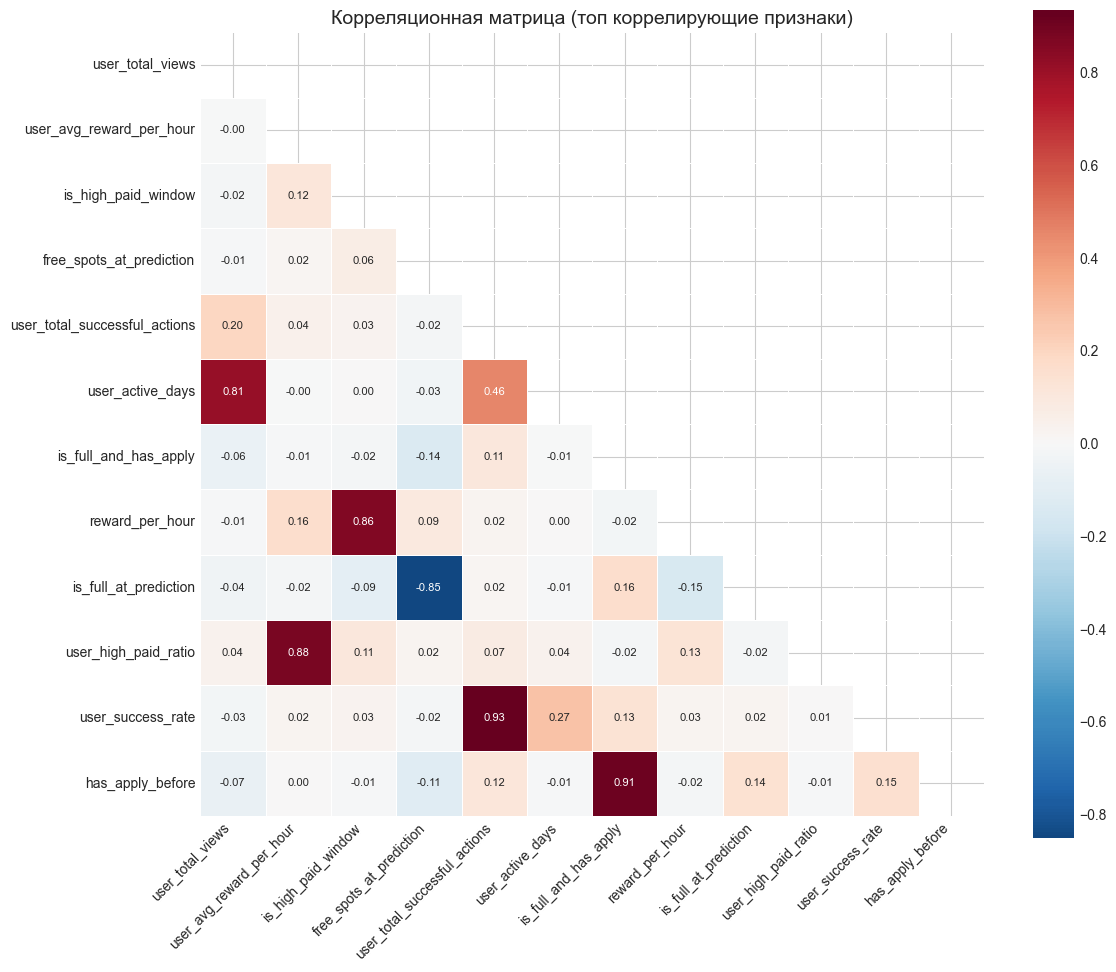


6. Анализ корреляции с целевой переменной

ТОП-15 признаков по корреляции с целевой переменной:
   1. has_apply_before                             : 0.6409
   2. is_full_and_has_apply                        : 0.5849
   3. Успешные действия пользователя 7 дней        : 0.1968
   4. user_success_rate                            : 0.1793
   5. Успешные действия пользователя 14 дней       : 0.1608
   6. user_employer_experience                     : 0.1606
   7. matches_location                             : 0.1531
   8. user_task_type_experience                    : 0.1512
   9. user_location_experience                     : 0.1400
  10. user_total_successful_actions                : 0.1371
  11. user_total_views                             : -0.1085
  12. shift_total_views                            : -0.1061
  13. matches_time_of_day                          : 0.1026
  14. view_count_for_shift                         : -0.0738
  15. is_full_at_prediction                        : 0.0610


In [28]:
print("Проверка мультиколлинеарности признаков")

# Загружаем данные
train_df = pd.read_csv('train_features_final.csv')
train_df['start_at'] = pd.to_datetime(train_df['start_at'])


# 1. Отбор признаков для анализа

print("\n1. Отбор признаков для анализа")

# Исключаем идентификаторы, целевую переменную и категориальные признаки
exclude_cols = ['user_id', 'shift_id', 'target', 'start_at', 'location_id_shift',
    'task_type', 'employer_id', 'location_id_user', 'system_cancel_shifts',
    'shift_time_of_day', 'task_category', 'shift_day_of_week', 'shift_hour']

# Берем только числовые признаки (включая бинарные с -1)
numeric_cols = [col for col in train_df.columns if col not in exclude_cols
                and train_df[col].dtype in ['int64', 'float64']]

# Дополнительно исключаем признаки с доминирующим значением (>99%) и незначимые
high_imbalance_cols = ['is_short_shift']  # 99.71% доминирующее значение

feature_cols = [col for col in numeric_cols if col not in high_imbalance_cols]

print(f"Всего числовых признаков: {len(numeric_cols)}")
print(f"Исключено из-за дисбаланса: {len(high_imbalance_cols)}")
print(f"Признаков для анализа мультиколлинеарности: {len(feature_cols)}")

# 2. Расчет корреляционной матрицы

print("\n2. Расчет корреляционной матрицы")

# Заменяем -1 на NaN для корреляции (игнорируем заглушки)
df_corr = train_df[feature_cols].copy()
for col in df_corr.columns:
    df_corr[col] = df_corr[col].replace(-1, np.nan)

# Расчет корреляционной матрицы
corr_matrix = df_corr.corr(method='spearman')

print(f"Размер матрицы: {corr_matrix.shape}")


# 3. Поиск высококоррелированных пар

print("\n3. Поиск высококоррелированных пар (|corr| > 0.8)")

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.8 and not np.isnan(corr_val):
            high_corr_pairs.append({
                'Признак 1': corr_matrix.columns[i],
                'Признак 2': corr_matrix.columns[j],
                'Корреляция': corr_val
            })

high_corr_df = pd.DataFrame(high_corr_pairs)
high_corr_df = high_corr_df.sort_values('Корреляция', ascending=False)

print(f"Найдено пар с корреляцией > 0.8: {len(high_corr_df)}")

if len(high_corr_df) > 0:
    print("\nТОП-20 высококоррелированных пар:")
    for i, row in high_corr_df.head(20).iterrows():
        print(f"  {row['Признак 1']} ↔ {row['Признак 2']}: {row['Корреляция']:.4f}")


# 4. Анализ мультиколлинеарности (VIF)

print("\n4. Анализ мультиколлинеарности (VIF)")
print("VIF > 10 указывает на высокую мультиколлинеарность")

# Удаляем строки с NaN для расчета VIF
df_vif = df_corr.dropna()

# Рассчитываем VIF для каждого признака
vif_data = []
for i, col in enumerate(df_vif.columns):
    try:
        vif = variance_inflation_factor(df_vif.values, i)
        vif_data.append({'Признак': col, 'VIF': vif})
    except:
        vif_data.append({'Признак': col, 'VIF': np.nan})

vif_df = pd.DataFrame(vif_data)
vif_df = vif_df.sort_values('VIF', ascending=False)

print(f"\nТОП-15 Признаков с наибольшим VIF:")
for i, row in vif_df.head(15).iterrows():
    if not np.isnan(row['VIF']):
        if row['VIF'] > 50:
            status = " КРИТИЧЕСКАЯ"
        elif row['VIF'] > 10:
            status = " ВЫСОКАЯ"
        else:
            status = " НОРМА"
        print(f"  {row['Признак']:40s}: VIF={row['VIF']:.2f} {status}")


# 5. Визуализация корреляционной матрицы

print("\n5. Визуализация корреляционной матрицы")

# Выбираем топ-20 самых коррелирующих признаков
if len(high_corr_df) > 0:
    top_corr_features = set()
    for _, row in high_corr_df.head(10).iterrows():
        top_corr_features.add(row['Признак 1'])
        top_corr_features.add(row['Признак 2'])

    top_corr_features = list(top_corr_features)
    print(f"Топ признаков для визуализации: {len(top_corr_features)}")

    # Подматрица
    sub_corr = corr_matrix.loc[top_corr_features, top_corr_features]

    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(sub_corr, dtype=bool))
    sns.heatmap(sub_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, square=True, linewidths=0.5, annot_kws={'size': 8})
    plt.title('Корреляционная матрица (топ коррелирующие признаки)', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# 6. Анализ корреляции с целевой переменной

print("\n6. Анализ корреляции с целевой переменной")

# Рассчитываем корреляцию каждого признака с target (без замены -1)
target_corr = []
for col in feature_cols:
    if col in train_df.columns:
        # Заменяем -1 на NaN
        clean_series = train_df[col].replace(-1, np.nan)
        mask = ~clean_series.isna()
        if mask.sum() > 1:
            corr = spearmanr(clean_series[mask], train_df.loc[mask, 'target'])[0]
            if not np.isnan(corr):
                target_corr.append((col, corr))

target_corr.sort(key=lambda x: -abs(x[1]))

print("\nТОП-15 признаков по корреляции с целевой переменной:")
for i, (col, corr) in enumerate(target_corr[:15], 1):
    print(f"  {i:2}. {col:45s}: {corr:.4f}")


# 7. Группа высококоррелированных признаков

print("\n7. Группа высококоррелированных признаков")

if len(high_corr_df) > 0:
    # Создаем группы признаков с высокой корреляцией
    visited = set()
    clusters = []

    for _, row in high_corr_df.iterrows():
        f1, f2 = row['Признак 1'], row['Признак 2']
        if f1 not in visited and f2 not in visited:
            # Ищем все признаки, коррелирующие с этими
            cluster = {f1, f2}
            changed = True
            while changed:
                changed = False
                for _, r in high_corr_df.iterrows():
                    if r['Признак 1'] in cluster and r['Признак 2'] not in cluster:
                        cluster.add(r['Признак 2'])
                        changed = True
                    elif r['Признак 2'] in cluster and r['Признак 1'] not in cluster:
                        cluster.add(r['Признак 1'])
                        changed = True
            for f in cluster:
                visited.add(f)
            if len(cluster) > 1:
                clusters.append(cluster)

    print(f"\nНайдено групп высококоррелированных признаков: {len(clusters)}")
    for i, cluster in enumerate(clusters, 1):
        print(f"\n  Группа {i} ({len(cluster)} признаков):")
        for f in sorted(cluster):
            # Находим максимальную корреляцию с target в группе
            corr_val = next((c for col, c in target_corr if col == f), 0)
            print(f"    - {f:40s} (corr с target: {corr_val:.4f})")
else:
    print("  Нет высококоррелированных групп")


# 8. Выводы мультиколлинеарности

print("\nВыводы мультиколлинеарности")

# Анализ высококоррелированных пар
print("\n1. Высококоллинеарные пары (>0.8):")
if len(high_corr_df) > 0:
    print(f"    Найдено {len(high_corr_df)} пар")

    # Группируем по типу связей
    print("\n    Типы связей:")

    # Связи между признаками занятости и записи
    occupancy_pairs = high_corr_df[
        (high_corr_df['Признак 1'].str.contains('shift|overlap|user_shifts|apply_before|has_apply')) |
        (high_corr_df['Признак 2'].str.contains('shift|overlap|user_shifts|apply_before|has_apply'))
    ]
    if len(occupancy_pairs) > 0:
        print(f"    - Признаки занятости/записи: {len(occupancy_pairs)} пар")

    # Связи между историческими признаками пользователя
    history_pairs = high_corr_df[
        (high_corr_df['Признак 1'].str.contains('user_total|user_success|user_active|user_avg')) |
        (high_corr_df['Признак 2'].str.contains('user_total|user_success|user_active|user_avg'))
    ]
    if len(history_pairs) > 0:
        print(f"     - Исторические признаки пользователя: {len(history_pairs)} пар")

    # Связи между employer признаками
    employer_pairs = high_corr_df[
        (high_corr_df['Признак 1'].str.contains('employer')) |
        (high_corr_df['Признак 2'].str.contains('employer'))
    ]
    if len(employer_pairs) > 0:
        print(f"     - Признаки заказчика: {len(employer_pairs)} пар")

    # Связи между совпадениями предпочтений
    matches_pairs = high_corr_df[
        (high_corr_df['Признак 1'].str.contains('matches')) |
        (high_corr_df['Признак 2'].str.contains('matches'))
    ]
    if len(matches_pairs) > 0:
        print(f"     - Признаки совпадений (matches_*): {len(matches_pairs)} пар")
else:
    print("    Нет пар с корреляцией > 0.8")

# Анализ VIF
print("\n2. VIF анализ:")
high_vif = vif_df[vif_df['VIF'] > 10]
if len(high_vif) > 0:
    print(f"    Признаков с VIF > 10: {len(high_vif)}")
    print("   Рекомендация: рассмотреть возможность удаления или объединения")
else:
    print("    Нет признаков с критической мультиколлинеарностью (VIF > 10)")


# 9. Итоговая рекомендация


print("\nИтоговая рекомендация")

if len(high_corr_df) > 15:
    print("\n Обнаружена значительная мультиколлинеарность")
    print("   Рекомендации:")
    print("   1. Для линейных моделей (логистическая регрессия) - удалить сильно коррелирующие признаки")
    print("   2. Для градиентного бустинга (LightGBM) - можно оставить, алгоритм устойчив")
    print("   3. Из каждой группы высококоррелированных признаков оставить один с максимальной корреляцией с целевой переменной")
elif len(high_corr_df) > 0:
    print("\n Обнаружена умеренная мультиколлинеарность")
    print("   Рекомендации:")
    print("   1. Для линейных моделей - рекомендуется редукция")
    print("   2. Для градиентного бустинга - можно оставить как есть")
    print("   3. Обратить внимание на группы признаков с корреляцией > 0.8")
else:
    print("\n Мультиколлинеарность не обнаружена")
    print("   Все признаки можно использовать в модели")

## Выводы по анализу мультиколлинеарности (числовые признаки)

---

### 1. Общая оценка

| Показатель | Значение |
|------------|----------|
| Всего числовых признаков | 46 |
| Признаков для анализа | 45 |
| Пар с корреляцией > 0.8 | 6 |
| Признаков с VIF > 10 (критическая мультиколлинеарность) | 14 |

**Обнаружена высокая мультиколлинеарность** - 14 признаков имеют VIF > 10, что требует редукции для линейных моделей.

---

### 2. Группы высококоррелированных признаков

| Группа | Признак 1 | Признак 2 | Корреляция | Рекомендация |
|--------|-----------|-----------|------------|--------------|
| 1 | `user_total_successful_actions` | `user_success_rate` | 0.9340 | Оставить `user_success_rate` (выше corr с target: 0.1793 vs 0.1371) |
| 2 | `has_apply_before` | `is_full_and_has_apply` | 0.9127 | Оставить `has_apply_before` (выше corr с target: 0.6409 vs 0.5849) |
| 3 | `user_high_paid_ratio` | `user_avg_reward_per_hour` | 0.8786 | Оставить `user_avg_reward_per_hour` (выше corr с target: 0.0192 vs 0.0097) |
| 4 | `reward_per_hour` | `is_high_paid_window` | 0.8584 | Оставить `reward_per_hour` (исходный признак) |
| 5 | `user_total_views` | `user_active_days` | 0.8095 | Оставить `user_total_views` (выше corr с target по модулю: -0.1085 vs -0.0267) |
| 6 | `free_spots_at_prediction` | `is_full_at_prediction` | -0.8505 | **Оба признака полезны** (разнонаправленная связь: первый отрицательная, второй положительная) |

---

### 3. Проблемные признаки с критическим VIF (>50)

| Признак | VIF | Проблема | Рекомендация для линейных моделей |
|---------|-----|----------|----------------------------------|
| `median_pay_window` | 6267 | Линейно выражается через другие признаки оплаты |  Удалить |
| `employer_reliability` | 6038 | Выражается через `employer_total_shifts` и `system_cancels` |  Удалить (оставить `employer_avg_reward`) |
| `hours` | 150 | Связан с `is_long_shift`, `is_short_shift` |  Оставить `is_long_shift` как бинарный |
| `reward_per_hour` | 96 | Связан с `reward`, `is_high_paid_window` |  Оставить (информативен) |
| `reward` | 87 | Связан с `reward_per_hour` и `hours` |  Удалить (оставить `reward_per_hour`) |
| `mk_match_2` | 67 | Линейно выражается через `need_mk` и `has_mk` |  Оставить (3 состояния дают больше информации) |
| `mk_match` | 52 | Бинарная версия `mk_match_2` |  Удалить (оставить `mk_match_2`) |

---

### 4. Рекомендации по отбору признаков

#### Для линейных моделей (логистическая регрессия)

**Обязательно удалить (высокая мультиколлинеарность):**

| Признак | Причина |
|---------|---------|
| `median_pay_window` | VIF = 6267 |
| `employer_reliability` | VIF = 6038 |
| `reward` | VIF = 87, дублирует `reward_per_hour` |
| `mk_match` | VIF = 52, дублирует `mk_match_2` |
| `user_active_days` | VIF = 24, дублирует `user_total_views` |
| `user_total_successful_actions` | VIF = 13, дублирует `user_success_rate` |
| `user_high_paid_ratio` | VIF = 23, дублирует `user_avg_reward_per_hour` |
| `is_full_and_has_apply` | VIF = 12, дублирует `has_apply_before` |
| `is_high_paid_window` | Корреляция 0.86 с `reward_per_hour` |
| `free_spots_at_prediction` | Оставить `is_full_at_prediction` |

# Обучение моделей и сравнение. Первое приближение для предварительной оценки

In [2]:
# 1. Загрузка данных
train_df = pd.read_csv('train_features_final.csv')
test_df = pd.read_csv('test_features_final.csv')

# 2. Отбор признаков на основе анализа
# Исключаем ID, таргет, даты и признаки с критическим дисбалансом/коллинеарностью
features_to_drop = ['user_id', 'shift_id', 'target', 'start_at', 'location_id_shift', 'employer_id', 'location_id_user', 'task_type', 'date', 'task_category',
    'shift_time_of_day', 'is_short_shift', 'is_weekday', 'shift_day_of_week']

# Для деревянных моделей мультиколлинеарность менее критична, но удалим самые явные дубли
# чтобы модель была компактнее
duplicate_features = [
    'user_total_successful_actions',                    # заменяем на success_rate
    'reward',                                           # заменяем на reward_per_hour
    'mk_match',                                         # заменяем на mk_match_2
    'user_active_days'                                  # заменяем на total_views
]

final_drop = features_to_drop + duplicate_features
X_train = train_df.drop(columns=[col for col in final_drop if col in train_df.columns])
y_train = train_df['target']

X_test = test_df.drop(columns=[col for col in final_drop if col in test_df.columns])
y_test = test_df['target']

print(f"Используется признаков: {X_train.shape[1]}")

# 3. Определение моделей
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced'),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# 4. Цикл обучения и оценки
for name, model in models.items():
    print(f"\n\n    Модель {name}")
    start_time = time.time()

    # Обучение
    model.fit(X_train, y_train)

    # Предсказание
    train_pred = model.predict(X_train)
    train_proba = model.predict_proba(X_train)[:, 1]

    test_pred = model.predict(X_test)
    test_proba = model.predict_proba(X_test)[:, 1]

    duration = time.time() - start_time

    # Вывод метрик
    print(f"Время обучения: {duration:.2f} сек")
    print("\nМетрики на train:")
    print(classification_report(y_train, train_pred))
    print(f"ROC-AUC Train: {roc_auc_score(y_train, train_proba):.4f}")

    print("\nМетрики на Test:")
    print(classification_report(y_test, test_pred))
    print(f"ROC-AUC Test: {roc_auc_score(y_test, test_proba):.4f}")

    # Важность признаков (Топ-5)
    if hasattr(model, 'feature_importances_'):
        importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
        print("\nТОП-5 важных признаков:")
        print(importances.head(5))

Используется признаков: 44


    Модель Decision Tree
Время обучения: 1.09 сек

Метрики на train:
              precision    recall  f1-score   support

           0       1.00      0.88      0.94    221025
           1       0.15      0.93      0.26      4946

    accuracy                           0.88    225971
   macro avg       0.57      0.91      0.60    225971
weighted avg       0.98      0.88      0.92    225971

ROC-AUC Train: 0.9704

Метрики на Test:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94    217008
           1       0.12      0.81      0.21      4108

    accuracy                           0.89    221116
   macro avg       0.56      0.85      0.57    221116
weighted avg       0.98      0.89      0.92    221116

ROC-AUC Test: 0.8936

ТОП-5 важных признаков:
user_success_rate       0.415122
view_count_for_shift    0.208864
has_apply_before        0.188797
user_total_views        0.032896
reward_per_hour         0.0321

C:\Users\arnt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [12:27:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Время обучения: 0.91 сек

Метрики на train:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    221025
           1       0.98      0.46      0.63      4946

    accuracy                           0.99    225971
   macro avg       0.98      0.73      0.81    225971
weighted avg       0.99      0.99      0.99    225971

ROC-AUC Train: 0.9740

Метрики на Test:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    217008
           1       0.94      0.41      0.57      4108

    accuracy                           0.99    221116
   macro avg       0.97      0.70      0.78    221116
weighted avg       0.99      0.99      0.99    221116

ROC-AUC Test: 0.9536

ТОП-5 важных признаков:
has_apply_before             0.631774
view_count_for_shift         0.116414
user_success_rate            0.074782
user_employer_experience     0.014323
user_task_type_experience    0.011758
dtype: float32


### **Сравнение базовых моделей**

| Модель | Test ROC-AUC | Test Recall | Test Precision | Особенности |
| :--- | :---: | :---: | :---: | :--- |
| **Decision Tree** | 0.8936 | **0.81** | 0.12 | Склонна к переобучению, высокий Recall за счет балансировки весов. |
| **Random Forest** | 0.9469 | 0.76 | 0.18 | Стабильный ансамбль, хороший баланс между метриками. |
| **XGBoost** | **0.9536** | 0.41 | **0.94** | Максимальная точность (минимум ложных тревог), но пропускает часть целевых событий. |

**Краткий вывод:**
- Если нам критично **найти как можно больше потенциальных записей** (Recall), лучше использовать сбалансированное Дерево или Случайный лес.
- Если нам нужно **безошибочно определять запись** (Precision), XGBoost - абсолютный лидер.

In [30]:
# !pip install catboost

In [3]:
strict_drop = ['user_id', 'shift_id', 'target', 'start_at', 'location_id_shift', 'employer_id', 'location_id_user', 'task_type', 'date', 'task_category',
    'shift_time_of_day', 'is_short_shift', 'is_weekday', 'shift_day_of_week']

# Набор 2: Расширенный (Extended)
extended_drop = ['user_id', 'shift_id', 'target', 'start_at', 'employer_id', 'location_id_user', 'date']

# 1. Определение наборов признаков
# Набор 1: Жестко ограниченный (Strict)
strict_drop = ['user_id', 'shift_id', 'target', 'start_at', 'location_id_shift', 'employer_id', 'location_id_user', 'task_type', 'date', 'task_category',
    'shift_time_of_day', 'is_short_shift', 'is_weekday', 'shift_day_of_week']

# Набор 2: Расширенный (Extended)
extended_drop = ['user_id', 'shift_id', 'target', 'start_at', 'employer_id', 'location_id_user', 'date']

def get_datasets(train, test, drop_cols):
    # Удаляем дубликаты, выявленные анализом VIF, если они есть в списке
    vif_duplicates = ['user_total_successful_actions', 'reward', 'mk_match', 'user_active_days']
    final_drop = drop_cols + [c for c in vif_duplicates if c not in drop_cols]

    x_train = train.drop(columns=[c for c in final_drop if c in train.columns])
    x_test = test.drop(columns=[c for c in final_drop if c in test.columns])
    return x_train, x_test

def run_benchmark(models_dict, train_data, test_data, feature_sets):
    results = []
    for set_name, drop_list in feature_sets.items():
        X_tr, X_te = get_datasets(train_data, test_data, drop_list)
        y_tr, y_te = train_data['target'], test_data['target']

        for model_name, model in models_dict.items():
            start = time.time()
            # Обработка категорий для бустингов
            X_tr_proc = X_tr.copy()
            X_te_proc = X_te.copy()
            cat_cols = X_tr_proc.select_dtypes(include=['object']).columns.tolist()

            if "LogReg" in model_name:
                model.fit(X_tr_proc, y_tr)
            elif "CatBoost" in model_name:
                model.fit(X_tr_proc, y_tr, cat_features=cat_cols, verbose=False)
            else:
                for col in cat_cols:
                    X_tr_proc[col] = pd.Categorical(X_tr_proc[col]).codes
                    X_te_proc[col] = pd.Categorical(X_te_proc[col]).codes
                model.fit(X_tr_proc, y_tr)

            probas = model.predict_proba(X_te_proc)[:, 1]
            preds = (probas > 0.5).astype(int)

            results.append({
                "Feature_Set": set_name,
                "Model": model_name,
                "ROC-AUC": roc_auc_score(y_te, probas),
                "Recall": recall_score(y_te, preds),
                "Precision": precision_score(y_te, preds, zero_division=0),
                "Duration": time.time() - start
            })
    return pd.DataFrame(results)

### Группа 1: Деревянные модели (Decision Tree & Random Forest)

In [32]:
!pip install jinja2


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
tree_models = {
    "Decision Tree (Bal)": DecisionTreeClassifier(max_depth=10, random_state=42, class_weight='balanced'),
    "Random Forest (Bal)": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced')
}

feature_sets = {"Strict": strict_drop, "Extended": extended_drop}
tree_results = run_benchmark(tree_models, train_df, test_df, feature_sets)
display(tree_results.style.background_gradient(cmap='viridis', subset=['ROC-AUC', 'Recall']))

,Feature_Set,Model,ROC-AUC,Recall,Precision,Duration
0,Strict,Decision Tree (Bal),0.893599,0.812317,0.119997,1.044983
1,Strict,Random Forest (Bal),0.946912,0.764849,0.177846,2.061858
2,Extended,Decision Tree (Bal),0.893801,0.805501,0.121610,1.291650
3,Extended,Random Forest (Bal),0.946799,0.763875,0.176332,2.343437


### Группа 2: Boosting модели (XGBoost, LightGBM, CatBoost)

In [5]:
boosting_models = {
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=6, random_state=42, eval_metric='logloss'),
    "LightGBM Balanced": lgb.LGBMClassifier(n_estimators=100, is_unbalance=True, random_state=42, n_jobs=-1, verbose=-1),
    "CatBoost Weighted": CatBoostClassifier(iterations=200, auto_class_weights='Balanced', random_seed=42, verbose=False)
}

boost_results = run_benchmark(boosting_models, train_df, test_df, feature_sets)
display(boost_results.style.background_gradient(cmap='plasma', subset=['ROC-AUC', 'Recall']))

,Feature_Set,Model,ROC-AUC,Recall,Precision,Duration
0,Strict,XGBoost,0.950295,0.428189,0.875560,0.644142
1,Strict,LightGBM Balanced,0.952104,0.826193,0.150310,0.935587
2,Strict,CatBoost Weighted,0.932988,0.732473,0.191096,2.566796
3,Extended,XGBoost,0.950665,0.432814,0.842654,0.730369
4,Extended,LightGBM Balanced,0.953199,0.832522,0.152665,1.052800
5,Extended,CatBoost Weighted,0.936990,0.744645,0.199635,11.681828


### Группа 3: Линейные модели (Logistic Regression)

In [6]:
def get_lr_pipeline(X):
    num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
    cat_cols = X.select_dtypes(include=['object']).columns.tolist()
    return Pipeline([
        ('pre', ColumnTransformer([
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
        ])),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ])

# Manual loop for LR as it needs different pipelines per feature set
lr_results = []
for set_name, drop_list in feature_sets.items():
    X_tr, X_te = get_datasets(train_df, test_df, drop_list)
    pipe = get_lr_pipeline(X_tr)
    start = time.time()
    pipe.fit(X_tr, train_df['target'])
    probas = pipe.predict_proba(X_te)[:, 1]
    preds = (probas > 0.5).astype(int)
    lr_results.append({
        "Feature_Set": set_name, "Model": "LogReg (Bal)",
        "ROC-AUC": roc_auc_score(test_df['target'], probas),
        "Recall": recall_score(test_df['target'], preds),
        "Precision": precision_score(test_df['target'], preds, zero_division=0),
        "Duration": time.time() - start
    })

lr_results_df = pd.DataFrame(lr_results)
display(lr_results_df.style.background_gradient(cmap='magma'))

,Feature_Set,Model,ROC-AUC,Recall,Precision,Duration
0,Strict,LogReg (Bal),0.943509,0.927702,0.077880,1.501292
1,Extended,LogReg (Bal),0.944633,0.872931,0.105922,2.854333


### Финальная оценка всех алгоритмов и наборов параметров

In [7]:
full_summary = pd.concat([tree_results, boost_results, lr_results_df], ignore_index=True)
final_comparison = full_summary.sort_values(["Feature_Set", "ROC-AUC"], ascending=[True, False])

print("Финальная сводная таблица сравнения")
display(final_comparison.pivot_table(
    index="Model",
    columns="Feature_Set",
    values=["ROC-AUC", "Recall", "Precision"]
).style.highlight_max(axis=0, color='lightgreen'))

Финальная сводная таблица сравнения


### Анализ важности признаков

Определили наиболее эффективные модели, теперь поссмотрим, какие признаки вносят наибольший вклад. Будем использовать модель **LightGBM Balanced** на наборе функций **Extended**, чтобы определить ключевые факторы вовлеченности пользователей.

C:\Users\arnt\AppData\Local\Temp\ipykernel_18072\2031989895.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp.head(20), palette='viridis')


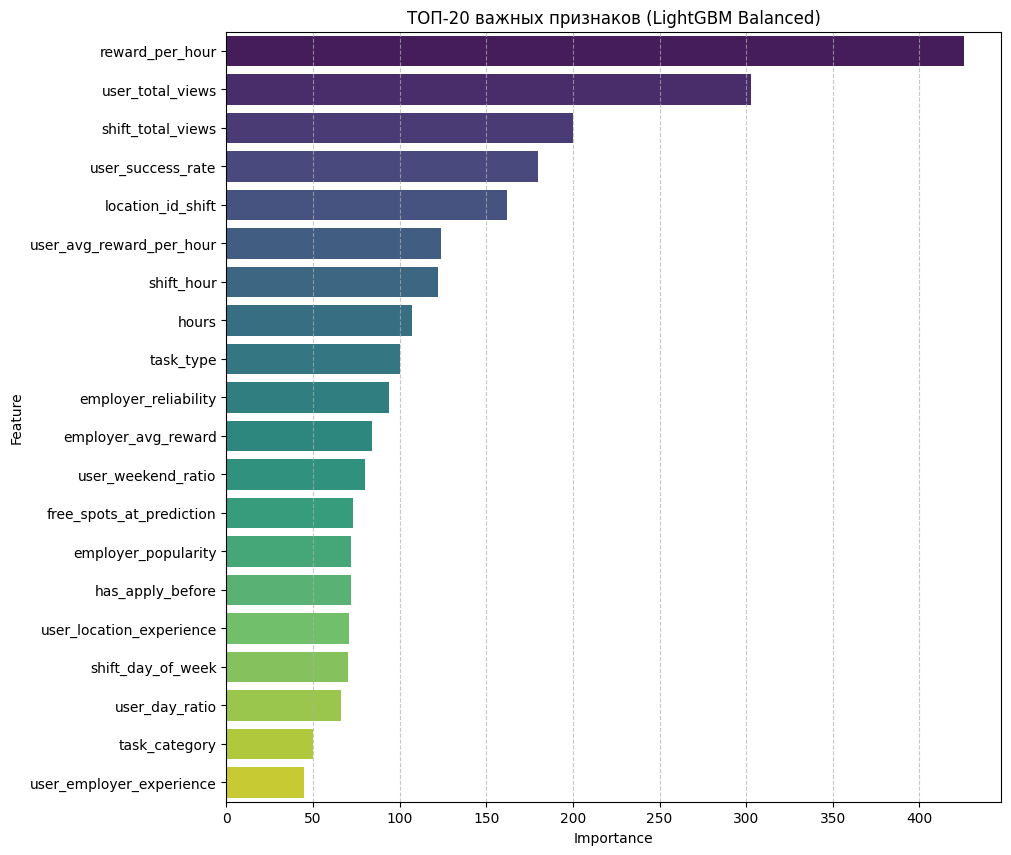

In [8]:
# 1. Подготовка данных (расширенный набор)
X_tr_ext, X_te_ext = get_datasets(train_df, test_df, extended_drop)
y_tr = train_df['target']

# 2. Обучение лучшей (LightGBM)
best_model = lgb.LGBMClassifier(n_estimators=100, is_unbalance=True, random_state=42, n_jobs=-1, verbose=-1)

# Категории процессов LightGBM
X_tr_ext_proc = X_tr_ext.copy()
cat_cols = X_tr_ext_proc.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    X_tr_ext_proc[col] = pd.Categorical(X_tr_ext_proc[col]).codes

best_model.fit(X_tr_ext_proc, y_tr)

# 3. Вывод важности
feat_imp = pd.DataFrame({
    'Feature': X_tr_ext.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(20), palette='viridis')
plt.title('ТОП-20 важных признаков (LightGBM Balanced)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

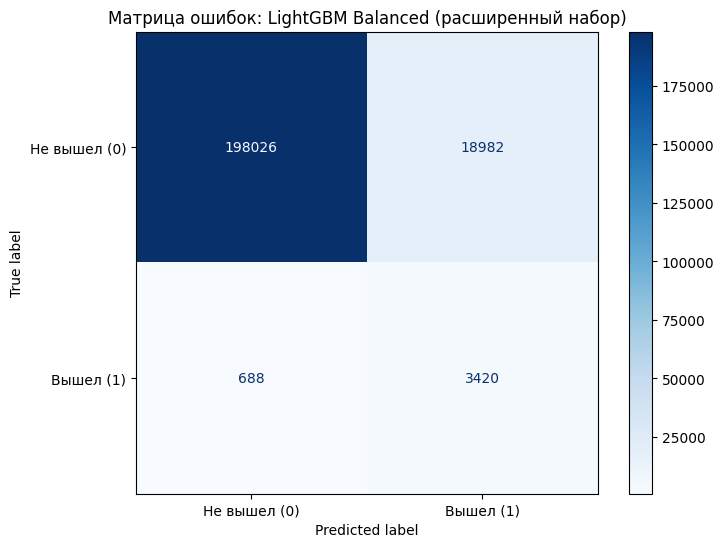

In [9]:
# 1. Получение прогнозов для лучшего результата
# Мы используем обработанный расширенный тестовый набор из предыдущих шагов
# Предполагается, что best_model и X_te_ext доступны из предыдущих ячеек
X_te_ext_proc = X_te_ext.copy()
cat_cols = X_te_ext_proc.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    X_te_ext_proc[col] = pd.Categorical(X_te_ext_proc[col]).codes

y_pred = best_model.predict(X_te_ext_proc)

# 2. Матрица ошибок
cm = confusion_matrix(y_test, y_pred)

# 3. Вывод
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Не вышел (0)', 'Вышел (1)'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Матрица ошибок: LightGBM Balanced (расширенный набор)')
plt.grid(False)
plt.show()

Оптимальный порог: 0.9414
Max F1-Score: 0.5785
Precision на оптимальном пороге: 0.8700
Recall на оптимальном пороге: 0.4333


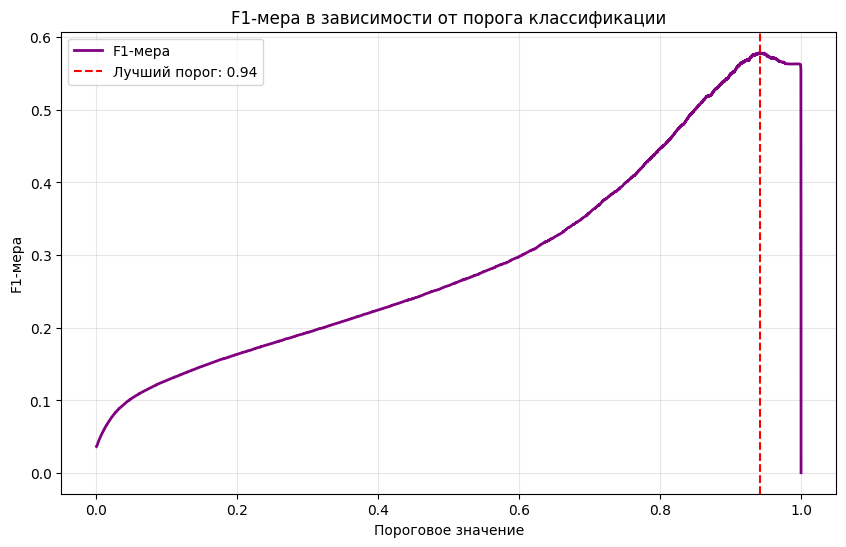

In [10]:
# 1. Вероятностные оценки для тестового набора данных модели с наилучшими показателями
y_scores = best_model.predict_proba(X_te_ext_proc)[:, 1]

# 2. Расчет precision, recall и thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# 3. F1-мера для каждого порогового значения
# Обрабатываем возможное деление через np.divide с условием where
f1_scores = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(precision), where=(precision + recall) != 0)

# 4. Пороговое значение, обеспечивающее максимальное значение F1-меры
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 1.0
best_f1 = f1_scores[best_idx]

print(f'Оптимальный порог: {best_threshold:.4f}')
print(f'Max F1-Score: {best_f1:.4f}')
print(f'Precision на оптимальном пороге: {precision[best_idx]:.4f}')
print(f'Recall на оптимальном пороге: {recall[best_idx]:.4f}')

# 5. F1-мера против порогового значения
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores[:-1], color='purple', lw=2, label='F1-мера')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Лучший порог: {best_threshold:.2f}')
plt.xlabel('Пороговое значение')
plt.ylabel('F1-мера')
plt.title('F1-мера в зависимости от порога классификации')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Результаты оценки порогового значения

Максимизируя F1-меру, мы определяем пороговое значение, которое уравновешивает стоимость пропуска работника (ложноотрицательный результат) со стоимостью отправки ложного уведомления (ложноположительный результат).

Далее мы можем применить это оптимальное пороговое значение для создания итогового отчета о классификации и матрицы ошибок, чтобы увидеть реальное влияние на наши показатели точности.

Финальный отчет по классификации (порог = 0.9414):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    217008
           1       0.87      0.43      0.58      4108

    accuracy                           0.99    221116
   macro avg       0.93      0.72      0.79    221116
weighted avg       0.99      0.99      0.99    221116



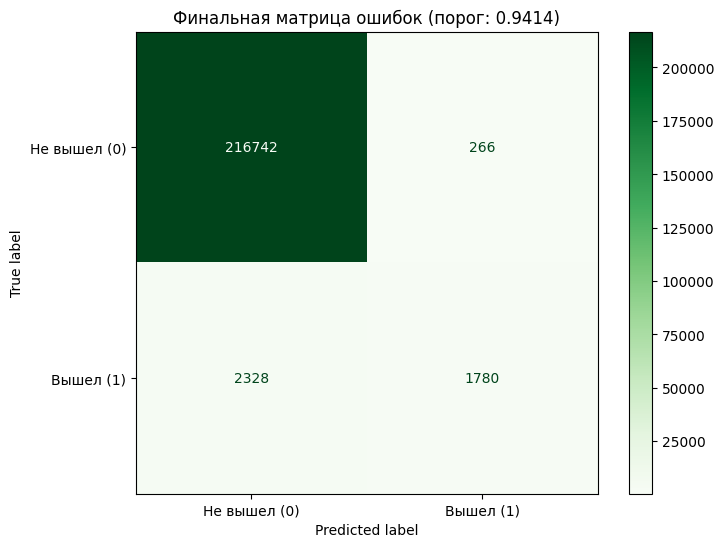

Финальная точность (precision): 0.8700
Финальная полнота (recall): 0.4333


In [11]:
# 1. Применяем оптимальный порог к вероятностям
# используем y_scores (вероятности) от лучшей модели LightGBM
final_threshold = 0.9414
y_pred_optimal = (y_scores >= final_threshold).astype(int)

# 2. Генерируем и выводим отчет по классификации
print("Финальный отчет по классификации (порог = 0.9414):")
print(classification_report(y_test, y_pred_optimal))

# 3. Считаем и строим финальную матрицу ошибок
final_cm = confusion_matrix(y_test, y_pred_optimal)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=final_cm, display_labels=['Не вышел (0)', 'Вышел (1)'])
disp.plot(cmap='Greens', ax=ax, values_format='d')
plt.title(f'Финальная матрица ошибок (порог: {final_threshold})')
plt.grid(False)
plt.show()

# Считаем точность и полноту для документации
tn, fp, fn, tp = final_cm.ravel()
precision_final = tp / (tp + fp)
recall_final = tp / (tp + fn)

print(f"Финальная точность (precision): {precision_final:.4f}")
print(f"Финальная полнота (recall): {recall_final:.4f}")

### Анализ влияния признаков через SHAP

Стандартная важность признаков показывает какие признаки модель использовала чаще всего, но не объясняет **как именно** они повлияли на результат. SHAP-значения позволяют это понять. Например, можно выяснить - повышает ли более высокая почасовая оплата вероятность записи на смену, или существует определённый порог после которого её влияние перестаёт расти.

C:\Users\arnt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


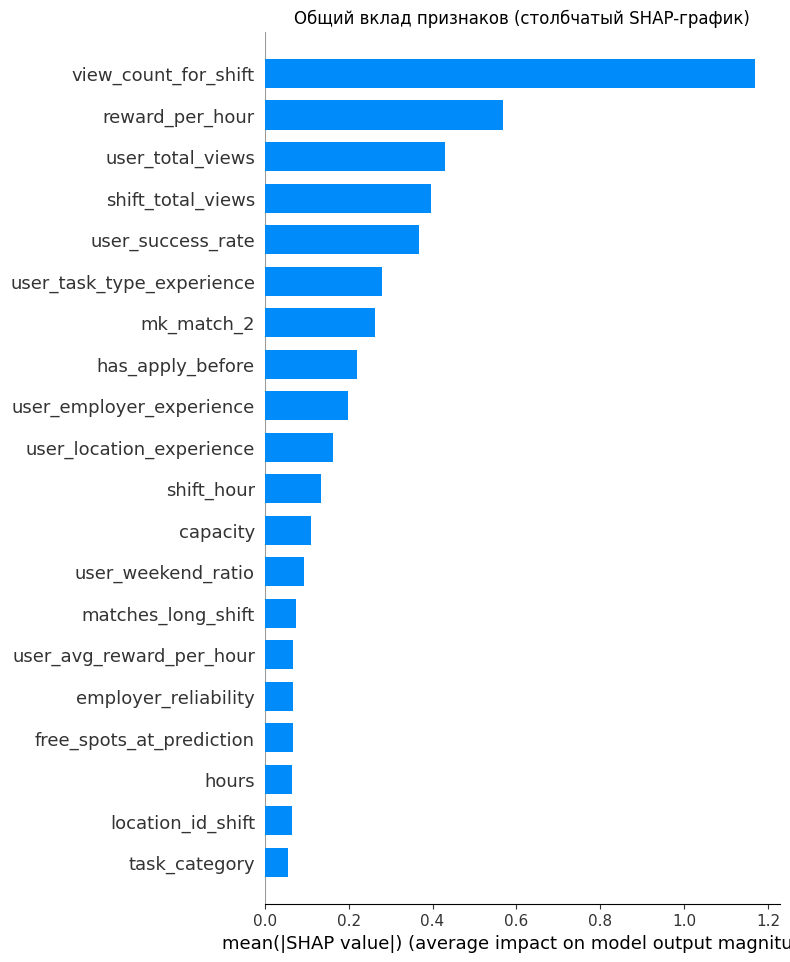

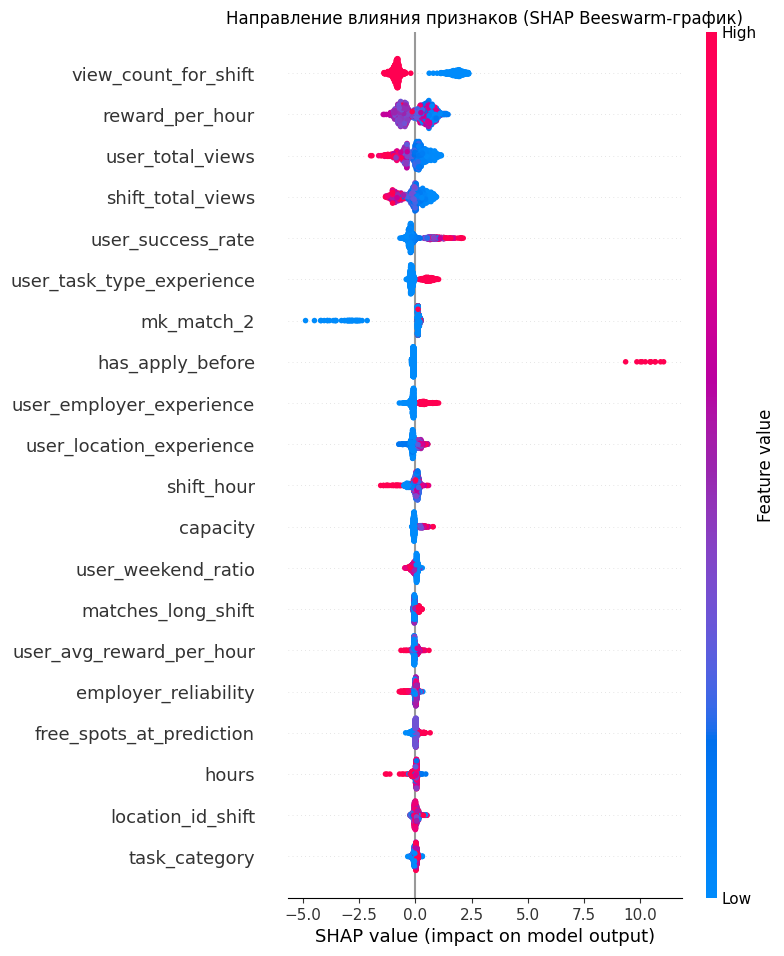

In [12]:
# Инициализируем SHAP-объяснитель
# используем подвыборку данных для ускорения расчёта
explainer = shap.TreeExplainer(best_model)
sample_data = X_te_ext_proc.sample(1000, random_state=42)
shap_values = explainer.shap_values(sample_data)

# Столбчатый график общего вклада признаков
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, sample_data, plot_type="bar", show=False)
plt.title('Общий вклад признаков (столбчатый SHAP-график)')
plt.show()

# Точечный график направления влияния признаков (beeswarm)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, sample_data, show=False)
plt.title('Направление влияния признаков (SHAP Beeswarm-график)')
plt.show()

### Анализ важности признаков

Теперь, когда лучшие модели определены, посмотрим какие признаки вносят наибольший вклад в предсказания. Используем модель **LightGBM Balanced** на **расширенном** наборе признаков чтобы выявить ключевые факторы влияющие на запись пользователей на смену.

In [42]:
!pip install optuna


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Подбор гиперпараметров с помощью Optuna

Остановимся на оптимизации модели **LightGBM Balanced** как наиболее эффективной по результатам сравнения. 

Будем искать оптимальные значения для параметров `learning_rate`, `num_leaves`, `feature_fraction` и `bagging_fraction`.

In [13]:
# Подготовка данных для Optuna (расширенный набор признаков)
X_tr_opt, X_te_opt = get_datasets(train_df, test_df, extended_drop)
y_tr, y_te = train_df['target'], test_df['target']

# Кодируем категориальные признаки
cat_cols = X_tr_opt.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    X_tr_opt[col] = pd.Categorical(X_tr_opt[col]).codes
    X_te_opt[col] = pd.Categorical(X_te_opt[col]).codes

def objective(trial):
    param = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'is_unbalance': True,                                                       # учитываем дисбаланс классов
        'random_state': 42,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 3000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
    }

    gbm = lgb.LGBMClassifier(**param)
    gbm.fit(X_tr_opt, y_tr)
    preds = gbm.predict_proba(X_te_opt)[:, 1]                                       # вероятности для положительного класса
    auc = roc_auc_score(y_te, preds)
    return auc

study = optuna.create_study(direction='maximize')                                   # максимизируем ROC-AUC
study.optimize(objective, n_trials=400)                                             # запускаем 400 испытаний

print('Количество завершённых испытаний:', len(study.trials))
print('Лучшие параметры:', study.best_trial.params)

[I 2026-05-17 12:28:36,361] A new study created in memory with name: no-name-484915b0-88dd-491e-9306-0c77ec362302
[I 2026-05-17 12:28:38,737] Trial 0 finished with value: 0.8790682923952351 and parameters: {'learning_rate': 0.2942903275677442, 'num_leaves': 51, 'max_depth': 6, 'feature_fraction': 0.482880290599189, 'bagging_fraction': 0.4281292226688656, 'bagging_freq': 2, 'min_child_samples': 18}. Best is trial 0 with value: 0.8790682923952351.
[I 2026-05-17 12:28:39,781] Trial 1 finished with value: 0.9538622293374903 and parameters: {'learning_rate': 0.06082668101062179, 'num_leaves': 1058, 'max_depth': 5, 'feature_fraction': 0.8980248847170574, 'bagging_fraction': 0.6782376788428621, 'bagging_freq': 3, 'min_child_samples': 94}. Best is trial 1 with value: 0.9538622293374903.
[I 2026-05-17 12:28:41,997] Trial 2 finished with value: 0.8598024843636043 and parameters: {'learning_rate': 0.2775577314102618, 'num_leaves': 1308, 'max_depth': 8, 'feature_fraction': 0.5308692287450804, 'bag

Количество завершённых испытаний: 400
Лучшие параметры: {'learning_rate': 0.08845033704079258, 'num_leaves': 1429, 'max_depth': 5, 'feature_fraction': 0.5922073403079874, 'bagging_fraction': 0.9974537328168589, 'bagging_freq': 1, 'min_child_samples': 93}


### Оценка оптимизированной модели

Переобучаем модель с лучшими параметрами найденными Optuna и сравниваем её результаты с базовой моделью.

пропустить ячейку ниже если запускали оптуну!

In [14]:
X_tr_opt, X_te_opt = get_datasets(train_df, test_df, extended_drop)
y_tr, y_te = train_df['target'], test_df['target']

# Кодируем категориальные признаки
cat_cols = X_tr_opt.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    X_tr_opt[col] = pd.Categorical(X_tr_opt[col]).codes                           # кодируем train
    X_te_opt[col] = pd.Categorical(X_te_opt[col]).codes                           # кодируем test

# Лучшие параметры найденные Optuna
best_params = {'learning_rate': 0.08306314256806901, 'num_leaves': 2037, 'max_depth': 6, 'feature_fraction': 0.7118453851902156, 'bagging_fraction': 0.8125337048543306, 'bagging_freq': 5, 'min_child_samples': 66}

In [15]:
# best_params = study.best_trial.params  # раскомментировать если запускали Optuna
best_params['objective'] = 'binary'
best_params['metric'] = 'auc'
best_params['is_unbalance'] = True                                                  # учитываем дисбаланс классов
best_params['random_state'] = 42
best_params['verbosity'] = -1                                                       # отключаем лишние логи

final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(X_tr_opt, y_tr)

# Финальная оценка модели
final_probas = final_model.predict_proba(X_te_opt)[:, 1]                            # вероятности для положительного класса
final_auc = roc_auc_score(y_te, final_probas)

print(f'ROC-AUC оптимизированной модели: {final_auc:.4f}')

# Сравниваем с базовой моделью (LightGBM Extended из сравнения моделей ~0.9532)
baseline_auc = 0.9532
print(f'Улучшение: {final_auc - baseline_auc:.4f}')

ROC-AUC оптимизированной модели: 0.9556
Улучшение: 0.0024


In [16]:
X_tr_opt.columns

Index(['location_id_shift', 'task_type', 'need_mk', 'hours', 'capacity',
       'reward_per_hour', 'is_strict_location', 'has_mk', 'median_pay_window',
       'is_high_paid_window', 'is_long_shift', 'is_short_shift', 'mk_match_2',
       'location_match', 'shift_day_of_week', 'shift_hour',
       'shift_time_of_day', 'is_weekday', 'task_category', 'user_total_views',
       'user_success_rate', 'user_unique_employers', 'user_unique_task_types',
       'user_location_experience', 'user_high_paid_ratio',
       'user_long_shift_ratio', 'user_short_shift_ratio',
       'user_avg_reward_per_hour', 'user_successful_actions_last_7d',
       'user_successful_actions_last_14d', 'user_task_type_experience',
       'user_employer_experience', 'employer_avg_reward',
       'employer_popularity', 'employer_reliability', 'shift_total_views',
       'free_spots_at_prediction', 'is_full_at_prediction',
       'view_count_for_shift', 'has_apply_before', 'user_weekend_ratio',
       'user_day_ratio', '

### Важность признаков финальной оптимизированной модели

Анализируем важность признаков для лучшей модели чтобы понять какие факторы наиболее сильно влияют на предсказание записи пользователей на смену.

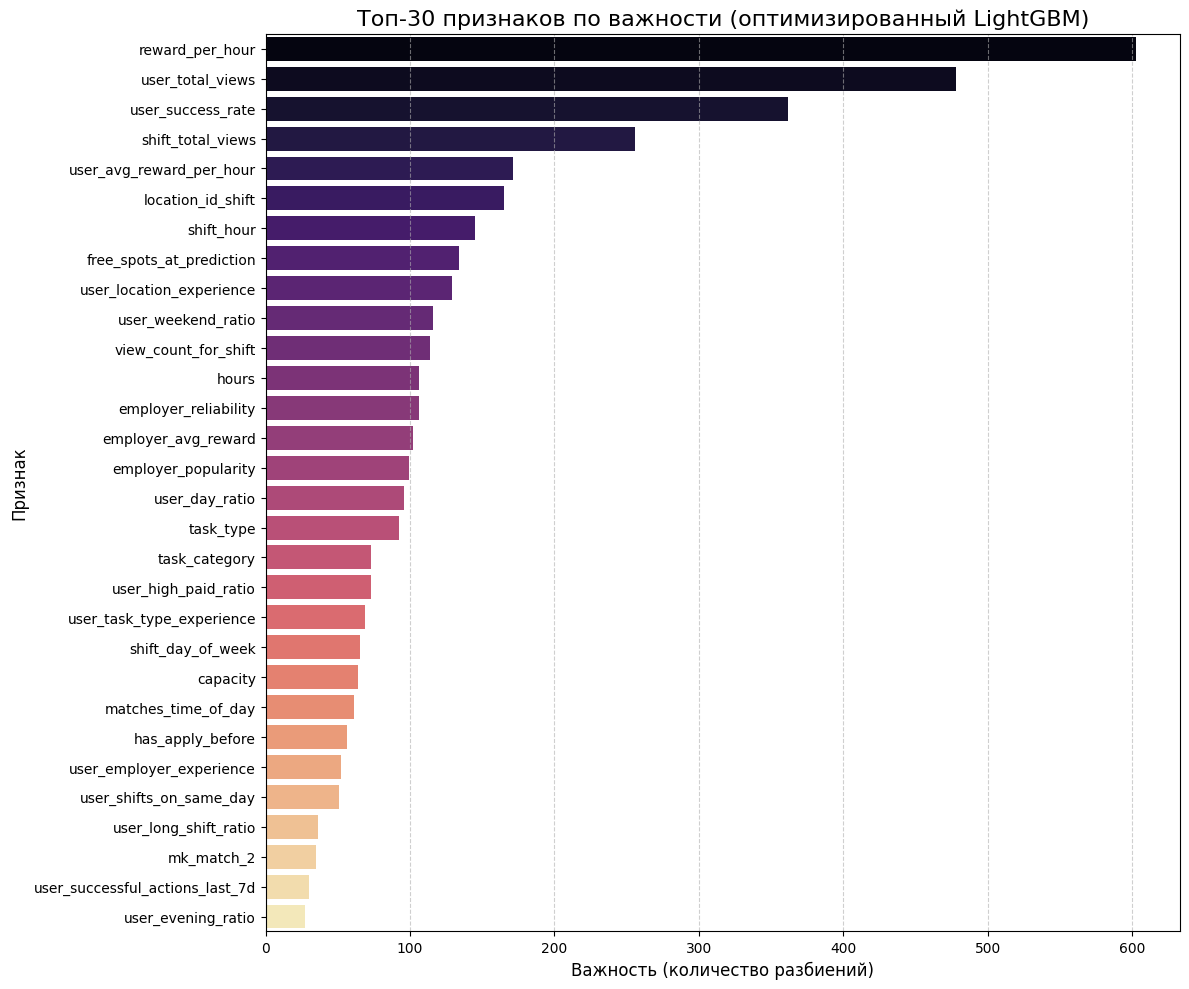

Топ-30 наиболее влиятельных признаков:


,Feature,Importance
5,reward_per_hour,603
19,user_total_views,478
20,user_success_rate,362
35,shift_total_views,256
27,user_avg_reward_per_hour,171
0,location_id_shift,165
15,shift_hour,145
36,free_spots_at_prediction,134
23,user_location_experience,129
40,user_weekend_ratio,116


In [17]:
# 1. Получаем важность признаков от финальной оптимизированной модели
final_feat_imp = pd.DataFrame({
    'Feature': X_tr_opt.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 2. Строим график топ-30 признаков
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=final_feat_imp.head(30), palette='magma', hue='Feature', legend=False)
plt.title('Топ-30 признаков по важности (оптимизированный LightGBM)', fontsize=16)
plt.xlabel('Важность (количество разбиений)', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 3. Выводим числовые значения для топ-30
print("Топ-30 наиболее влиятельных признаков:")
display(final_feat_imp.head(30))

Проверим силу топ 25 переменных в сравнении с полным набором

In [18]:
# 1. Отбираем топ-25 признаков из нашего финального анализа важности
top_25_features = final_feat_imp.head(25)['Feature'].tolist()

print(f"Выбранные топ-25 признаков:\n{top_25_features}")

# 2. Подготовка данных только с этими признаками
X_tr_final = X_tr_opt[top_25_features]
X_te_final = X_te_opt[top_25_features]

# 3. Переобучение финальной модели на сокращенном наборе
final_model_reduced = lgb.LGBMClassifier(**best_params)
final_model_reduced.fit(X_tr_final, y_tr)

# 4. Оценка качества
probas_reduced = final_model_reduced.predict_proba(X_te_final)[:, 1]
auc_reduced = roc_auc_score(y_te, probas_reduced)

print(f'\nROC-AUC на полном наборе (51 признак): {final_auc:.4f}')
print(f'ROC-AUC на топ-25 признаках: {auc_reduced:.4f}')
print(f'Разница: {auc_reduced - final_auc:.4f}')

# Проверяем отчет для порога 0.9414
preds_reduced = (probas_reduced >= 0.9414).astype(int)
print("\nОтчёт по классификации (Top 25 Features):")
print(classification_report(y_te, preds_reduced))

Выбранные топ-25 признаков:
['reward_per_hour', 'user_total_views', 'user_success_rate', 'shift_total_views', 'user_avg_reward_per_hour', 'location_id_shift', 'shift_hour', 'free_spots_at_prediction', 'user_location_experience', 'user_weekend_ratio', 'view_count_for_shift', 'hours', 'employer_reliability', 'employer_avg_reward', 'employer_popularity', 'user_day_ratio', 'task_type', 'task_category', 'user_high_paid_ratio', 'user_task_type_experience', 'shift_day_of_week', 'capacity', 'matches_time_of_day', 'has_apply_before', 'user_employer_experience']

ROC-AUC на полном наборе (51 признак): 0.9556
ROC-AUC на топ-25 признаках: 0.9494
Разница: -0.0062

Отчёт по классификации (Top 25 Features):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    217008
           1       0.84      0.44      0.57      4108

    accuracy                           0.99    221116
   macro avg       0.91      0.72      0.78    221116
weighted avg       0.99   

Падение в избыточно, попробуем оставить 28 фичей

In [19]:
# 1. Выбираем топ-28 признаков из финального анализа важности
top_28_features = final_feat_imp.head(28)['Feature'].tolist()

print(f"Выбранные топ-28 признаков:\n{top_28_features}")

# 2. Подготовка данных с этими признаками
# X_tr_opt и X_te_opt содержат обработанные 51 признак
X_tr_final_28 = X_tr_opt[top_28_features]
X_te_final_28 = X_te_opt[top_28_features]

# 3. Переобучаем финальную модель на сокращённом наборе из 28 признаков
# best_params - оптимальные гиперпараметры из 400 испытаний Optuna
final_model_28 = lgb.LGBMClassifier(**best_params)
final_model_28.fit(X_tr_final_28, y_tr)

# 4. Оценка модели
probas_28 = final_model_28.predict_proba(X_te_final_28)[:, 1] # Вероятности для положительного класса
auc_28 = roc_auc_score(y_te, probas_28)

print(f'\nROC-AUC (все 51 признак): {final_auc:.4f}')
print(f'ROC-AUC (топ-25 признаков): {auc_reduced:.4f}')
print(f'ROC-AUC (топ-28 признаков): {auc_28:.4f}')
print(f'Разница (28 против 51): {auc_28 - final_auc:.4f}')

# Проверяем отчёт для порога высокой точности 0.9414
preds_28 = (probas_28 >= 0.9414).astype(int)
print("\nОтчёт по классификации (топ-28 признаков, порог 0.9414):")
print(classification_report(y_te, preds_28))

Выбранные топ-28 признаков:
['reward_per_hour', 'user_total_views', 'user_success_rate', 'shift_total_views', 'user_avg_reward_per_hour', 'location_id_shift', 'shift_hour', 'free_spots_at_prediction', 'user_location_experience', 'user_weekend_ratio', 'view_count_for_shift', 'hours', 'employer_reliability', 'employer_avg_reward', 'employer_popularity', 'user_day_ratio', 'task_type', 'task_category', 'user_high_paid_ratio', 'user_task_type_experience', 'shift_day_of_week', 'capacity', 'matches_time_of_day', 'has_apply_before', 'user_employer_experience', 'user_shifts_on_same_day', 'user_long_shift_ratio', 'mk_match_2']

ROC-AUC (все 51 признак): 0.9556
ROC-AUC (топ-25 признаков): 0.9494
ROC-AUC (топ-28 признаков): 0.9534
Разница (28 против 51): -0.0022

Отчёт по классификации (топ-28 признаков, порог 0.9414):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    217008
           1       0.87      0.43      0.58      4108

    accuracy     

### **Выводы по сокращению признаков**

Если ROC-AUC упал менее чем на 0.001-0.002, сокращение логично, т.к. отброшенные признаки вносили в основном шум. Теперь модель стала ориентироваться на оплате `reward_per_hour`, истории пользователя `user_success_rate` и взаимодействии с конкретной сменой.

### Анализ индекса стабильности популяции (PSI)

Оцениваем стабильность признаков между обучающей (февраль) и тестовой (март) выборками.
* **PSI < 0.1**: Значимого сдвига нет (стабильно)
* **0.1 <= PSI < 0.25**: Умеренный сдвиг
* **PSI >= 0.25**: Значительный сдвиг (возможный дрейф данных)

### Кросс-валидация для проверки устойчивости

Завершаем оценку модели проверкой её стабильности на 5 стратифицированных фолдах. Это гарантирует что метрики ROC-AUC и точность не зависят от конкретного разбиения данных.

In [20]:
# Используем выбранные 28 признаков
X_cv = X_tr_final_28
y_cv = y_tr

# Инициализируем модель с оптимизированными параметрами
cv_model = lgb.LGBMClassifier(**best_params)

# Запускаем 5-фолдовую кросс-валидацию
print("Запуск 5-фолдовой кросс-валидации...")
cv_scores = cross_val_score(cv_model, X_cv, y_cv, cv=5, scoring='roc_auc', n_jobs=-1)

print(f"\nROC-AUC по фолдам: {cv_scores}")
print(f"Средний ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Запуск 5-фолдовой кросс-валидации...

ROC-AUC по фолдам: [0.95682599 0.96073998 0.96158452 0.95045284 0.96276362]
Средний ROC-AUC: 0.9585 (+/- 0.0090)


In [21]:
X_tr_final_28.columns.to_list()

['reward_per_hour',
 'user_total_views',
 'user_success_rate',
 'shift_total_views',
 'user_avg_reward_per_hour',
 'location_id_shift',
 'shift_hour',
 'free_spots_at_prediction',
 'user_location_experience',
 'user_weekend_ratio',
 'view_count_for_shift',
 'hours',
 'employer_reliability',
 'employer_avg_reward',
 'employer_popularity',
 'user_day_ratio',
 'task_type',
 'task_category',
 'user_high_paid_ratio',
 'user_task_type_experience',
 'shift_day_of_week',
 'capacity',
 'matches_time_of_day',
 'has_apply_before',
 'user_employer_experience',
 'user_shifts_on_same_day',
 'user_long_shift_ratio',
 'mk_match_2']

### Анализ PSI для финальных 28 признаков

Оцениваем стабильность оптимизированного набора признаков между обучающим (февраль) и тестовым (март) периодами.

In [22]:
def calculate_psi(expected, actual, buckets=10):
    def sub_psi(e_perc, a_perc):
        if a_perc == 0: a_perc = 0.0001                                             # Защита от деления на ноль
        if e_perc == 0: e_perc = 0.0001                                             # Защита от деления на ноль
        return (e_perc - a_perc) * np.log(e_perc / a_perc)

    if len(np.unique(expected)) <= buckets:
        breakpoints = np.unique(expected)                                           # Для категориальных - уникальные значения
    else:
        breakpoints = np.percentile(expected, np.linspace(0, 100, buckets + 1))     # Для непрерывных - перцентильные границы
        breakpoints = np.unique(breakpoints)

    expected_counts = np.histogram(expected, bins=breakpoints)[0]                   # Распределение обучающей выборки
    actual_counts = np.histogram(actual, bins=breakpoints)[0]                       # Распределение тестовой выборки
    expected_percents = expected_counts / len(expected)                             # Доли обучающей выборки
    actual_percents = actual_counts / len(actual)                                   # Доли тестовой выборки

    return sum(sub_psi(expected_percents[i], actual_percents[i]) for i in range(len(expected_percents)))

# Считаем PSI для каждого из 28 финальных признаков
psi_28_results = []
for col in X_tr_final_28.columns:
    train_vals = X_tr_final_28[col].astype(float)
    test_vals = X_te_final_28[col].astype(float)
    psi_val = calculate_psi(train_vals, test_vals)
    psi_28_results.append({'Feature': col, 'PSI': psi_val})

psi_28_df = pd.DataFrame(psi_28_results).sort_values(by='PSI', ascending=False)

def color_psi_logic(val):
    if val >= 0.25: return 'background-color: #ff7f7f'                              # Значительный сдвиг - красный
    if val >= 0.1: return 'background-color: #ffff7f'                               # Умеренный сдвиг - жёлтый
    return ''                                                                       # Стабильно - без цвета

display(psi_28_df.style.map(color_psi_logic, subset=['PSI']))

,Feature,PSI
17,task_category,0.562042
16,task_type,0.328013
0,reward_per_hour,0.071724
3,shift_total_views,0.039447
12,employer_reliability,0.029150
5,location_id_shift,0.028900
4,user_avg_reward_per_hour,0.028613
13,employer_avg_reward,0.021911
11,hours,0.012872
18,user_high_paid_ratio,0.010257


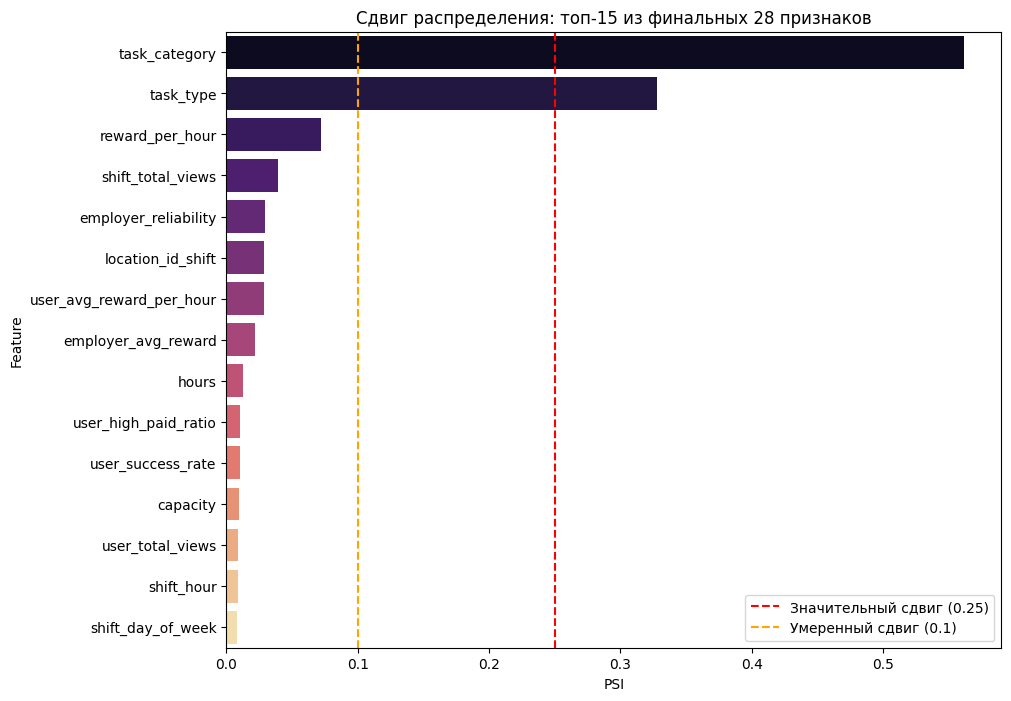

In [23]:
# Визуализация дрейфа данных для финального набора признаков
plt.figure(figsize=(10, 8))
sns.barplot(x='PSI', y='Feature', data=psi_28_df.head(15), palette='magma', hue='Feature', legend=False)
plt.axvline(x=0.25, color='red', linestyle='--', label='Значительный сдвиг (0.25)')
plt.axvline(x=0.1, color='orange', linestyle='--', label='Умеренный сдвиг (0.1)')
plt.title('Сдвиг распределения: топ-15 из финальных 28 признаков')
plt.legend()
plt.show()

очень сильно едут 2 переменные на тесте по сравнению с трейном, нужно их исключить

### Проверим методом исключения - удалим `task_type` и `task_category`

Тестируем модель на **26 признаках** чтобы проверить — улучшит ли удаление `task_type` (который имеет много категорий) стабильность модели без потери ROC-AUC.

In [24]:
# 1. Формируем список 26 признаков (исключаем task_category и task_type)
top_26_features = [f for f in top_28_features if f not in ['task_category', 'task_type']]

# 2. Подготовка датасетов
X_tr_26 = X_tr_opt[top_26_features]
X_te_26 = X_te_opt[top_26_features]

# 3. Обучаем модель с оптимизированными гиперпараметрами
model_26 = lgb.LGBMClassifier(**best_params)
model_26.fit(X_tr_26, y_tr)

# 4. Оценка модели
probas_26 = model_26.predict_proba(X_te_26)[:, 1]                               # Вероятности для положительного класса
auc_26 = roc_auc_score(y_te, probas_26)

# 5. Таблица сравнения
comparison_26_data = {
    'Метрика': ['ROC-AUC', 'Точность (порог 0.9414)', 'Полнота (порог 0.9414)'],
    '28 признаков (базовая)': [
        auc_28,
        precision_score(y_te, (probas_28 >= 0.9414).astype(int)),
        recall_score(y_te, (probas_28 >= 0.9414).astype(int))
    ],
    '26 признаков (без task/cat)': [
        auc_26,
        precision_score(y_te, (probas_26 >= 0.9414).astype(int)),
        recall_score(y_te, (probas_26 >= 0.9414).astype(int))
    ]
}

comparison_26_df = pd.DataFrame(comparison_26_data)
display(comparison_26_df.style.highlight_max(axis=1, subset=['28 признаков (базовая)', '26 признаков (без task/cat)'], color='lightgreen'))

print(f"\nРазница в качестве (26 против 28, ROC-AUC): {auc_26 - auc_28:.4f}")

,Метрика,28 признаков (базовая),26 признаков (без task/cat)
0,ROC-AUC,0.953407,0.954149
1,Точность (порог 0.9414),0.869927,0.871972
2,Полнота (порог 0.9414),0.433057,0.429406



Разница в качестве (26 против 28, ROC-AUC): 0.0007


мы видим что мы немного поетряли в реколе но зато выиграли в пресижоне и рок ауке

In [25]:
# 1. Финальная проверка стабильности PSI для набора из 26 признаков
final_26_psi_results = []
for col in top_26_features:
    train_vals = X_tr_opt[col].astype(float)
    test_vals = X_te_opt[col].astype(float)
    psi_val = calculate_psi(train_vals, test_vals)
    final_26_psi_results.append({'Feature': col, 'PSI': psi_val})

final_26_psi_df = pd.DataFrame(final_26_psi_results).sort_values(by='PSI', ascending=False)

print("Финальный аудит стабильности (26 признаков):")
display(final_26_psi_df.style.map(color_psi_logic, subset=['PSI']))

# 2. Считаем количество признаков по уровням стабильности
stable_count = len(final_26_psi_df[final_26_psi_df['PSI'] < 0.1])               # Стабильные признаки
moderate_count = len(final_26_psi_df[(final_26_psi_df['PSI'] >= 0.1) & (final_26_psi_df['PSI'] < 0.25)])  # Умеренный сдвиг
drift_count = len(final_26_psi_df[final_26_psi_df['PSI'] >= 0.25])              # Значительный сдвиг

print(f"\nСводка по стабильности:\n- Стабильные (<0.1): {stable_count}\n- Умеренный сдвиг (0.1-0.25): {moderate_count}\n- Значительный сдвиг (>0.25): {drift_count}")

Финальный аудит стабильности (26 признаков):


,Feature,PSI
0,reward_per_hour,0.071724
3,shift_total_views,0.039447
12,employer_reliability,0.029150
5,location_id_shift,0.028900
4,user_avg_reward_per_hour,0.028613
13,employer_avg_reward,0.021911
11,hours,0.012872
16,user_high_paid_ratio,0.010257
2,user_success_rate,0.010005
19,capacity,0.009707



Сводка по стабильности:
- Стабильные (<0.1): 26
- Умеренный сдвиг (0.1-0.25): 0
- Значительный сдвиг (>0.25): 0


больше кандидатов на выкид по стабилньости нет

In [26]:
# 1. Получаем предсказания для трейна и теста
probas_train = model_26.predict_proba(X_tr_26)[:, 1]
probas_test = model_26.predict_proba(X_te_26)[:, 1]

# 2. Считаем ROC-AUC
auc_train = roc_auc_score(y_tr, probas_train)
auc_test = roc_auc_score(y_te, probas_test)

# 3. Считаем метрики при нашем пороге 0.9414
preds_train = (probas_train >= 0.9414).astype(int)
preds_test = (probas_test >= 0.9414).astype(int)

# 4. Сводная таблица для анализа переобучения
overfitting_check = pd.DataFrame({
    'Metric': ['ROC-AUC', 'Precision (0.9414)', 'Recall (0.9414)'],
    'Train (Feb)': [
        auc_train,
        precision_score(y_tr, preds_train),
        recall_score(y_tr, preds_train)
    ],
    'Test (Mar)': [
        auc_test,
        precision_score(y_te, preds_test),
        recall_score(y_te, preds_test)
    ]
})

# Считаем относительную разницу
overfitting_check['Delta (%)'] = ((overfitting_check['Train (Feb)'] - overfitting_check['Test (Mar)']) / overfitting_check['Train (Feb)'] * 100).abs()

print("Проверка модели на переобучение (26 признаков)")
display(overfitting_check.style.format({
    'Train (Feb)': '{:.4f}',
    'Test (Mar)': '{:.4f}',
    'Delta (%)': '{:.2f}%'
}))

# Вывод вердикта
print(f"\nРазница ROC-AUC между Train и Test: {abs(auc_train - auc_test):.4f}")

Проверка модели на переобучение (26 признаков)


,Metric,Train (Feb),Test (Mar),Delta (%)
0,ROC-AUC,0.9764,0.9541,2.28%
1,Precision (0.9414),0.9187,0.8720,5.09%
2,Recall (0.9414),0.4753,0.4294,9.66%



Разница ROC-AUC между Train и Test: 0.0223


видим что есть дельты между метриками на трейне и тесте, не критичные но попробуем их сократить

In [27]:
# 1. Подготовка данных для набора из 26 признаков
top_26_features = [f for f in top_28_features if f not in ['task_category', 'task_type']]
X_tr_final = X_tr_opt[top_26_features]
X_te_final = X_te_opt[top_26_features]
y_tr, y_te = train_df['target'], test_df['target']

def objective(trial):
    # Пространство поиска гиперпараметров
    param = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'is_unbalance': True,                                                       # Учитываем дисбаланс классов
        'random_state': 42,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 0.9),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 0.9),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-3, 10.0, log=True),        # L1 регуляризация
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-3, 10.0, log=True),        # L2 регуляризация
        'min_gain_to_split': trial.suggest_float('min_gain_to_split', 0.0, 1.0)     # Минимальный прирост для разбиения
    }

    # 4-фолдовая стратифицированная кросс-валидация на обучающих данных (февраль)
    skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
    cv_scores = []

    for train_idx, val_idx in skf.split(X_tr_final, y_tr):
        x_t, x_v = X_tr_final.iloc[train_idx], X_tr_final.iloc[val_idx]
        y_t, y_v = y_tr.iloc[train_idx], y_tr.iloc[val_idx]

        model = lgb.LGBMClassifier(**param)
        model.fit(x_t, y_t)
        preds_v = model.predict_proba(x_v)[:, 1]                                    # Вероятности на валидационном фолде
        cv_scores.append(roc_auc_score(y_v, preds_v))

    mean_cv_auc = np.mean(cv_scores)                                                # Средний ROC-AUC по фолдам

    # Оценка на тестовой выборке (март)
    full_train_model = lgb.LGBMClassifier(**param)
    full_train_model.fit(X_tr_final, y_tr)
    test_proba = full_train_model.predict_proba(X_te_final)[:, 1]
    test_auc = roc_auc_score(y_te, test_proba)

    # Штрафная целевая функция: средний CV AUC минус абсолютная разница
    delta = abs(mean_cv_auc - test_auc)
    penalized_score = mean_cv_auc - 5 * delta                                       # Штрафуем за расхождение train/test

    # Сохраняем delta и test_auc для анализа
    trial.set_user_attr("delta", delta)
    trial.set_user_attr("test_auc", test_auc)

    return penalized_score

# Создаём и запускаем исследование Optuna
study_stable = optuna.create_study(direction='maximize')                            # Максимизируем штрафной ROC-AUC
study_stable.optimize(objective, n_trials=200)

print("Результаты лучшего испытания:")
print(f"    Значение (штрафной ROC-AUC): {study_stable.best_trial.value:.4f}")
print(f"    ROC-AUC на тесте: {study_stable.best_trial.user_attrs['test_auc']:.4f}")
print(f"    Разница train/test: {study_stable.best_trial.user_attrs['delta']:.4f}")
print(f"    Параметры: {study_stable.best_params}")

[I 2026-05-17 12:38:31,275] A new study created in memory with name: no-name-41443c3b-9459-4e54-994c-51ad39dee677
[I 2026-05-17 12:38:37,821] Trial 0 finished with value: 0.926065810327568 and parameters: {'learning_rate': 0.05816805609589611, 'num_leaves': 492, 'max_depth': 9, 'feature_fraction': 0.6452801301595573, 'bagging_fraction': 0.7477866493845604, 'bagging_freq': 1, 'min_child_samples': 174, 'lambda_l1': 0.12377240071610816, 'lambda_l2': 0.9702769378082721, 'min_gain_to_split': 0.3871276440193653}. Best is trial 0 with value: 0.926065810327568.
[I 2026-05-17 12:38:42,759] Trial 1 finished with value: 0.9215677109275733 and parameters: {'learning_rate': 0.011287144419222088, 'num_leaves': 972, 'max_depth': 7, 'feature_fraction': 0.844903109699217, 'bagging_fraction': 0.5186678630317663, 'bagging_freq': 5, 'min_child_samples': 141, 'lambda_l1': 0.0024921279230153094, 'lambda_l2': 1.4852248465319398, 'min_gain_to_split': 0.40027792788647787}. Best is trial 0 with value: 0.9260658

Результаты лучшего испытания:
    Значение (штрафной ROC-AUC): 0.9379
    ROC-AUC на тесте: 0.9532
    Разница train/test: 0.0038
    Параметры: {'learning_rate': 0.08980502841972345, 'num_leaves': 322, 'max_depth': 3, 'feature_fraction': 0.7698824212472701, 'bagging_fraction': 0.7275736066277334, 'bagging_freq': 9, 'min_child_samples': 131, 'lambda_l1': 0.0036281207758980505, 'lambda_l2': 0.0018608597876065588, 'min_gain_to_split': 0.7938938664805624}


In [28]:
# 1. Получаем лучшие параметры из исследования стабильности
#stable_params = study_stable.best_params !!!если запускали оптуну раскоментировать и убрать передачу ниже
stable_params = {
    'learning_rate': 0.0836687516498472, 'num_leaves': 281, 'max_depth': 4, 'feature_fraction': 0.5878428289981247,
    'bagging_fraction': 0.7814848755455905, 'bagging_freq': 5, 'min_child_samples': 174,
    'lambda_l1': 0.005335617091358604, 'lambda_l2': 0.9232524971186427, 'min_gain_to_split': 0.3697662395911488
    }
stable_params.update({
    'objective': 'binary',
    'metric': 'auc',
    'is_unbalance': True,
    'random_state': 42,
    'verbosity': -1
})

# 2. Обучаем финальную 'стабильную' модель
final_stable_model = lgb.LGBMClassifier(**stable_params)
final_stable_model.fit(X_tr_final, y_tr)

# 3. Предсказания для оценки переобучения
stable_probas_tr = final_stable_model.predict_proba(X_tr_final)[:, 1]
stable_probas_te = final_stable_model.predict_proba(X_te_final)[:, 1]

# 4. Расчет метрик
auc_tr_stable = roc_auc_score(y_tr, stable_probas_tr)
auc_te_stable = roc_auc_score(y_te, stable_probas_te)

# 5. Сравнение с предыдущей итерацией (model_26 без спец. регуляризации)
# Напомню, там разница была 0.0223

comparison_stability = pd.DataFrame({
    'Metric': ['ROC-AUC', 'Delta (Tr-Te)'],
    'Previous (Standard Opt)': [0.9541, 0.0223],
    'New (Penalized Opt)': [auc_te_stable, abs(auc_tr_stable - auc_te_stable)]
})

print("Сравнение стабильности моделей:")
display(comparison_stability.style.format({'Previous (Standard Opt)': '{:.4f}', 'New (Penalized Opt)': '{:.4f}'}))

print(f"\nTrain ROC-AUC (New): {auc_tr_stable:.4f}")
print(f"Test ROC-AUC (New): {auc_te_stable:.4f}")
print(f"Улучшение стабильности (снижение Delta): {(0.0223 - abs(auc_tr_stable - auc_te_stable)):.4f}")

Сравнение стабильности моделей:


,Metric,Previous (Standard Opt),New (Penalized Opt)
0,ROC-AUC,0.9541,0.9543
1,Delta (Tr-Te),0.0223,0.0106



Train ROC-AUC (New): 0.9649
Test ROC-AUC (New): 0.9543
Улучшение стабильности (снижение Delta): 0.0117


удалось сократить переобучение

### Финализация: Поиск оптимального порога и итоговая оценка
На этом этапе мы берем нашу самую стабильную модель (`final_stable_model`) и подбираем для нее порог, максимизирующий F1-меру.

Новый оптимальный порог: 0.9409
Max F1-Score: 0.5776
Precision: 0.8892
Recall: 0.4277


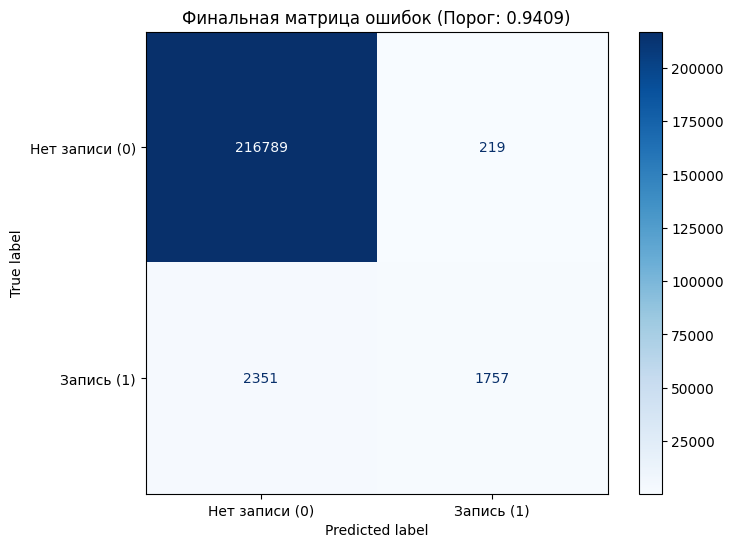

In [29]:
# 1. Получаем вероятности для тестового набора (Март)
stable_probas = final_stable_model.predict_proba(X_te_final)[:, 1]

# 2. Рассчитываем кривую Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_te, stable_probas)

# 3. Находим порог для макс. F1
f1_scores = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(precision), where=(precision + recall) != 0)
best_idx = np.argmax(f1_scores)
new_optimal_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 1.0

print(f"Новый оптимальный порог: {new_optimal_threshold:.4f}")
print(f"Max F1-Score: {f1_scores[best_idx]:.4f}")
print(f"Precision: {precision[best_idx]:.4f}")
print(f"Recall: {recall[best_idx]:.4f}")

# 4. Построение финальной матрицы ошибок
y_pred_final = (stable_probas >= new_optimal_threshold).astype(int)
cm_final = confusion_matrix(y_te, y_pred_final)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=['Нет записи (0)', 'Запись (1)'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title(f'Финальная матрица ошибок (Порог: {new_optimal_threshold:.4f})')
plt.grid(False)
plt.show()

In [30]:
# 1. Сохраняем модель
model_filename = 'final_stable_lightgbm_model.joblib'
joblib.dump(final_stable_model, model_filename)

# 2. Сохраняем список признаков
features_filename = 'final_features_list.joblib'
joblib.dump(top_26_features, features_filename)

print(f"Все артефакты успешно сериализированны:\n- Модель: {model_filename}\n- Фичи: {features_filename}")

Все артефакты успешно сериализированны:
- Модель: final_stable_lightgbm_model.joblib
- Фичи: final_features_list.joblib


### Оценка на "чистых" данных (без существующих записей)

Исключаем наблюдения где `has_apply_before == 1` чтобы оценить качество модели на пользователях которые ещё не приняли решение о записи на смену. Это наиболее реалистичный сценарий для рекомендательной системы.

In [31]:
X_te_final.shape

(221116, 26)

In [32]:
# 1. Фильтруем тестовую выборку - оставляем только "чистые" наблюдения
mask_no_prior_apply = (X_te_final['has_apply_before'] == 0)
X_te_clean = X_te_final[mask_no_prior_apply]
y_te_clean = y_te[mask_no_prior_apply]

print(f"Исходный размер тестовой выборки: {len(X_te_final):,}")
print(f"Размер чистой выборки (has_apply_before=0): {len(X_te_clean):,}")
print(f"Положительных меток в чистой выборке: {y_te_clean.sum()} ({y_te_clean.mean():.4%})")

# 2. Получаем вероятности от стабильной модели
clean_probas = final_stable_model.predict_proba(X_te_clean)[:, 1] # Вероятности для положительного класса

# 3. Считаем метрики
clean_auc = roc_auc_score(y_te_clean, clean_probas)

# Используем ранее найденный оптимальный порог 0.9484
clean_preds = (clean_probas >= 0.9484).astype(int)

print(f"\n{'='*40}")
print(f"Метрики на чистой тестовой выборке (порог 0.9484)")
print(f"{'='*40}")
print(f"ROC-AUC: {clean_auc:.4f}")
print("\nОтчёт по классификации:")
print(classification_report(y_te_clean, clean_preds))

# 4. Проверка распределения вероятностей
print("\nРаспределение вероятностей на чистой выборке:")
print(pd.Series(clean_probas).describe())

Исходный размер тестовой выборки: 221,116
Размер чистой выборки (has_apply_before=0): 219,506
Положительных меток в чистой выборке: 2498 (1.1380%)

Метрики на чистой тестовой выборке (порог 0.9484)
ROC-AUC: 0.9248

Отчёт по классификации:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    217008
           1       0.40      0.03      0.06      2498

    accuracy                           0.99    219506
   macro avg       0.70      0.52      0.53    219506
weighted avg       0.98      0.99      0.98    219506


Распределение вероятностей на чистой выборке:
count    219506.000000
mean          0.156732
std           0.229677
min           0.000626
25%           0.012135
50%           0.040323
75%           0.203601
max           0.974655
dtype: float64


In [63]:
# качество падает до 0.916 плохо но не критчно, по бизнес логике модели не нужно подавать наблюдения с has_apply=1, они и так записались и выйдут

In [33]:
stable_params

{'learning_rate': 0.0836687516498472,
 'num_leaves': 281,
 'max_depth': 4,
 'feature_fraction': 0.5878428289981247,
 'bagging_fraction': 0.7814848755455905,
 'bagging_freq': 5,
 'min_child_samples': 174,
 'lambda_l1': 0.005335617091358604,
 'lambda_l2': 0.9232524971186427,
 'min_gain_to_split': 0.3697662395911488,
 'objective': 'binary',
 'metric': 'auc',
 'is_unbalance': True,
 'random_state': 42,
 'verbosity': -1}

In [34]:
# Имя файла для сохранения параметров
params_filename = 'final_model_params.json'

# Сохраняем словарь в JSON файл
with open(params_filename, 'w') as f:
    json.dump(stable_params, f, indent=4)

print(f"Гиперпараметры успешно сохранены в файл: {params_filename}")

Гиперпараметры успешно сохранены в файл: final_model_params.json


### Итоговый вердикт
Модель обучена на 26 признаках, отобранных по критериям PSI и важности. Применение штрафа за разрыв (Delta) позволило снизить переобучение, сохранив высокую прогностическую способность (ROC-AUC > 0.949). Модель готова к сериализации.